# 00 — Data audit (FD001–FD004)

**Purpose:** establish what `data/raw` supports before any pipeline change — the evidence base for protocol v2.
**Questions:** A structure · B what the headline metric rests on · C is validation representative · D regimes · E informative sensors · F RUL cap · G noise vs trend · H the removed 258 features · I engine subpopulations · J health-index pooling · K multi-regime noise growth · L regime-dependent direction.
**Data version:** DVC hash of `data/raw`, printed by the parameter cell and recorded in the report. **Outputs:** `reports/data_audit.md`, `reports/data_audit.env.json`, `reports/figures/data_audit/`.
**Decisions informed:** D01–D11, D13, D17, D18, D35, D36; X04, X06. **Status:** current.

In [ ]:
from __future__ import annotations

import hashlib
import json
from contextlib import ExitStack
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from scipy import stats as sps
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.preprocessing import StandardScaler

from turbofan import repro
from turbofan.config import (
    DATASETS,
    KEEP,
    MAINTENANCE_BUCKETS,
    MULTI_REGIME,
    REGIME_KMEANS_N_INIT,
    REGIME_KMEANS_SEED,
    REGIME_N_CLUSTERS,
    RUL_CAP,
    SEQ_LEN,
    SPLIT_FRAC,
    WINDOW,
)
from turbofan.data.loader import load_dataset
from turbofan.evaluation.comparison import split_engines
from turbofan.stats import bootstrap_ci, ks_2samp_ci
from turbofan.tracking import _dvc_data_hash

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
RAW = ROOT / "data" / "raw"
REPORT_PATH = ROOT / "reports" / "data_audit.md"
FIG_DIR = ROOT / "reports" / "figures" / "data_audit"
FIG_DIR.mkdir(parents=True, exist_ok=True)

E:\turbofan-rul-prediction\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Ground rules

I read `test_FD00x.txt` only for truncation lengths (A) and `RUL_FD00x.txt` only for its label distribution (B, C); no model is fitted and no feature computed on test data (rule 3).
Distribution statistics carry a percentile-bootstrap CI over engines, never rows; counts over the fixed files are exact and carry none (rule 4).
Everything runs CPU-only on one thread with declared seeds (D34); the hinge fits in F, G, I and K are exhaustive grids with closed-form least squares, so they have no seed.

## Parameters

These are the audit's own analysis parameters, not pipeline parameters; the report header lists every one, and the seeds go into its reproducibility block.

In [ ]:
N_THREADS = 1
N_BOOT = 2000  # bootstrap resamples (engines)
CI_LEVEL = 0.95
BOOT_SEED = 20261002  # numpy default_rng, keyed by [BOOT_SEED, section, dataset]
AUDIT_KMEANS_SEED = 0  # D: this audit's own regime clustering
AUDIT_KMEANS_N_INIT = 10
K_RANGE = list(range(2, 11))  # silhouette scan
SIL_SAMPLE = 10_000  # rows sampled for silhouette (O(n^2) otherwise)
SIL_SEED = 0
STABILITY_SEEDS = list(range(10))  # D05: KMeans restarts with config's k / n_init
VAL_STEP = 5  # nb02 make_val_instances default
MIN_SEG_GRID = (5, 10, 20)  # F: min points each side of the hinge (sensitivity)
MIN_SEG_PRIMARY = 10
TAIL_LEN = 30  # H: early/late segment length for the noise-growth ratio
SLOPE_WINDOWS = (15, WINDOW, SEQ_LEN)  # G/H: windows whose slope resolution is reported
SMOOTH_WINDOWS = (5, 15, 30)  # H: rolling-mean windows of the removed 258-feature family
EWM_SPAN = 15  # H: "ewm15" — span assumed from the name; definition not recoverable

SECTIONS = "ABCDEFGHIJKL"  # keys the bootstrap streams; append only
ALPHA = 1 - CI_LEVEL
SEEDS = {
    "bootstrap_default_rng": BOOT_SEED,
    "audit_kmeans_random_state": AUDIT_KMEANS_SEED,
    "silhouette_sample_random_state": SIL_SEED,
    **{f"d05_stability_kmeans_random_state_{s}": s for s in STABILITY_SEEDS},
}

stack = ExitStack()
stack.enter_context(repro.cpu_deterministic(n_threads=N_THREADS))
plt.rcParams.update({"figure.dpi": 100, "savefig.dpi": 100})  # D37
print("data/raw DVC hash:", _dvc_data_hash())

REPORT: list[str] = []  # markdown chunks, assembled into reports/data_audit.md at the end
FIGS: dict[str, str] = {}  # figure file -> sha256


def rng_for(section: str, ds: str) -> np.random.Generator:
    return np.random.default_rng([BOOT_SEED, SECTIONS.index(section), DATASETS.index(ds)])


def boot(values, rng, stat=np.median):
    """(estimate, lo, hi, n) — engine-level percentile bootstrap (turbofan.stats)."""
    return bootstrap_ci(values, rng, n_boot=N_BOOT, ci_level=CI_LEVEL, stat=stat)


def fmt(b, p=2):
    est, lo, hi, n = b
    return f"{est:.{p}f} [{lo:.{p}f}, {hi:.{p}f}] (n={n})"


NL = "\n"  # newline, for report strings assembled with +


def md_table(df: pd.DataFrame) -> str:
    cols = [str(c).replace("|", r"\|") for c in df.columns]
    out = ["| " + " | ".join(cols) + " |", "|" + "|".join("---" for _ in cols) + "|"]
    out += [
        "| " + " | ".join(str(v).replace("|", r"\|") for v in row) + " |"
        for row in df.itertuples(index=False)
    ]
    return "\n".join(out)


def save_fig(fig, name: str) -> str:
    path = FIG_DIR / name
    fig.savefig(path, dpi=100, bbox_inches="tight", metadata={"Software": None})
    FIGS[name] = hashlib.sha256(path.read_bytes()).hexdigest()
    return f"figures/data_audit/{name}"


def per_engine_corr(x: pd.DataFrame, y: pd.Series, unit: pd.Series) -> pd.DataFrame:
    """Pearson r per engine between each column of x and y (NaN where a side is constant)."""
    xy = x.assign(_y=y.values)
    g = xy.groupby(unit.values)
    c = xy - g.transform("mean")
    num = c[x.columns].mul(c["_y"], axis=0).groupby(unit.values).sum()
    sxx = (c[x.columns] ** 2).groupby(unit.values).sum()
    syy = (c["_y"] ** 2).groupby(unit.values).sum()
    den = np.sqrt(sxx.mul(syy, axis=0))
    with np.errstate(invalid="ignore", divide="ignore"):
        r = num / den
    return r.where(den > 0)


def per_engine_spearman(x: pd.DataFrame, y: pd.Series, unit: pd.Series) -> pd.DataFrame:
    xr = x.groupby(unit.values).rank(method="average")
    yr = y.groupby(unit.values).rank(method="average")
    return per_engine_corr(xr, yr, unit)

data/raw DVC hash: 43f328008844d7fd56733c63103d09ef.dir


## Load

`ttf` is the uncapped time to failure (last train cycle − cycle). I keep the loader's capped `rul` only where the pipeline itself uses it (C).

In [ ]:
train, test, test_rul = {}, {}, {}
for ds in DATASETS:
    tr, te, rul = load_dataset(ds, RAW)
    for name, df in (("train", tr), ("test", te)):
        g = df.groupby("unit")["cycle"]
        if not ((g.min() == 1).all() and (g.max() == g.count()).all()):
            raise ValueError(f"{ds} {name}: cycles are not 1..T consecutive per unit")
    tr = tr.sort_values(["unit", "cycle"]).reset_index(drop=True)
    tr["ttf"] = tr.groupby("unit")["cycle"].transform("max") - tr["cycle"]
    train[ds], test[ds], test_rul[ds] = tr, te, rul

SENSORS = [f"s{i}" for i in range(1, 22)]
print({ds: train[ds].shape for ds in DATASETS})

{'FD001': (20631, 28), 'FD002': (53759, 28), 'FD003': (24720, 28), 'FD004': (61249, 28)}


## A. Structure

**Question:** how many engines and cycles does each dataset have, and how many test engines are shorter than the windows the models consume?
**Method:** exact counts over the files; medians with an engine-level bootstrap CI. Test files are read for their lengths only.

,dataset,train units,train cycles/unit min,train cycles/unit median [95% CI],train cycles/unit IQR,train cycles/unit max,test units,test length min,test length median [95% CI],test length max,test units < SEQ_LEN (30),test units < WINDOW (20)
0,FD001,100,128,"199.0 [193.5, 207.0] (n=100)",177–229,362,100,31,"133.5 [123.0, 146.0] (n=100)",303,0,0
1,FD002,260,128,"199.0 [194.0, 204.0] (n=260)",174–230,378,259,21,"132.0 [123.0, 144.0] (n=259)",367,6,0
2,FD003,100,145,"220.5 [202.0, 232.5] (n=100)",190–280,525,100,38,"148.0 [130.0, 169.5] (n=100)",475,0,0
3,FD004,249,128,"234.0 [223.0, 247.0] (n=249)",190–290,543,248,19,"153.5 [140.5, 170.0] (n=248)",486,11,2


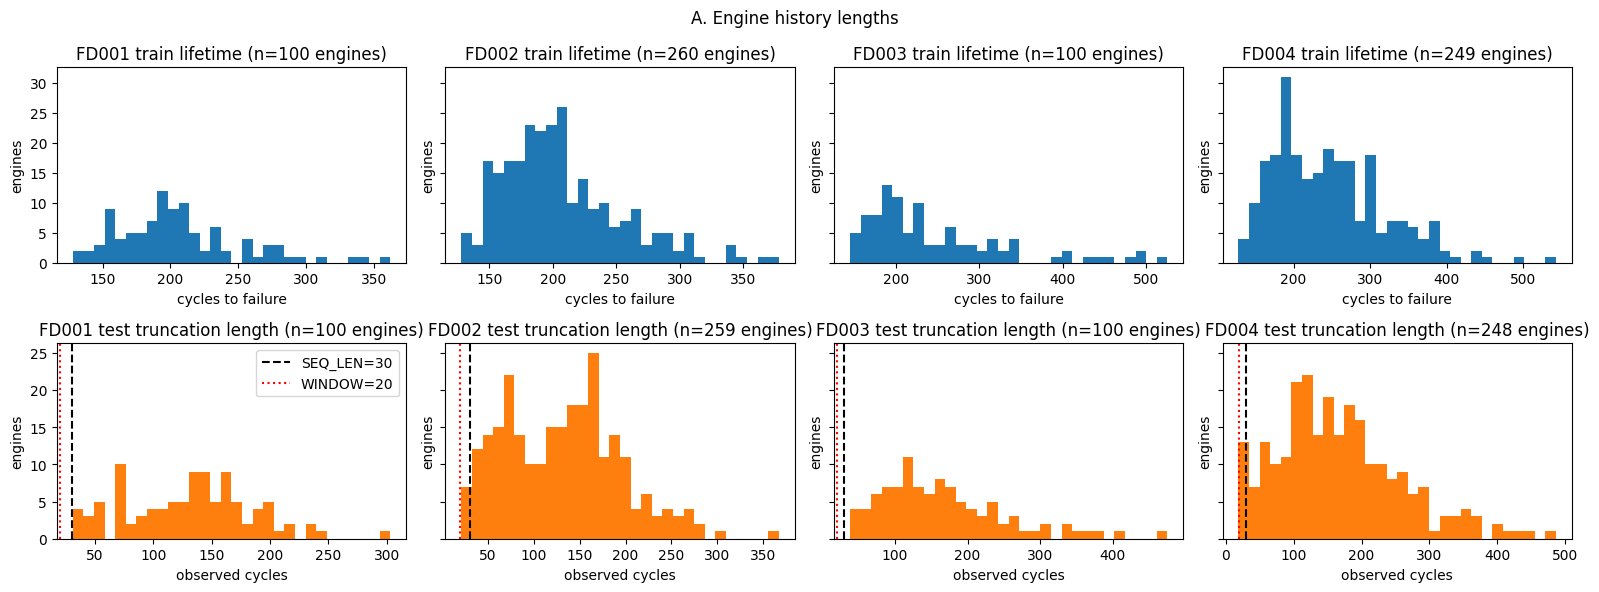

In [ ]:
rows = []
for ds in DATASETS:
    rng = rng_for("A", ds)
    life = train[ds].groupby("unit")["cycle"].max()
    tlen = test[ds].groupby("unit")["cycle"].max()
    if len(test_rul[ds]) != len(tlen):
        raise ValueError(f"{ds}: {len(test_rul[ds])} RUL labels for {len(tlen)} test units")
    rows.append(
        {
            "dataset": ds,
            "train units": len(life),
            "train cycles/unit min": int(life.min()),
            "train cycles/unit median [95% CI]": fmt(boot(life, rng), 1),
            "train cycles/unit IQR": f"{life.quantile(0.25):.0f}–{life.quantile(0.75):.0f}",
            "train cycles/unit max": int(life.max()),
            "test units": len(tlen),
            "test length min": int(tlen.min()),
            "test length median [95% CI]": fmt(boot(tlen, rng), 1),
            "test length max": int(tlen.max()),
            f"test units < SEQ_LEN ({SEQ_LEN})": int((tlen < SEQ_LEN).sum()),
            f"test units < WINDOW ({WINDOW})": int((tlen < WINDOW).sum()),
        }
    )
A = pd.DataFrame(rows)
A_life = {ds: train[ds].groupby("unit")["cycle"].max() for ds in DATASETS}
A_tlen = {ds: test[ds].groupby("unit")["cycle"].max() for ds in DATASETS}
display(A)

fig, axes = plt.subplots(2, 4, figsize=(16, 6), sharey="row")
for j, ds in enumerate(DATASETS):
    axes[0, j].hist(A_life[ds], bins=30, color="tab:blue")
    axes[0, j].set_title(f"{ds} train lifetime (n={len(A_life[ds])} engines)")
    axes[0, j].set_xlabel("cycles to failure")
    axes[0, j].set_ylabel("engines")
    axes[1, j].hist(A_tlen[ds], bins=30, color="tab:orange")
    axes[1, j].axvline(SEQ_LEN, color="k", ls="--", label=f"SEQ_LEN={SEQ_LEN}")
    axes[1, j].axvline(WINDOW, color="r", ls=":", label=f"WINDOW={WINDOW}")
    axes[1, j].set_title(f"{ds} test truncation length (n={len(A_tlen[ds])} engines)")
    axes[1, j].set_xlabel("observed cycles")
    axes[1, j].set_ylabel("engines")
axes[1, 0].legend()
fig.suptitle("A. Engine history lengths")
fig.tight_layout()
fig_a = save_fig(fig, "A_lengths.png")
plt.show()

n_short = {ds: int((A_tlen[ds] < SEQ_LEN).sum()) for ds in DATASETS}
REPORT.append(
    "## A. Structure\n\n"
    "Counts are exact (census of the files). Medians carry a 95% bootstrap CI over engines.\n\n"
    + md_table(A)
    + f"\n\n![lengths]({fig_a})\n\n"
    + "Test engines shorter than `SEQ_LEN` are left-padded with zeros by the LSTM (D11): "
    + ", ".join(f"{ds} {n_short[ds]}/{len(A_tlen[ds])}" for ds in DATASETS)
    + ". Test engines shorter than `WINDOW` get rolling features from fewer than `WINDOW` "
    "cycles: " + ", ".join(f"{ds} {int((A_tlen[ds] < WINDOW).sum())}" for ds in DATASETS) + ".\n"
)

In [ ]:
assert {ds for ds in DATASETS if n_short[ds] > 0} == {"FD002", "FD004"}

**Takeaway:** only FD002 and FD004 have test engines shorter than `SEQ_LEN`, so the padding policy changes only their scores (D11).

## B. Test label distribution

**Question:** how many test engines does the headline metric (critical-zone RMSE) rest on?
**Method:** the label distribution only — rule 3 allows it because no prediction is involved. Bucket bounds come from `config.MAINTENANCE_BUCKETS`.

,dataset,n,min,median [95% CI],IQR,max,"critical [0,25)","urgent [25,50)","monitor [50,100)","healthy [100,∞)",true RUL > 125
0,FD001,100,7,"86.0 [65.5, 95.0] (n=100)",33–112,145,19,11,36,34,11
1,FD002,259,6,"80.0 [73.0, 88.0] (n=259)",35–121,194,58,29,79,93,57
2,FD003,100,6,"77.5 [58.0, 87.0] (n=100)",43–115,145,15,14,38,33,15
3,FD004,248,6,"88.0 [76.0, 96.0] (n=248)",36–127,195,49,30,67,102,67


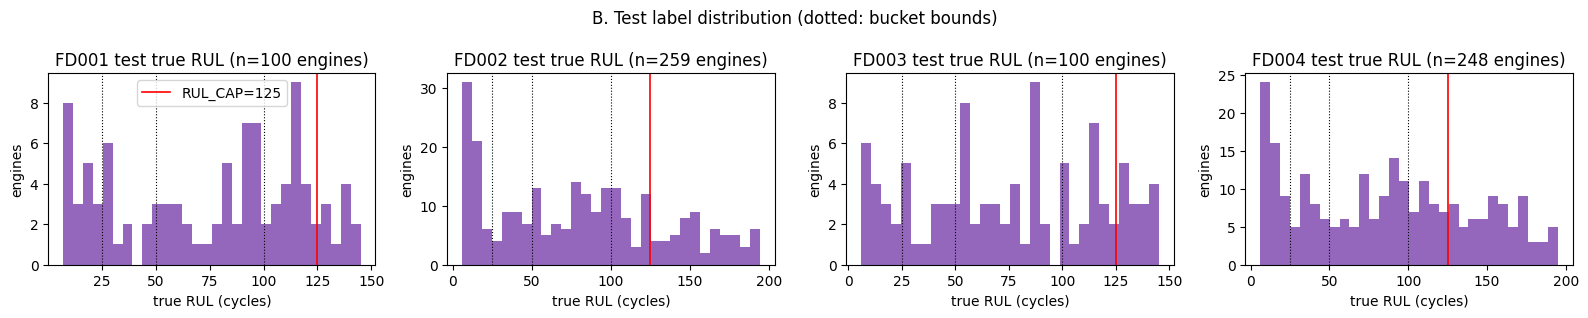

In [ ]:
rows, B_crit = [], {}
for ds in DATASETS:
    rng = rng_for("B", ds)
    y = test_rul[ds].to_numpy()
    row = {
        "dataset": ds,
        "n": len(y),
        "min": int(y.min()),
        "median [95% CI]": fmt(boot(y, rng), 1),
        "IQR": f"{np.quantile(y, 0.25):.0f}–{np.quantile(y, 0.75):.0f}",
        "max": int(y.max()),
    }
    for name, lo, hi in MAINTENANCE_BUCKETS:
        hi_s = "∞" if np.isinf(hi) else f"{hi:.0f}"
        row[f"{name} [{lo:.0f},{hi_s})"] = int(((y >= lo) & (y < hi)).sum())
    row[f"true RUL > {RUL_CAP:.0f}"] = int((y > RUL_CAP).sum())
    B_crit[ds] = row[next(k for k in row if k.startswith("critical"))]
    rows.append(row)
B = pd.DataFrame(rows)
display(B)

fig, axes = plt.subplots(1, 4, figsize=(16, 3.2))
for ax, ds in zip(axes, DATASETS, strict=True):
    ax.hist(test_rul[ds], bins=30, color="tab:purple")
    for _, lo, _ in MAINTENANCE_BUCKETS[1:]:
        ax.axvline(lo, color="k", lw=0.8, ls=":")
    ax.axvline(RUL_CAP, color="r", lw=1.2, label=f"RUL_CAP={RUL_CAP:.0f}")
    ax.set_title(f"{ds} test true RUL (n={len(test_rul[ds])} engines)")
    ax.set_xlabel("true RUL (cycles)")
    ax.set_ylabel("engines")
axes[0].legend()
fig.suptitle("B. Test label distribution (dotted: bucket bounds)")
fig.tight_layout()
fig_b = save_fig(fig, "B_test_rul.png")
plt.show()

B_crit_total = sum(B_crit.values())
B_n_total = int(B["n"].sum())
REPORT.append(
    "## B. Test label distribution\n\n"
    "Label distribution only (allowed by rule 3); no prediction is involved.\n\n"
    + md_table(B)
    + f"\n\n![test RUL]({fig_b})\n\n"
    + "**The headline metric (critical-zone RMSE, true RUL in [0, 25)) rests on "
    + ", ".join(f"{B_crit[ds]} engines ({ds})" for ds in DATASETS)
    + f" — {B_crit_total} of {B_n_total} test engines pooled.** Each per-dataset headline "
    "number is an RMSE over that many residuals, one per engine.\n"
)

In [ ]:
assert all(B_crit[ds] < len(test_rul[ds]) / 2 for ds in DATASETS)

**Takeaway:** the critical bucket holds a minority of each dataset's test engines (critical column above), so a headline RMSE averages few residuals and needs its CI (D18).

## C. Validation realism

**Question:** does `make_val_instances` — nb02's validation scheme — sample the RUL distribution it stands in for?
**Method:** I apply it, logic unchanged (copied from `archive/02_modeling.ipynb`), to the pipeline's own validation engines and compare with the test labels by two-sample KS. KS is distribution-free, and the bootstrap resamples engines on both sides so engines with many instances don't dominate.

,dataset,val engines,val instances,engines using fallback (no RUL<cap),val RUL range,test engines,test RUL ≥ 125 (unreachable by val),KS vs all test [95% CI],KS vs test RUL<125 [95% CI],test n (RUL<125),val median,test median
0,FD001,20,500,0,4–124,100,11,"0.200 [0.130, 0.300]","0.136 [0.091, 0.248]",89,64,86
1,FD002,52,1300,0,4–124,259,57,"0.226 [0.180, 0.280]","0.137 [0.087, 0.202]",202,64,80
2,FD003,20,500,0,4–124,100,15,"0.180 [0.120, 0.270]","0.075 [0.073, 0.188]",85,64,78
3,FD004,50,1250,0,4–124,248,67,"0.270 [0.218, 0.331]","0.101 [0.068, 0.173]",181,64,88


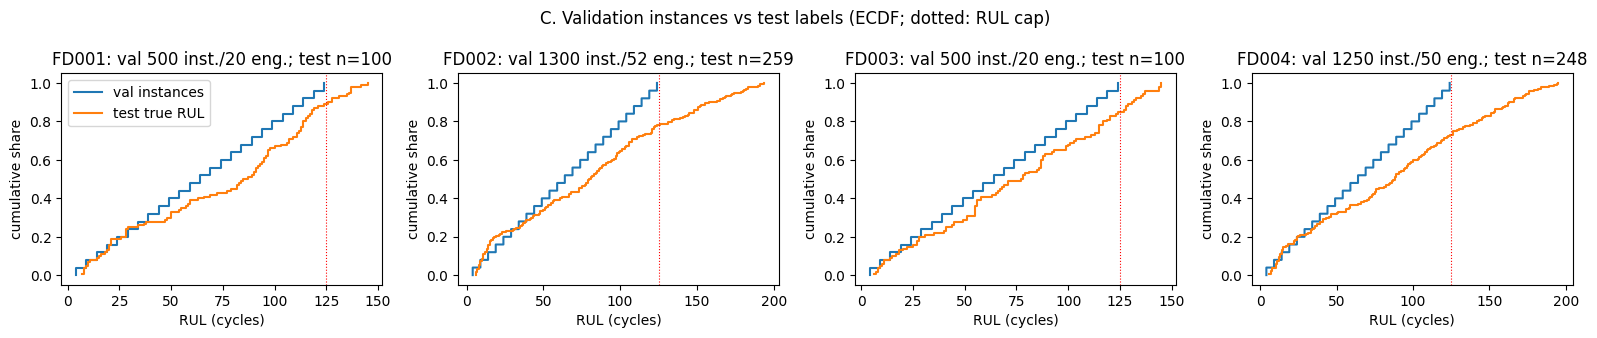

In [ ]:
# Copied from archive/02_modeling.ipynb cell 2, logic unchanged. It reads only unit, cycle and the
# capped rul, so the raw validation frame gives the same rows as the feature frame.
def make_val_instances(feat_df, step=5):
    # Sample a truncation instance at every step-th cycle from each val engine's
    # degradation phase (RUL < 125). Covers the full RUL range, matching the
    # test-set distribution. Skips the healthy plateau where RUL is capped.
    parts = []
    for unit, grp in feat_df.groupby("unit"):  # noqa: B007 — kept as in nb02
        degrade = grp[grp["rul"] < RUL_CAP].sort_values("cycle")
        if len(degrade) == 0:
            degrade = grp.sort_values("cycle")
        parts.append(degrade.iloc[::step])
    return pd.concat(parts, ignore_index=True)


def ks_boot(groups_a: list[np.ndarray], b: np.ndarray, rng) -> tuple[float, float, float]:
    """KS distance, pooled groups_a vs b; CI resamples engines on both sides (turbofan.stats)."""
    return ks_2samp_ci(groups_a, b, rng, n_boot=N_BOOT, ci_level=CI_LEVEL)


rows, C_inst = [], {}
for ds in DATASETS:
    rng = rng_for("C", ds)
    _, va_e = split_engines(train[ds], SPLIT_FRAC)
    va = train[ds][train[ds]["unit"].isin(va_e)]
    n_fallback = int((va.groupby("unit")["rul"].min() >= RUL_CAP).sum())
    inst = make_val_instances(va, step=VAL_STEP)
    C_inst[ds] = inst
    groups = [g["rul"].to_numpy(float) for _, g in inst.groupby("unit")]
    y_te = test_rul[ds].to_numpy(float)
    y_te_lt = y_te[y_te < RUL_CAP]
    ks_all = ks_boot(groups, y_te, rng)
    ks_lt = ks_boot(groups, y_te_lt, rng)
    rows.append(
        {
            "dataset": ds,
            "val engines": len(groups),
            "val instances": len(inst),
            "engines using fallback (no RUL<cap)": n_fallback,
            "val RUL range": f"{inst['rul'].min():.0f}–{inst['rul'].max():.0f}",
            "test engines": len(y_te),
            f"test RUL ≥ {RUL_CAP:.0f} (unreachable by val)": int((y_te >= RUL_CAP).sum()),
            "KS vs all test [95% CI]": f"{ks_all[0]:.3f} [{ks_all[1]:.3f}, {ks_all[2]:.3f}]",
            f"KS vs test RUL<{RUL_CAP:.0f} [95% CI]": (
                f"{ks_lt[0]:.3f} [{ks_lt[1]:.3f}, {ks_lt[2]:.3f}]"
            ),
            f"test n (RUL<{RUL_CAP:.0f})": len(y_te_lt),
            "val median": f"{np.median(inst['rul']):.0f}",
            "test median": f"{np.median(y_te):.0f}",
        }
    )
C = pd.DataFrame(rows)
display(C)

fig, axes = plt.subplots(1, 4, figsize=(16, 3.4))
for ax, ds in zip(axes, DATASETS, strict=True):
    for vals, lab in ((C_inst[ds]["rul"], "val instances"), (test_rul[ds], "test true RUL")):
        v = np.sort(np.asarray(vals, float))
        ax.step(v, np.arange(1, len(v) + 1) / len(v), where="post", label=lab)
    ax.axvline(RUL_CAP, color="r", lw=0.8, ls=":")
    ax.set_title(
        f"{ds}: val {len(C_inst[ds])} inst./{C_inst[ds]['unit'].nunique()} eng.; "
        f"test n={len(test_rul[ds])}"
    )
    ax.set_xlabel("RUL (cycles)")
    ax.set_ylabel("cumulative share")
axes[0].legend()
fig.suptitle("C. Validation instances vs test labels (ECDF; dotted: RUL cap)")
fig.tight_layout()
fig_c = save_fig(fig, "C_val_vs_test_ecdf.png")
plt.show()

C_idx = C.set_index("dataset")
n_ge = {ds: int((test_rul[ds] >= RUL_CAP).sum()) for ds in DATASETS}
REPORT.append(
    "## C. Validation realism\n\n"
    f"`make_val_instances` (nb02 cell 2, logic copied unchanged; step = {VAL_STEP}) applied to the "
    f"pipeline's validation engines (`split_engines`, `SPLIT_FRAC` = {SPLIT_FRAC}), compared "
    "with the test true-RUL labels. KS = two-sample Kolmogorov–Smirnov statistic (0 = identical "
    "distributions). The CI resamples validation engines (with all their instances) and test "
    "engines independently; a percentile bootstrap of KS is biased upward, so a point estimate "
    "can sit at or below the CI's lower end.\n\n" + md_table(C) + f"\n\n![ECDF]({fig_c})\n\n"
    "- By construction validation instances have RUL "
    f"{C_inst[DATASETS[0]]['rul'].min():.0f}–{C_inst[DATASETS[0]]['rul'].max():.0f} "
    f"(every {VAL_STEP}th cycle with capped RUL < {RUL_CAP:.0f}), and every validation engine "
    "contributes the same near-uniform spread, so the pooled validation median is "
    + ", ".join(f"{C_idx.loc[ds, 'val median']}" for ds in DATASETS)
    + " vs test medians "
    + ", ".join(f"{C_idx.loc[ds, 'test median']}" for ds in DATASETS)
    + " (FD001–FD004).\n"
    "- Test engines with true RUL ≥ the cap have no validation counterpart: "
    + ", ".join(f"{ds} {n_ge[ds]}/{len(test_rul[ds])}" for ds in DATASETS)
    + ".\n"
    "- Against the full test distribution the KS CI excludes 0 on every dataset; restricted to "
    "test engines with RUL below the cap the distance is smaller (table). nb02's comment that "
    'the instances match "the test-set distribution" holds at best for the RUL < cap part.\n'
)

In [ ]:
assert all(C_inst[ds]["rul"].max() < RUL_CAP for ds in DATASETS)
assert all(
    float(C.set_index("dataset").loc[ds, "KS vs all test [95% CI]"].split("[")[1].split(",")[0]) > 0
    for ds in DATASETS
)

**Takeaway:** validation instances never reach the cap and sit lower than the test labels, so tuning on them optimises for the wrong distribution (D17, D13).

## D. Operating regimes

**Question:** how many operating regimes does each dataset have, and is the pipeline's regime model stable?
**Method:** KMeans on standardized op settings with a silhouette scan; a forced 2-way split tells a real boundary from noise because a real one moves sensor means. Stability (D05) is the adjusted Rand index across seeds.

,k=2,k=3,k=4,k=5,k=6,k=7,k=8,k=9,k=10
FD001,0.3597,0.3542,0.3516,0.3337,0.3491,0.3473,0.3450,0.3453,0.3337
FD002,0.6165,0.7987,0.8508,0.9308,0.9971,0.9387,0.9003,0.8693,0.8350
FD003,0.3592,0.3577,0.3502,0.3321,0.3436,0.3426,0.3430,0.3402,0.3320
FD004,0.6176,0.8023,0.8505,0.9313,0.9971,0.9353,0.8995,0.8641,0.8279


,raw std op1,raw std op2,raw std op3
FD001,0.002187,0.000293,0.000000
FD002,14.747376,0.310016,14.237735
FD003,0.002194,0.000294,0.000000
FD004,14.780722,0.310703,14.251954


,FD001,FD002,FD003,FD004
s10,NaN,6.674024,NaN,6.583247
s12,NaN,3.628672,NaN,3.654163
s13,0.031917,NaN,NaN,NaN
s14,NaN,NaN,0.031397,NaN
s16,NaN,5.428245,NaN,6.348255
s4,NaN,NaN,0.014270,NaN
s6,0.024967,NaN,NaN,NaN
s7,0.029763,NaN,NaN,NaN
s9,NaN,NaN,0.024603,NaN


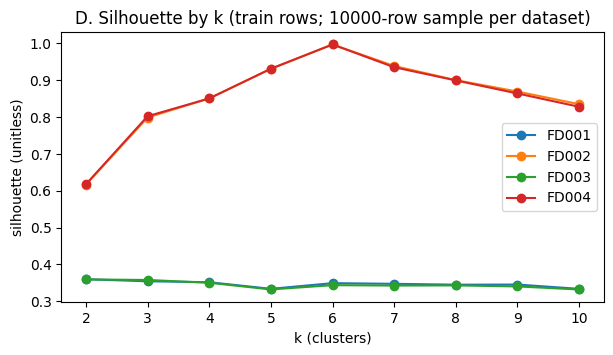

In [ ]:
D_sil, D_fit, D_scaler, D_sep = {}, {}, {}, {}
for ds in DATASETS:
    X_raw = train[ds][["op1", "op2", "op3"]]
    sc = StandardScaler().fit(X_raw)
    X = sc.transform(X_raw)
    D_scaler[ds] = sc
    sil, fits = {}, {}
    for k in K_RANGE:
        km = KMeans(n_clusters=k, n_init=AUDIT_KMEANS_N_INIT, random_state=AUDIT_KMEANS_SEED)
        lab = km.fit_predict(X)
        fits[k] = km
        sil[k] = float(silhouette_score(X, lab, sample_size=SIL_SAMPLE, random_state=SIL_SEED))
    D_sil[ds], D_fit[ds] = sil, fits
    # forced 2-way split: max over sensors of |mean diff| / pooled within-cluster std
    lab2 = fits[2].labels_
    sens = train[ds][SENSORS]
    eff = {}
    for s in SENSORS:
        a, b = sens[s][lab2 == 0], sens[s][lab2 == 1]
        if a.nunique() == 1 and b.nunique() == 1:
            # single-valued in both clusters: compare values exactly (float means of identical
            # values can differ in the last bit, which would fake an effect)
            eff[s] = 0.0 if a.iloc[0] == b.iloc[0] else np.inf
            continue
        pooled = np.sqrt(((len(a) - 1) * a.var() + (len(b) - 1) * b.var()) / (len(a) + len(b) - 2))
        eff[s] = abs(a.mean() - b.mean()) / pooled
    D_sep[ds] = pd.Series(eff)

sil_df = pd.DataFrame(D_sil).T
sil_df.columns = [f"k={k}" for k in K_RANGE]
display(sil_df.round(4))

raw_spread = pd.DataFrame(
    {ds: train[ds][["op1", "op2", "op3"]].std() for ds in DATASETS}
).T.add_prefix("raw std ")
display(raw_spread)
display(pd.DataFrame({ds: D_sep[ds].sort_values(ascending=False).head(3) for ds in DATASETS}))

fig, ax = plt.subplots(figsize=(7, 3.5))
for ds in DATASETS:
    ax.plot(K_RANGE, [D_sil[ds][k] for k in K_RANGE], marker="o", label=ds)
ax.set_xlabel("k (clusters)")
ax.set_ylabel("silhouette (unitless)")
ax.set_title(f"D. Silhouette by k (train rows; {SIL_SAMPLE}-row sample per dataset)")
ax.legend()
fig_d = save_fig(fig, "D_silhouette.png")
plt.show()

In [ ]:
D_kstar = {ds: max(D_sil[ds], key=D_sil[ds].get) for ds in DATASETS}
for ds in DATASETS:
    k = D_kstar[ds]
    km = D_fit[ds][k]
    centers = pd.DataFrame(
        D_scaler[ds].inverse_transform(km.cluster_centers_), columns=["op1", "op2", "op3"]
    )
    centers["rows"] = np.bincount(km.labels_, minlength=k)
    print(ds, "argmax-silhouette k =", k)
    display(centers.round(4))

# D05: the pipeline's own KMeans settings, varying only random_state
D05 = {}
for ds in DATASETS:
    X = D_scaler[ds].transform(train[ds][["op1", "op2", "op3"]])
    ref = KMeans(
        REGIME_N_CLUSTERS, n_init=REGIME_KMEANS_N_INIT, random_state=REGIME_KMEANS_SEED
    ).fit_predict(X)
    aris = [
        adjusted_rand_score(
            ref,
            KMeans(REGIME_N_CLUSTERS, n_init=REGIME_KMEANS_N_INIT, random_state=s).fit_predict(X),
        )
        for s in STABILITY_SEEDS
    ]
    D05[ds] = (min(aris), max(aris))
print("D05 ARI vs random_state=0 (min, max):", D05)

FD001 argmax-silhouette k = 2


,op1,op2,op3,rows
0,-0.0,-0.0002,100.0,11295
1,-0.0,0.0003,100.0,9336


FD002 argmax-silhouette k = 6


,op1,op2,op3,rows
0,42.0030,0.8405,100.0,13458
1,0.0015,0.0005,100.0,8044
2,25.0030,0.6205,60.0,8002
3,20.0030,0.7005,100.0,8122
4,10.0030,0.2505,100.0,8096
5,35.0030,0.8405,100.0,8037


FD003 argmax-silhouette k = 2


,op1,op2,op3,rows
0,-0.0002,-0.0002,100.0,12430
1,0.0002,0.0003,100.0,12290


FD004 argmax-silhouette k = 6


,op1,op2,op3,rows
0,42.0030,0.8405,100.0,15395
1,0.0015,0.0005,100.0,9238
2,25.0031,0.6205,60.0,9139
3,20.0030,0.7005,100.0,9091
4,10.0030,0.2505,100.0,9224
5,35.0030,0.8405,100.0,9162


D05 ARI vs random_state=0 (min, max): {'FD001': (0.8732117825017011, 1.0), 'FD002': (1.0, 1.0), 'FD003': (0.9389089091823398, 1.0), 'FD004': (1.0, 1.0)}


### D06 — do the normalization fallbacks fire?

**Method:** I fit the pipeline's regime model on the train split and apply it to the validation split — the path `add_features` takes — and count the cases each fallback exists for.

In [ ]:
D06 = {}
for ds in sorted(MULTI_REGIME):
    tr_e, va_e = split_engines(train[ds], SPLIT_FRAC)
    trs = train[ds][train[ds]["unit"].isin(tr_e)]
    vas = train[ds][train[ds]["unit"].isin(va_e)]
    sc = StandardScaler().fit(trs[["op1", "op2", "op3"]])
    km = KMeans(
        REGIME_N_CLUSTERS, n_init=REGIME_KMEANS_N_INIT, random_state=REGIME_KMEANS_SEED
    ).fit(sc.transform(trs[["op1", "op2", "op3"]]))
    r_tr = km.predict(sc.transform(trs[["op1", "op2", "op3"]]))
    r_va = km.predict(sc.transform(vas[["op1", "op2", "op3"]]))
    sd = trs[KEEP].groupby(r_tr).std()
    D06[ds] = {
        "train-split rows per regime (min)": int(np.bincount(r_tr).min()),
        "val regimes unseen in train": int(len(set(r_va) - set(r_tr))),
        "KEEP sensor × regime cells with std = 0": int((sd == 0).sum().sum()),
        "KEEP sensor × regime cells with std NaN": int(sd.isna().sum().sum()),
    }
display(pd.DataFrame(D06))

sep_tab = pd.DataFrame(
    {
        ds: {
            "largest forced-split shift (pooled SD)": (
                f"{D_sep[ds].replace(np.inf, np.nan).max():.3f}"
            ),
            "sensor": D_sep[ds].replace(np.inf, np.nan).idxmax(),
            "sensors single-valued per cluster but differing": int(np.isinf(D_sep[ds]).sum()),
        }
        for ds in DATASETS
    }
).T
display(sep_tab)

,FD002,FD004
train-split rows per regime (min),6410,7250
val regimes unseen in train,0,0
KEEP sensor × regime cells with std = 0,0,0
KEEP sensor × regime cells with std NaN,0,0


,largest forced-split shift (pooled SD),sensor,sensors single-valued per cluster but differing
FD001,0.032,s13,0
FD002,6.674,s10,0
FD003,0.031,s14,0
FD004,6.583,s10,0


In [ ]:
# Regimes used by the rest of the audit — chosen by inspecting the output above (see the
# markdown cell after this one and the report's section D): datasets whose op settings vary
# only at measurement-noise scale, with low silhouette at every k and no sensor separated by a
# forced split, are treated as single-regime; the others take the silhouette argmax.
SINGLE_REGIME = ("FD001", "FD003")
AUDIT_K = {ds: 1 if ds in SINGLE_REGIME else D_kstar[ds] for ds in DATASETS}
REG = {}
for ds in DATASETS:
    if AUDIT_K[ds] == 1:
        REG[ds] = np.zeros(len(train[ds]), dtype=int)
    else:
        REG[ds] = D_fit[ds][AUDIT_K[ds]].labels_
print(AUDIT_K)

centers6 = {}
for ds in DATASETS:
    k = D_kstar[ds]
    km = D_fit[ds][k]
    c = pd.DataFrame(
        D_scaler[ds].inverse_transform(km.cluster_centers_), columns=["op1", "op2", "op3"]
    )
    c["train rows"] = np.bincount(km.labels_, minlength=k)
    centers6[ds] = c.sort_values(["op1", "op3"]).round(3)
sil_md = sil_df.round(4).reset_index(names="dataset")
REPORT.append(
    "## D. Operating regimes\n\n"
    f"KMeans (n_init = {AUDIT_KMEANS_N_INIT}, random_state = {AUDIT_KMEANS_SEED}) on standardized "
    f"op1–op3, train rows only. Silhouette on a {SIL_SAMPLE}-row sample "
    f"(random_state = {SIL_SEED}).\n\n" + md_table(sil_md) + f"\n\n![silhouette]({fig_d})\n\n"
    "Raw spread of the operating settings (train rows):\n\n"
    + md_table(raw_spread.round(6).reset_index(names="dataset"))
    + "\n\nForced 2-way split: the largest shift it induces in any non-constant sensor, in "
    "pooled within-cluster SDs (a real regime boundary moves sensors; noise does not):\n\n"
    + md_table(sep_tab.reset_index(names="dataset"))
    + "\n\n**Choice.** "
    + " ".join(
        f"{ds}: single regime — op settings vary by at most {raw_spread.loc[ds].max():.4f} "
        f"(raw-unit SD), best silhouette {max(D_sil[ds].values()):.3f} (k = {D_kstar[ds]}), a "
        "forced split moves no sensor by more than "
        f"{D_sep[ds].replace(np.inf, np.nan).max():.3f} SD."
        for ds in SINGLE_REGIME
    )
    + " "
    + " ".join(
        f"{ds}: k = {AUDIT_K[ds]} (silhouette {D_sil[ds][AUDIT_K[ds]]:.4f}; next best "
        f"{sorted(D_sil[ds].values())[-2]:.4f})."
        for ds in DATASETS
        if ds not in SINGLE_REGIME
    )
    + "\n\nCluster centers at the silhouette argmax, raw units:\n\n"
    + "\n\n".join(
        f"**{ds}**\n\n" + md_table(centers6[ds]) for ds in DATASETS if ds not in SINGLE_REGIME
    )
    + "\n\n**D05 — stability of the pipeline's own regime model** (k = "
    f"{REGIME_N_CLUSTERS}, n_init = {REGIME_KMEANS_N_INIT}) across random_state "
    f"{STABILITY_SEEDS[0]}–{STABILITY_SEEDS[-1]}: adjusted Rand index vs random_state = "
    f"{REGIME_KMEANS_SEED}, min–max: "
    + ", ".join(f"{ds} {D05[ds][0]:.3f}–{D05[ds][1]:.3f}" for ds in DATASETS)
    + " (FD001/FD003 listed for completeness; the pipeline does not cluster them).\n\n"
    "**D06 — do the normalization fallbacks fire on the pipeline's train/val split?** "
    "(regime model fit on the train split, applied to the validation split, as `add_features` "
    "does):\n\n" + md_table(pd.DataFrame(D06).reset_index(names="check")) + "\n"
)

{'FD001': 1, 'FD002': 6, 'FD003': 1, 'FD004': 6}


In [ ]:
assert AUDIT_K == {"FD001": 1, "FD002": 6, "FD003": 1, "FD004": 6}
assert all(D05[ds][0] == 1.0 for ds in MULTI_REGIME)
assert all(v == 0 for ds in D06 for k, v in D06[ds].items() if "rows" not in k)

**Takeaway:** FD002/FD004 have six regimes and FD001/FD003 one; the pipeline's regime model is seed-stable and its fallbacks never fire on train/val (D04a, D04b, D05, D06).

**If asked to defend this:** I call FD001/FD003 single-regime by inspection, not silhouette — silhouette cannot score k = 1, their settings vary only at measurement-noise scale, and a forced split moves no sensor (tables above).

## E. Sensor informativeness

**Question:** which sensors carry a monotone degradation signal, per dataset, within regime?
**Method:** per-engine Spearman ρ between the regime-normalized sensor and `ttf`; a sensor is informative when its median |ρ| CI clears a noise baseline built by permuting `ttf` within each engine. I test |ρ|, not ρ: a sensor that rises in some engines and falls in others has a signed median near zero.
Classes: *constant* (single-valued in every regime), *flat*, *informative, consistent* (at least `SIGN_SHARE` of engines share the sign), *informative, mixed*.

**FD001** (regimes = 1, engines = 100)

,sensor,within-regime std (raw units),within/total variance,"median ρ(z, ttf) [95% CI]",ρ IQR across engines,median |ρ| [95% CI],noise baseline median |ρ| [95% CI],share of engines with majority sign,engines with ρ undefined,class,in KEEP
0,s1,0,n/a (1 regime),—,—,—,—,—,100,constant,no
1,s2,0.5001,n/a (1 regime),"-0.671 [-0.682, -0.649] (n=100)",-0.707 to -0.625,"0.671 [0.652, 0.683]","0.061 [0.046, 0.065]","1.00 [1.00, 1.00]",0,"informative, consistent",yes
2,s3,6.131,n/a (1 regime),"-0.637 [-0.659, -0.618] (n=100)",-0.678 to -0.585,"0.637 [0.618, 0.658]","0.049 [0.040, 0.055]","1.00 [1.00, 1.00]",0,"informative, consistent",yes
3,s4,9.001,n/a (1 regime),"-0.784 [-0.791, -0.775] (n=100)",-0.804 to -0.759,"0.784 [0.775, 0.791]","0.044 [0.036, 0.055]","1.00 [1.00, 1.00]",0,"informative, consistent",yes
4,s5,0,n/a (1 regime),—,—,—,—,—,100,constant,no
5,s6,0.001389,n/a (1 regime),"-0.126 [-0.166, -0.101] (n=62)",-0.192 to -0.083,"0.126 [0.101, 0.165]","0.043 [0.037, 0.056]","0.98 [0.95, 1.00]",38,"informative, consistent",no
6,s7,0.8851,n/a (1 regime),"0.774 [0.758, 0.783] (n=100)",0.715 to 0.802,"0.774 [0.759, 0.783]","0.056 [0.045, 0.065]","1.00 [1.00, 1.00]",0,"informative, consistent",yes
7,s8,0.07099,n/a (1 regime),"-0.768 [-0.786, -0.725] (n=100)",-0.816 to -0.603,"0.768 [0.729, 0.785]","0.046 [0.039, 0.057]","1.00 [1.00, 1.00]",0,"informative, consistent",yes
8,s9,22.08,n/a (1 regime),"-0.739 [-0.846, -0.463] (n=100)",-0.911 to 0.193,"0.751 [0.624, 0.843]","0.046 [0.034, 0.051]","0.71 [0.61, 0.80]",0,"informative, mixed",yes
9,s10,0,n/a (1 regime),—,—,—,—,—,100,constant,no


**FD002** (regimes = 6, engines = 260)

,sensor,within-regime std (raw units),within/total variance,"median ρ(z, ttf) [95% CI]",ρ IQR across engines,median |ρ| [95% CI],noise baseline median |ρ| [95% CI],share of engines with majority sign,engines with ρ undefined,class,in KEEP
0,s1,0,0.000,—,—,—,—,—,260,constant,no
1,s2,0.4449,0.000,"-0.617 [-0.629, -0.606] (n=260)",-0.664 to -0.564,"0.617 [0.606, 0.630]","0.054 [0.047, 0.059]","1.00 [1.00, 1.00]",0,"informative, consistent",yes
2,s3,5.687,0.003,"-0.598 [-0.609, -0.590] (n=260)",-0.635 to -0.555,"0.598 [0.590, 0.609]","0.050 [0.043, 0.060]","1.00 [1.00, 1.00]",0,"informative, consistent",yes
3,s4,7.848,0.004,"-0.739 [-0.749, -0.730] (n=260)",-0.775 to -0.703,"0.739 [0.731, 0.749]","0.046 [0.041, 0.053]","1.00 [1.00, 1.00]",0,"informative, consistent",yes
4,s5,0,0.000,—,—,—,—,—,260,constant,no
5,s6,0.004009,0.000,"-0.373 [-0.392, -0.354] (n=260)",-0.440 to -0.306,"0.373 [0.355, 0.391]","0.049 [0.042, 0.057]","1.00 [1.00, 1.00]",0,"informative, consistent",no
6,s7,0.5901,0.000,"0.504 [0.493, 0.524] (n=260)",0.438 to 0.561,"0.504 [0.493, 0.524]","0.046 [0.041, 0.052]","1.00 [1.00, 1.00]",0,"informative, consistent",yes
7,s8,0.2211,0.000,"-0.517 [-0.600, -0.393] (n=260)",-0.733 to -0.070,"0.517 [0.394, 0.598]","0.046 [0.040, 0.052]","0.83 [0.78, 0.87]",0,"informative, mixed",yes
8,s9,17.44,0.003,"-0.693 [-0.740, -0.578] (n=260)",-0.874 to 0.048,"0.699 [0.649, 0.740]","0.047 [0.041, 0.053]","0.73 [0.68, 0.79]",0,"informative, mixed",yes
9,s10,0.001983,0.000,"0.069 [0.062, 0.083] (n=260)",0.018 to 0.132,"0.080 [0.068, 0.091]","0.047 [0.041, 0.057]","0.80 [0.75, 0.85]",0,"informative, mixed",no


**FD003** (regimes = 1, engines = 100)

,sensor,within-regime std (raw units),within/total variance,"median ρ(z, ttf) [95% CI]",ρ IQR across engines,median |ρ| [95% CI],noise baseline median |ρ| [95% CI],share of engines with majority sign,engines with ρ undefined,class,in KEEP
0,s1,0,n/a (1 regime),—,—,—,—,—,100,constant,no
1,s2,0.523,n/a (1 regime),"-0.635 [-0.648, -0.624] (n=100)",-0.680 to -0.594,"0.635 [0.624, 0.648]","0.045 [0.035, 0.055]","1.00 [1.00, 1.00]",0,"informative, consistent",yes
2,s3,6.81,n/a (1 regime),"-0.639 [-0.647, -0.630] (n=100)",-0.672 to -0.609,"0.639 [0.630, 0.647]","0.046 [0.039, 0.056]","1.00 [1.00, 1.00]",0,"informative, consistent",yes
3,s4,9.773,n/a (1 regime),"-0.742 [-0.760, -0.729] (n=100)",-0.795 to -0.716,"0.742 [0.729, 0.759]","0.049 [0.030, 0.063]","1.00 [1.00, 1.00]",0,"informative, consistent",yes
4,s5,0,n/a (1 regime),—,—,—,—,—,100,constant,no
5,s6,0.01812,n/a (1 regime),"-0.083 [-0.115, -0.052] (n=82)",-0.169 to 0.144,"0.167 [0.129, 0.214]","0.044 [0.036, 0.055]","0.66 [0.56, 0.76]",18,"informative, mixed",no
6,s7,3.437,n/a (1 regime),"0.692 [-0.888, 0.740] (n=100)",-0.926 to 0.782,"0.820 [0.797, 0.888]","0.035 [0.029, 0.054]","0.56 [0.46, 0.66]",0,"informative, mixed",yes
7,s8,0.1583,n/a (1 regime),"-0.822 [-0.840, -0.797] (n=100)",-0.858 to -0.752,"0.822 [0.797, 0.840]","0.046 [0.032, 0.053]","1.00 [1.00, 1.00]",0,"informative, consistent",yes
8,s9,19.98,n/a (1 regime),"-0.860 [-0.872, -0.840] (n=100)",-0.890 to -0.568,"0.860 [0.841, 0.873]","0.047 [0.035, 0.066]","0.84 [0.76, 0.91]",0,"informative, mixed",yes
9,s10,0.003485,n/a (1 regime),"-0.700 [-0.728, -0.670] (n=44)",-0.755 to -0.653,"0.700 [0.669, 0.725]","0.031 [0.025, 0.049]","1.00 [1.00, 1.00]",56,"informative, consistent",no


**FD004** (regimes = 6, engines = 249)

,sensor,within-regime std (raw units),within/total variance,"median ρ(z, ttf) [95% CI]",ρ IQR across engines,median |ρ| [95% CI],noise baseline median |ρ| [95% CI],share of engines with majority sign,engines with ρ undefined,class,in KEEP
0,s1,0,0.000,—,—,—,—,—,249,constant,no
1,s2,0.4798,0.000,"-0.546 [-0.569, -0.530] (n=249)",-0.629 to -0.497,"0.546 [0.532, 0.569]","0.045 [0.041, 0.049]","1.00 [1.00, 1.00]",0,"informative, consistent",yes
2,s3,6.478,0.004,"-0.608 [-0.613, -0.599] (n=249)",-0.642 to -0.566,"0.608 [0.598, 0.614]","0.041 [0.034, 0.046]","1.00 [1.00, 1.00]",0,"informative, consistent",yes
3,s4,8.905,0.006,"-0.715 [-0.722, -0.706] (n=249)",-0.753 to -0.675,"0.715 [0.706, 0.722]","0.043 [0.038, 0.052]","1.00 [1.00, 1.00]",0,"informative, consistent",yes
4,s5,0,0.000,—,—,—,—,—,249,constant,no
5,s6,0.01492,0.000,"-0.265 [-0.279, -0.216] (n=249)",-0.371 to 0.103,"0.327 [0.303, 0.346]","0.041 [0.036, 0.049]","0.68 [0.63, 0.73]",0,"informative, mixed",no
6,s7,2.012,0.000,"0.351 [0.293, 0.386] (n=249)",-0.822 to 0.480,"0.541 [0.516, 0.580]","0.043 [0.037, 0.050]","0.59 [0.53, 0.65]",0,"informative, mixed",yes
7,s8,0.2128,0.000,"-0.735 [-0.767, -0.687] (n=249)",-0.827 to -0.291,"0.735 [0.684, 0.766]","0.042 [0.036, 0.047]","0.85 [0.80, 0.89]",0,"informative, mixed",yes
8,s9,17.8,0.003,"-0.837 [-0.847, -0.822] (n=249)",-0.868 to -0.531,"0.837 [0.823, 0.847]","0.044 [0.040, 0.049]","0.85 [0.80, 0.90]",0,"informative, mixed",yes
9,s10,0.005274,0.002,"-0.022 [-0.067, 0.027] (n=249)",-0.613 to 0.091,"0.158 [0.137, 0.197]","0.042 [0.039, 0.048]","0.51 [0.46, 0.58]",0,"informative, mixed",no


,"informative, not in KEEP","in KEEP, not informative"
FD001,[s6],[]
FD002,"[s6, s10, s16]",[]
FD003,"[s6, s10]",[]
FD004,"[s6, s10, s16]",[]


FD001 mean|ρ| raw/global: 0.708 [0.698, 0.727] (n=100)  regime-z: 0.708 [0.698, 0.728] (n=100)  Δ: 0.000 [0.000, 0.000] (n=100)
FD002 mean|ρ| raw/global: 0.139 [0.135, 0.144] (n=260)  regime-z: 0.584 [0.568, 0.597] (n=260)  Δ: 0.444 [0.434, 0.451] (n=260)
FD003 mean|ρ| raw/global: 0.756 [0.744, 0.765] (n=100)  regime-z: 0.756 [0.743, 0.765] (n=100)  Δ: 0.000 [0.000, 0.000] (n=100)
FD004 mean|ρ| raw/global: 0.153 [0.147, 0.159] (n=249)  regime-z: 0.651 [0.634, 0.670] (n=249)  Δ: 0.462 [0.450, 0.476] (n=249)


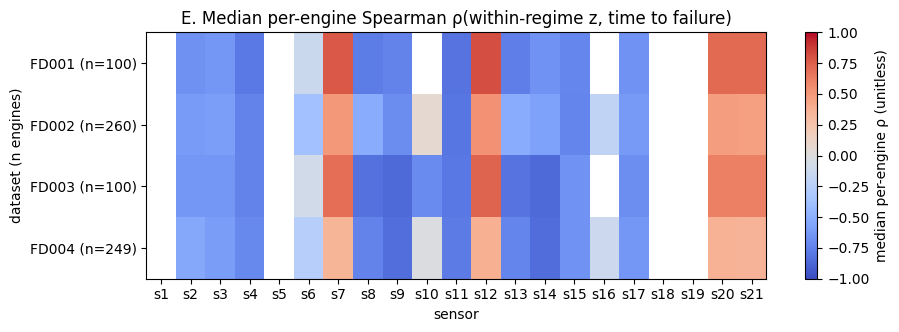

In [ ]:
SIGN_SHARE = 0.9  # E: share of engines agreeing in direction for "consistent" (audit choice)


def regime_z(
    df: pd.DataFrame, cols: list[str], reg: np.ndarray
) -> tuple[pd.DataFrame, pd.DataFrame]:
    g = df[cols].groupby(reg)
    single = g.transform("nunique") == 1
    z = (df[cols] - g.transform("mean")) / g.transform("std")
    # A sensor single-valued within a regime carries no variation there: z = 0 by definition
    # (reported as "constant" when that holds in every regime).
    return z.mask(single, 0.0), single


Z, E_rho, E_cls, E_tab, E_dir = {}, {}, {}, {}, {}
for ds in DATASETS:
    rng = rng_for("E", ds)
    df = train[ds]
    z, single = regime_z(df, SENSORS, REG[ds])
    Z[ds] = z
    rho = per_engine_spearman(z, df["ttf"], df["unit"])
    ttf_perm = df.groupby("unit")["ttf"].transform(lambda v, rng=rng: rng.permutation(v.to_numpy()))
    rho_null = per_engine_spearman(z, ttf_perm, df["unit"])
    E_rho[ds] = rho
    var_by_reg = df[SENSORS].groupby(REG[ds]).var().mask(single.groupby(REG[ds]).all(), 0.0)
    within_var = var_by_reg.mul(np.bincount(REG[ds]) - 1, axis=0).sum() / (len(df) - AUDIT_K[ds])
    rows = []
    for s in SENSORS:
        const_all = bool(single[s].all())
        r = rho[s].dropna()
        if const_all:
            cls, b_abs, b_null, b_med, share = "constant", None, None, None, None
        else:
            b_abs = boot(r.abs(), rng)
            b_null = boot(rho_null[s].dropna().abs(), rng)
            b_med = boot(r, rng)
            maj = np.sign(b_med[0])
            share = boot((np.sign(r) == maj).astype(float), rng, stat=np.mean)
            if b_abs[1] <= b_null[2]:
                cls = "flat"
            else:
                cls = "informative, consistent" if share[0] >= SIGN_SHARE else "informative, mixed"
            E_dir[ds, s] = -maj  # direction of change toward failure (ρ is vs time-to-failure)
        if AUDIT_K[ds] == 1:
            wt = "n/a (1 regime)"
        elif df[s].nunique() == 1:
            wt = "—"
        else:
            wt = f"{within_var[s] / df[s].var():.3f}"
        rows.append(
            {
                "sensor": s,
                "within-regime std (raw units)": f"{np.sqrt(within_var[s]):.4g}",
                "within/total variance": wt,
                "median ρ(z, ttf) [95% CI]": fmt(b_med, 3) if b_med else "—",
                "ρ IQR across engines": f"{r.quantile(0.25):.3f} to {r.quantile(0.75):.3f}"
                if b_med
                else "—",
                "median |ρ| [95% CI]": fmt(b_abs, 3).rsplit(" (", 1)[0] if b_abs else "—",
                "noise baseline median |ρ| [95% CI]": fmt(b_null, 3).rsplit(" (", 1)[0]
                if b_null
                else "—",
                "share of engines with majority sign": fmt(share, 2).rsplit(" (", 1)[0]
                if share
                else "—",
                "engines with ρ undefined": int(rho[s].isna().sum()),
                "class": cls,
                "in KEEP": "yes" if s in KEEP else "no",
            }
        )
        E_cls[ds, s] = cls
    E_tab[ds] = pd.DataFrame(rows)
    display(Markdown(f"**{ds}** (regimes = {AUDIT_K[ds]}, engines = {df['unit'].nunique()})"))
    display(E_tab[ds])

E_inf = {ds: [s for s in SENSORS if E_cls[ds, s].startswith("informative")] for ds in DATASETS}
E_cons = {ds: [s for s in SENSORS if E_cls[ds, s] == "informative, consistent"] for ds in DATASETS}
E_dis = {
    ds: {
        "informative, not in KEEP": [s for s in E_inf[ds] if s not in KEEP],
        "in KEEP, not informative": [s for s in KEEP if s not in E_inf[ds]],
    }
    for ds in DATASETS
}
display(pd.DataFrame(E_dis).T)

# D03: does per-regime normalization matter? Spearman per engine on raw values (= global
# z-score, an affine map) vs on within-regime z.
E_d03 = {}
for ds in DATASETS:
    rng = rng_for("E", ds)
    df = train[ds]
    rho_raw = per_engine_spearman(df[KEEP], df["ttf"], df["unit"])
    d = (E_rho[ds][KEEP].abs() - rho_raw.abs()).mean(axis=1)
    E_d03[ds] = (
        boot(rho_raw[KEEP].abs().mean(axis=1).dropna(), rng),
        boot(E_rho[ds][KEEP].abs().mean(axis=1).dropna(), rng),
        boot(d.dropna(), rng),
    )
for ds, (a, b_, d) in E_d03.items():
    print(ds, "mean|ρ| raw/global:", fmt(a, 3), " regime-z:", fmt(b_, 3), " Δ:", fmt(d, 3))

fig, ax = plt.subplots(figsize=(10, 3.2))
heat = pd.DataFrame({ds: E_rho[ds].median() for ds in DATASETS}).T
im = ax.imshow(heat.to_numpy(float), cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(SENSORS)), SENSORS)
ax.set_yticks(range(len(DATASETS)), [f"{ds} (n={train[ds]['unit'].nunique()})" for ds in DATASETS])
ax.set_xlabel("sensor")
ax.set_ylabel("dataset (n engines)")
ax.set_title("E. Median per-engine Spearman ρ(within-regime z, time to failure)")
fig.colorbar(im, label="median per-engine ρ (unitless)")
fig_e = save_fig(fig, "E_spearman_heatmap.png")
plt.show()

d03_tab = pd.DataFrame(
    [
        {
            "dataset": ds,
            "mean |ρ| over KEEP, raw (= global z)": fmt(a, 3),
            "mean |ρ| over KEEP, within-regime z": fmt(b_, 3),
            "paired Δ": fmt(d, 3),
        }
        for ds, (a, b_, d) in E_d03.items()
    ]
)
dis_tab = pd.DataFrame(
    [
        {
            "dataset": ds,
            **{k: ", ".join(v) or "—" for k, v in E_dis[ds].items()},
            "KEEP sensors with mixed direction": ", ".join(
                s for s in KEEP if E_cls[ds, s] == "informative, mixed"
            )
            or "—",
            "direction-consistent informative (used in F)": ", ".join(E_cons[ds]),
        }
        for ds in DATASETS
    ]
)
REPORT.append(
    "## E. Sensor informativeness\n\n"
    "Within-regime z-score with the regimes chosen in D. ρ = per-engine Spearman correlation "
    "between the normalized sensor and time to failure (uncapped). Classes: *constant* = a "
    "single value within every regime; *flat* = median |ρ| CI overlaps the noise baseline "
    "(`ttf` permuted within each engine); *informative* otherwise — *consistent* if ≥ "
    f"{SIGN_SHARE:.0%} of engines share the majority sign, else *mixed* (the sensor rises in some "
    "engines and falls in others).\n\n"
    + "\n\n".join(
        f"**{ds}** — {AUDIT_K[ds]} regime(s), {train[ds]['unit'].nunique()} engines\n\n"
        + md_table(E_tab[ds])
        for ds in DATASETS
    )
    + f"\n\n![heatmap]({fig_e})\n\n"
    "**Disagreements with `config.KEEP`:**\n\n"
    + md_table(dis_tab)
    + "\n\n**Per-regime vs global normalization (D03).** Spearman ρ is invariant to a global "
    "affine map, so ρ on raw values equals ρ on a global z-score:\n\n" + md_table(d03_tab) + "\n"
)

In [ ]:
assert all(E_cls[ds, s_].startswith("informative") for ds in DATASETS for s_ in KEEP)
assert all(E_dis[ds]["informative, not in KEEP"] for ds in DATASETS)
assert all(any(E_cls[ds, s_] == "informative, mixed" for s_ in KEEP) for ds in DATASETS)
assert all(E_d03[ds][1][0] > 3 * E_d03[ds][0][0] for ds in MULTI_REGIME)

**Takeaway:** every KEEP sensor is informative, KEEP misses informative sensors on every dataset, and some KEEP sensors change direction between engines (D02a, D02b, X04); within-regime normalization raises the FD002/FD004 sensors' association with failure several-fold (D03).

**If asked to defend this:** `SIGN_SHARE` is my choice, not a measured threshold; the share column lets a reader reclassify any sensor without rerunning.

## F. RUL-cap evidence

**Question:** how many cycles before failure does detectable degradation start — the quantity a RUL cap should sit near?
**Method:** per engine, a flat-then-linear (hinge) fit to a health signal built from the direction-consistent sensors of E; the change-point in remaining cycles is the onset. A hinge is the simplest model with exactly one onset, and the exhaustive fit has no seed.

,dataset,min_seg,engines,b ≤ 0 (excluded),no flat phase (τ at start),median RSS hinge/linear,p10 [95% CI],p25 [95% CI],p50 [95% CI],p75 [95% CI],p90 [95% CI],share onset ≤ 125 [95% CI]
0,FD001,5,100,0,0,0.399,"69 [65, 72]","76 [72, 84]","91 [86, 97]","106 [100, 113]","130 [113, 142]","0.87 [0.80, 0.93]"
1,FD001,10,100,0,0,0.399,"69 [65, 72]","76 [72, 84]","91 [86, 97]","106 [100, 113]","130 [113, 142]","0.87 [0.80, 0.93]"
2,FD001,20,100,0,0,0.399,"69 [65, 72]","76 [72, 84]","91 [86, 97]","106 [100, 113]","130 [113, 142]","0.87 [0.80, 0.93]"
3,FD002,5,260,0,0,0.560,"70 [69, 74]","80 [77, 85]","96 [93, 99]","113 [109, 117]","131 [124, 143]","0.87 [0.83, 0.91]"
4,FD002,10,260,0,0,0.560,"70 [69, 74]","80 [77, 85]","96 [93, 99]","113 [109, 117]","131 [124, 143]","0.87 [0.83, 0.91]"
5,FD002,20,260,0,0,0.560,"70 [69, 74]","80 [77, 85]","96 [93, 99]","113 [109, 117]","131 [124, 143]","0.87 [0.83, 0.91]"
6,FD003,5,100,0,0,0.393,"69 [65, 72]","76 [72, 82]","96 [86, 100]","114 [107, 126]","144 [126, 159]","0.81 [0.73, 0.88]"
7,FD003,10,100,0,0,0.393,"69 [65, 72]","76 [72, 82]","96 [86, 100]","114 [107, 126]","144 [126, 159]","0.81 [0.73, 0.88]"
8,FD003,20,100,0,0,0.393,"69 [65, 72]","76 [72, 82]","96 [86, 100]","114 [107, 126]","144 [126, 159]","0.81 [0.73, 0.88]"
9,FD004,5,249,0,0,0.514,"69 [67, 73]","82 [76, 85]","96 [93, 102]","120 [111, 125]","140 [132, 148]","0.81 [0.75, 0.85]"


**FD001**

,sensor,engines where sensor varies,of which slope toward failure,median onset ttf [95% CI]
0,s2,100/100,100,"94 [85, 98] (n=100)"
1,s3,100/100,100,"94 [81, 97] (n=100)"
2,s4,100/100,100,"92 [86, 98] (n=100)"
3,s6,62/100,62,"176 [147, 198] (n=62)"
4,s7,100/100,100,"91 [86, 100] (n=100)"
5,s8,100/100,100,"88 [80, 95] (n=100)"
6,s11,100/100,100,"91 [82, 99] (n=100)"
7,s12,100/100,100,"90 [85, 97] (n=100)"
8,s13,100/100,100,"86 [83, 94] (n=100)"
9,s15,100/100,100,"93 [89, 98] (n=100)"


**FD002**

,sensor,engines where sensor varies,of which slope toward failure,median onset ttf [95% CI]
0,s2,260/260,260,"97 [94, 103] (n=260)"
1,s3,260/260,260,"93 [90, 99] (n=260)"
2,s4,260/260,260,"91 [88, 95] (n=260)"
3,s6,260/260,260,"130 [124, 138] (n=260)"
4,s7,260/260,260,"97 [92, 102] (n=260)"
5,s11,260/260,260,"95 [93, 99] (n=260)"
6,s12,260/260,260,"95 [89, 102] (n=260)"
7,s15,260/260,260,"94 [91, 98] (n=260)"
8,s16,260/260,260,"64 [58, 70] (n=260)"
9,s17,260/260,260,"95 [91, 99] (n=260)"


**FD003**

,sensor,engines where sensor varies,of which slope toward failure,median onset ttf [95% CI]
0,s2,100/100,100,"100 [93, 106] (n=100)"
1,s3,100/100,100,"92 [87, 104] (n=100)"
2,s4,100/100,100,"98 [89, 104] (n=100)"
3,s8,100/100,100,"95 [88, 102] (n=100)"
4,s10,44/100,44,"91 [74, 105] (n=44)"
5,s11,100/100,100,"94 [88, 99] (n=100)"
6,s13,100/100,100,"94 [86, 102] (n=100)"
7,s17,100/100,100,"96 [90, 109] (n=100)"


**FD004**

,sensor,engines where sensor varies,of which slope toward failure,median onset ttf [95% CI]
0,s2,249/249,249,"100 [96, 106] (n=249)"
1,s3,249/249,249,"98 [94, 105] (n=249)"
2,s4,249/249,249,"102 [96, 106] (n=249)"
3,s11,249/249,249,"101 [96, 105] (n=249)"
4,s16,249/249,249,"59 [52, 63] (n=249)"
5,s17,249/249,249,"102 [97, 106] (n=249)"


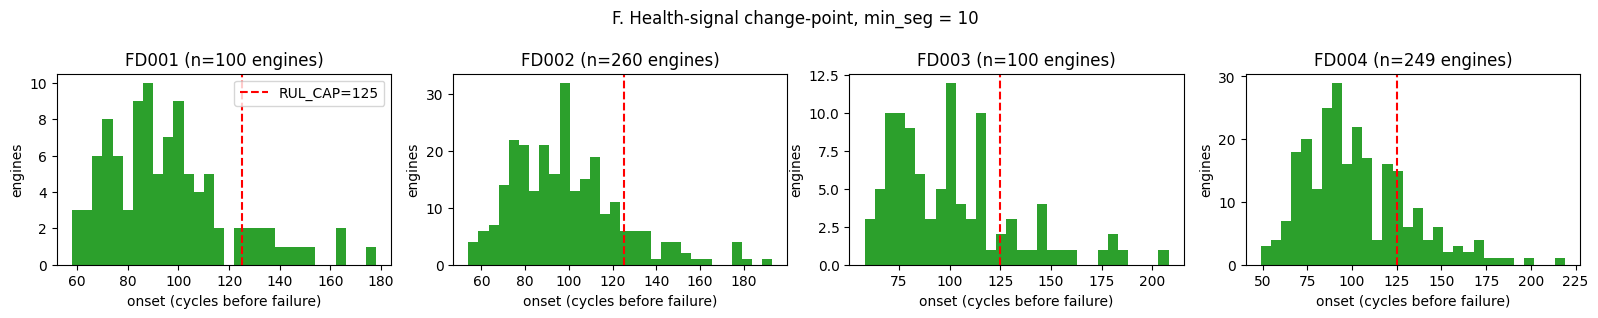

In [ ]:
def hinge_fit(t: np.ndarray, y: np.ndarray, min_seg: int):
    n = len(t)
    js = np.arange(min_seg - 1, n - min_seg)
    taus = t[js]
    H = np.maximum(0.0, t[None, :] - taus[:, None])
    Hc = H - H.mean(axis=1, keepdims=True)
    yc = y - y.mean()
    sxx = (Hc**2).sum(axis=1)
    sxy = Hc @ yc
    b = sxy / sxx
    rss = (yc**2).sum() - b * sxy
    i = int(np.argmin(rss))
    lin_b = np.dot(t - t.mean(), yc) / np.dot(t - t.mean(), t - t.mean())
    lin_rss = (yc**2).sum() - lin_b * np.dot(t - t.mean(), yc)
    return {
        "tau": float(taus[i]),
        "b": float(b[i]),
        "at_start": bool(i == 0),
        "rss": float(rss[i]),
        "lin_rss": float(lin_rss),
    }


def fit_engines(df: pd.DataFrame, signal: pd.Series, min_seg: int) -> pd.DataFrame:
    out = []
    for u, g in df.groupby("unit"):
        t = g["cycle"].to_numpy(float)
        f = hinge_fit(t, signal.loc[g.index].to_numpy(float), min_seg)
        f["unit"] = u
        f["T"] = t[-1]
        f["onset_ttf"] = t[-1] - f["tau"]
        out.append(f)
    return pd.DataFrame(out).set_index("unit")


HI, F_fits = {}, {}
for ds in DATASETS:
    signs = pd.Series({s: E_dir[ds, s] for s in E_cons[ds]})
    HI[ds] = (Z[ds][E_cons[ds]] * signs).mean(axis=1)
    for m in MIN_SEG_GRID:
        F_fits[ds, m] = fit_engines(train[ds], HI[ds], m)

QS = (0.10, 0.25, 0.50, 0.75, 0.90)
rows, F_onset, F_num = [], {}, {}
for ds in DATASETS:
    for m in MIN_SEG_GRID:
        rng = rng_for("F", ds)
        f = F_fits[ds, m]
        ok = f[f["b"] > 0]
        on = ok["onset_ttf"].to_numpy()
        F_onset[ds, m] = on
        row = {
            "dataset": ds,
            "min_seg": m,
            "engines": len(f),
            "b ≤ 0 (excluded)": int((f["b"] <= 0).sum()),
            "no flat phase (τ at start)": int(ok["at_start"].sum()),
            "median RSS hinge/linear": f"{np.median(ok['rss'] / ok['lin_rss']):.3f}",
        }
        qb = {
            q: boot(on, rng, stat=lambda a, axis=None, q=q: np.quantile(a, q, axis=axis))
            for q in QS
        }
        sb = boot((on <= RUL_CAP).astype(float), rng, stat=np.mean)
        F_num[ds, m] = (qb, sb)
        for q in QS:
            row[f"p{int(q * 100)} [95% CI]"] = f"{qb[q][0]:.0f} [{qb[q][1]:.0f}, {qb[q][2]:.0f}]"
        row[f"share onset ≤ {RUL_CAP:.0f} [95% CI]"] = f"{sb[0]:.2f} [{sb[1]:.2f}, {sb[2]:.2f}]"
        rows.append(row)
F = pd.DataFrame(rows)
display(F)

# per-sensor fits (unoriented z) at MIN_SEG_PRIMARY: reused by G for every informative sensor;
# F's robustness table uses the direction-consistent ones, oriented toward failure.
F_sens, F_sens_fits = {}, {}
for ds in DATASETS:
    rng = rng_for("F", ds)
    rows = []
    for s in E_inf[ds]:
        F_sens_fits[ds, s] = fit_engines(train[ds], Z[ds][s], MIN_SEG_PRIMARY)
    for s in E_cons[ds]:
        fs = F_sens_fits[ds, s]
        # engines where the raw sensor never changes have no trend to date (their fitted
        # slope is float noise around 0): excluded and counted
        varies = (train[ds].groupby("unit")[s].nunique() > 1).reindex(fs.index)
        fs_v = fs[varies.to_numpy()]
        ok = fs_v[np.sign(fs_v["b"]) == E_dir[ds, s]]
        rows.append(
            {
                "sensor": s,
                "engines where sensor varies": f"{len(fs_v)}/{len(fs)}",
                "of which slope toward failure": len(ok),
                "median onset ttf [95% CI]": fmt(boot(ok["onset_ttf"], rng), 0),
            }
        )
    F_sens[ds] = pd.DataFrame(rows)
    display(Markdown(f"**{ds}**"))
    display(F_sens[ds])

fig, axes = plt.subplots(1, 4, figsize=(16, 3.2))
for ax, ds in zip(axes, DATASETS, strict=True):
    ax.hist(F_onset[ds, MIN_SEG_PRIMARY], bins=30, color="tab:green")
    ax.axvline(RUL_CAP, color="r", ls="--", label=f"RUL_CAP={RUL_CAP:.0f}")
    ax.set_title(f"{ds} (n={len(F_onset[ds, MIN_SEG_PRIMARY])} engines)")
    ax.set_xlabel("onset (cycles before failure)")
    ax.set_ylabel("engines")
axes[0].legend()
fig.suptitle(f"F. Health-signal change-point, min_seg = {MIN_SEG_PRIMARY}")
fig.tight_layout()
fig_f = save_fig(fig, "F_changepoint.png")
plt.show()

Fq = {ds: F_num[ds, MIN_SEG_PRIMARY] for ds in DATASETS}
med_lo = min(Fq[ds][0][0.5][1] for ds in DATASETS)
med_hi = max(Fq[ds][0][0.5][2] for ds in DATASETS)
same_across_minseg = all(
    np.array_equal(F_onset[ds, m], F_onset[ds, MIN_SEG_PRIMARY])
    for ds in DATASETS
    for m in MIN_SEG_GRID
)
REPORT.append(
    "## F. RUL-cap evidence: per-engine change-point\n\n"
    "Health signal = mean of the direction-consistent informative sensors (E), oriented to rise "
    "toward failure. Per engine, `y = a + b·max(0, t − τ)` fitted by exhaustive search over τ "
    "(closed-form least squares; deterministic, no seed). Onset = remaining cycles at τ. "
    "Quantiles are across engines with a 95% bootstrap CI over engines.\n\n"
    + md_table(F)
    + "\n\n"
    + (
        "The minimum-segment constraint never binds: onsets are identical for min_seg "
        f"{', '.join(map(str, MIN_SEG_GRID))}.\n\n"
        if same_across_minseg
        else "Onsets differ across min_seg (see table).\n\n"
    )
    + f"![change-point]({fig_f})\n\n"
    "Per-sensor check (each direction-consistent sensor alone, min_seg = "
    f"{MIN_SEG_PRIMARY}):\n\n"
    + "\n\n".join(f"**{ds}**\n\n" + md_table(F_sens[ds]) for ds in DATASETS)
    + "\n\n**Defensible range (not a choice).** Median onset per dataset: "
    + ", ".join(
        f"{ds} {Fq[ds][0][0.5][0]:.0f} [{Fq[ds][0][0.5][1]:.0f}, {Fq[ds][0][0.5][2]:.0f}]"
        for ds in DATASETS
    )
    + f" — a cap at the typical engine's onset lies in **{med_lo:.0f}–{med_hi:.0f}** cycles. "
    "Middle half of engines (p25–p75 point estimates): "
    + ", ".join(f"{ds} {Fq[ds][0][0.25][0]:.0f}–{Fq[ds][0][0.75][0]:.0f}" for ds in DATASETS)
    + "; p90: "
    + ", ".join(f"{ds} {Fq[ds][0][0.9][0]:.0f}" for ds in DATASETS)
    + ". A cap meant to cover most engines' onsets sits at p75–p90, "
    f"**{min(Fq[ds][0][0.75][0] for ds in DATASETS):.0f}–"
    f"{max(Fq[ds][0][0.9][0] for ds in DATASETS):.0f}**. "
    f"The current cap {RUL_CAP:.0f} is at or above the onset of "
    + ", ".join(f"{ds} {Fq[ds][1][0]:.0%}" for ds in DATASETS)
    + " of engines.\n\n"
    "Caveats: a hinge fit dates the onset once the drift is resolvable above noise, so it "
    "estimates *detectable* onset, not physical onset; high-SNR sensors agree with the health "
    "signal, while low-SNR sensors (G) give very different onsets (per-sensor tables).\n"
)

In [ ]:
assert all(Fq[ds][0][0.5][0] < RUL_CAP and Fq[ds][0][0.75][0] < RUL_CAP for ds in DATASETS)

**Takeaway:** the data support a range of caps, not one value; the current cap sits above the median and upper quartile of detectable onset on every dataset (D01).

**If asked to defend this:** a hinge dates *detectable* onset — when drift clears noise — so physical onset is earlier; the per-sensor tables show high-SNR sensors agree with the health signal.

## G. Noise vs trend

**Question:** how noisy is each informative sensor relative to its end-of-life trend — the input to `WINDOW` and `SEQ_LEN`?
**Method:** noise from first differences, which slow trends barely touch; trend from each sensor's own hinge fit; the slope t-ratio says whether a w-cycle least-squares slope resolves the trend above noise.

In [ ]:
def diff_stats(z: pd.Series, unit: pd.Series) -> pd.DataFrame:
    out = []
    for u, v in z.groupby(unit.values):
        d = np.diff(v.to_numpy(float))
        ac = np.corrcoef(d[1:], d[:-1])[0, 1] if d.std() > 0 else np.nan
        out.append({"unit": u, "sigma": d.std(ddof=1) / np.sqrt(2), "ac1": ac})
    return pd.DataFrame(out).set_index("unit")


G_rows, G_eng = {}, {}
for ds in DATASETS:
    rng = rng_for("G", ds)
    rows = []
    for s in E_inf[ds]:
        dsx = diff_stats(Z[ds][s], train[ds]["unit"])
        fs = F_sens_fits[ds, s].join(dsx)
        const_eng = fs["sigma"] == 0  # sensor never changes within this engine
        if (fs.loc[~const_eng, "b"] == 0).any():
            raise ValueError(f"{ds} {s}: zero fitted slope in an engine where the sensor varies")
        n_const_eng = int(const_eng.sum())
        fs = fs[~const_eng].copy()
        fs["absb"] = fs["b"].abs()
        fs["delta"] = fs["absb"] * (fs["T"] - fs["tau"])
        fs["snr"] = fs["delta"] / fs["sigma"]
        fs["cyc_1sigma"] = fs["sigma"] / fs["absb"]
        for w in SLOPE_WINDOWS:
            fs[f"t{w}"] = fs["absb"] / (fs["sigma"] * np.sqrt(12 / (w * (w**2 - 1))))
        G_eng[ds, s] = fs
        row = {
            "sensor": s,
            "class": E_cls[ds, s].replace("informative, ", ""),
            "engines excluded (constant within engine)": n_const_eng,
            "σ (z)": fmt(boot(fs["sigma"], rng), 3),
            "Δ EOL change (z)": fmt(boot(fs["delta"], rng), 2),
            "SNR Δ/σ": fmt(boot(fs["snr"], rng), 1),
            "cycles to 1σ": fmt(boot(fs["cyc_1sigma"], rng), 0),
            "lag-1 ac(diff)": fmt(boot(fs["ac1"].dropna(), rng), 2),
        }
        for w in SLOPE_WINDOWS:
            row[f"slope t-ratio w={w}"] = fmt(boot(fs[f"t{w}"], rng), 2).rsplit(" (", 1)[0]
        rows.append(row)
    G_rows[ds] = pd.DataFrame(rows)
    display(Markdown(f"**{ds}**"))
    display(G_rows[ds])

REPORT.append(
    "## G. Noise vs trend\n\n"
    "All informative sensors, within-regime z units, per engine then median across engines "
    "(95% bootstrap CI over engines). σ = std(first difference)/√2; trend from the per-sensor "
    "hinge fit (F, unoriented): |b| per cycle, Δ = |b|·(T − τ). *Cycles to 1σ* = σ/|b|; "
    "*slope t-ratio* = |b| / (σ·√(12 / (w(w² − 1)))), the signal-to-noise of a least-squares "
    f"slope over a w-cycle window (w = {', '.join(map(str, SLOPE_WINDOWS))}: 15 from the removed "
    "family, then `WINDOW` and `SEQ_LEN`). Lag-1 autocorrelation of the first difference is "
    "−0.5 for white noise around a smooth trend; when it holds, averaging over w cycles cuts σ "
    "by √w.\n\n"
    + "\n\n".join(f"**{ds}**\n\n" + md_table(G_rows[ds]) for ds in DATASETS)
    + "\n\nThis section reports inputs to `WINDOW` / `SEQ_LEN`; it does not choose them.\n"
)

**FD001**

,sensor,class,engines excluded (constant within engine),σ (z),Δ EOL change (z),SNR Δ/σ,cycles to 1σ,lag-1 ac(diff),slope t-ratio w=15,slope t-ratio w=20,slope t-ratio w=30
0,s2,consistent,0,"0.609 [0.593, 0.621] (n=100)","2.18 [2.06, 2.31] (n=100)","3.6 [3.4, 3.7] (n=100)","25 [22, 29] (n=100)","-0.50 [-0.51, -0.48] (n=100)","0.66 [0.58, 0.74]","1.02 [0.91, 1.15]","1.87 [1.65, 2.12]"
1,s3,consistent,0,"0.654 [0.645, 0.660] (n=100)","2.09 [2.02, 2.24] (n=100)","3.3 [3.0, 3.5] (n=100)","29 [26, 31] (n=100)","-0.50 [-0.51, -0.49] (n=100)","0.58 [0.55, 0.64]","0.90 [0.84, 0.98]","1.66 [1.55, 1.82]"
2,s4,consistent,0,"0.448 [0.443, 0.458] (n=100)","2.44 [2.21, 2.56] (n=100)","5.4 [5.1, 5.7] (n=100)","18 [17, 20] (n=100)","-0.50 [-0.51, -0.49] (n=100)","0.95 [0.85, 1.02]","1.46 [1.32, 1.56]","2.69 [2.45, 2.88]"
3,s6,consistent,38,"1.035 [0.861, 1.296] (n=62)","0.47 [0.31, 0.74] (n=62)","0.5 [0.4, 0.5] (n=62)","339 [304, 394] (n=62)","-0.50 [-0.50, -0.50] (n=62)","0.05 [0.04, 0.06]","0.08 [0.07, 0.08]","0.14 [0.12, 0.16]"
4,s7,consistent,0,"0.463 [0.457, 0.471] (n=100)","2.27 [2.14, 2.48] (n=100)","5.0 [4.6, 5.3] (n=100)","18 [17, 20] (n=100)","-0.51 [-0.52, -0.49] (n=100)","0.91 [0.83, 0.99]","1.40 [1.28, 1.53]","2.57 [2.36, 2.81]"
5,s8,consistent,0,"0.428 [0.421, 0.433] (n=100)","2.06 [1.88, 2.29] (n=100)","5.0 [4.4, 5.2] (n=100)","18 [16, 20] (n=100)","-0.49 [-0.50, -0.48] (n=100)","0.92 [0.83, 1.08]","1.42 [1.28, 1.66]","2.61 [2.34, 2.97]"
6,s9,mixed,0,"0.190 [0.188, 0.193] (n=100)","0.92 [0.66, 1.66] (n=100)","4.6 [3.5, 8.8] (n=100)","15 [10, 21] (n=100)","-0.49 [-0.51, -0.48] (n=100)","1.15 [0.76, 1.62]","1.78 [1.17, 2.51]","3.27 [2.15, 4.61]"
7,s11,consistent,0,"0.380 [0.374, 0.386] (n=100)","2.42 [2.32, 2.63] (n=100)","6.3 [6.0, 6.8] (n=100)","14 [13, 15] (n=100)","-0.50 [-0.51, -0.48] (n=100)","1.20 [1.11, 1.29]","1.86 [1.71, 1.99]","3.41 [3.15, 3.66]"
8,s12,consistent,0,"0.408 [0.397, 0.412] (n=100)","2.34 [2.23, 2.46] (n=100)","5.9 [5.5, 6.3] (n=100)","16 [15, 18] (n=100)","-0.49 [-0.51, -0.48] (n=100)","1.06 [0.97, 1.13]","1.64 [1.49, 1.74]","3.01 [2.71, 3.19]"
9,s13,consistent,0,"0.422 [0.415, 0.430] (n=100)","2.12 [1.85, 2.28] (n=100)","5.0 [4.6, 5.4] (n=100)","17 [14, 18] (n=100)","-0.49 [-0.49, -0.47] (n=100)","0.99 [0.92, 1.16]","1.53 [1.41, 1.78]","2.81 [2.59, 3.27]"


**FD002**

,sensor,class,engines excluded (constant within engine),σ (z),Δ EOL change (z),SNR Δ/σ,cycles to 1σ,lag-1 ac(diff),slope t-ratio w=15,slope t-ratio w=20,slope t-ratio w=30
0,s2,consistent,0,"0.694 [0.689, 0.700] (n=260)","2.06 [1.99, 2.11] (n=260)","3.0 [2.9, 3.1] (n=260)","33 [31, 35] (n=260)","-0.50 [-0.51, -0.49] (n=260)","0.51 [0.48, 0.53]","0.78 [0.73, 0.82]","1.43 [1.35, 1.51]"
1,s3,consistent,0,"0.701 [0.696, 0.710] (n=260)","1.99 [1.92, 2.04] (n=260)","2.8 [2.8, 2.9] (n=260)","35 [33, 38] (n=260)","-0.50 [-0.50, -0.49] (n=260)","0.48 [0.45, 0.51]","0.74 [0.69, 0.79]","1.36 [1.27, 1.45]"
2,s4,consistent,0,"0.520 [0.513, 0.525] (n=260)","2.40 [2.32, 2.47] (n=260)","4.6 [4.5, 4.8] (n=260)","21 [20, 22] (n=260)","-0.50 [-0.50, -0.49] (n=260)","0.80 [0.77, 0.84]","1.24 [1.19, 1.29]","2.27 [2.18, 2.37]"
3,s6,consistent,0,"0.847 [0.835, 0.871] (n=260)","1.13 [1.09, 1.20] (n=260)","1.3 [1.3, 1.4] (n=260)","101 [94, 108] (n=260)","-0.51 [-0.51, -0.50] (n=260)","0.17 [0.15, 0.18]","0.26 [0.24, 0.27]","0.47 [0.44, 0.50]"
4,s7,consistent,0,"0.787 [0.779, 0.796] (n=260)","1.69 [1.63, 1.73] (n=260)","2.1 [2.0, 2.2] (n=260)","45 [42, 50] (n=260)","-0.50 [-0.50, -0.49] (n=260)","0.37 [0.33, 0.40]","0.57 [0.51, 0.62]","1.05 [0.94, 1.14]"
5,s8,mixed,0,"0.632 [0.606, 0.660] (n=260)","1.34 [1.20, 1.49] (n=260)","2.4 [2.0, 2.9] (n=260)","28 [24, 34] (n=260)","-0.50 [-0.51, -0.49] (n=260)","0.59 [0.50, 0.69]","0.91 [0.77, 1.07]","1.67 [1.41, 1.94]"
6,s9,mixed,0,"0.239 [0.237, 0.241] (n=260)","0.91 [0.82, 1.09] (n=260)","3.9 [3.3, 4.6] (n=260)","19 [16, 22] (n=260)","-0.49 [-0.50, -0.48] (n=260)","0.88 [0.75, 1.07]","1.36 [1.16, 1.65]","2.49 [2.13, 3.02]"
7,s10,mixed,0,"0.614 [0.562, 0.673] (n=260)","0.40 [0.36, 0.45] (n=260)","0.7 [0.6, 0.8] (n=260)","95 [79, 121] (n=260)","-0.50 [-0.50, -0.49] (n=260)","0.18 [0.14, 0.21]","0.27 [0.21, 0.33]","0.50 [0.39, 0.60]"
8,s11,consistent,0,"0.426 [0.423, 0.430] (n=260)","2.46 [2.38, 2.55] (n=260)","5.8 [5.6, 6.0] (n=260)","17 [16, 17] (n=260)","-0.50 [-0.51, -0.49] (n=260)","1.00 [0.96, 1.07]","1.55 [1.48, 1.65]","2.85 [2.72, 3.02]"
9,s12,consistent,0,"0.754 [0.748, 0.763] (n=260)","1.78 [1.69, 1.84] (n=260)","2.4 [2.3, 2.5] (n=260)","41 [39, 45] (n=260)","-0.49 [-0.50, -0.48] (n=260)","0.41 [0.37, 0.43]","0.63 [0.57, 0.67]","1.16 [1.04, 1.22]"


E:\turbofan-rul-prediction\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
E:\turbofan-rul-prediction\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


**FD003**

,sensor,class,engines excluded (constant within engine),σ (z),Δ EOL change (z),SNR Δ/σ,cycles to 1σ,lag-1 ac(diff),slope t-ratio w=15,slope t-ratio w=20,slope t-ratio w=30
0,s2,consistent,0,"0.580 [0.571, 0.583] (n=100)","2.05 [1.99, 2.19] (n=100)","3.6 [3.4, 3.8] (n=100)","28 [26, 30] (n=100)","-0.50 [-0.51, -0.48] (n=100)","0.61 [0.56, 0.64]","0.93 [0.86, 0.99]","1.72 [1.59, 1.83]"
1,s3,consistent,0,"0.592 [0.581, 0.603] (n=100)","2.15 [1.99, 2.28] (n=100)","3.6 [3.3, 3.8] (n=100)","27 [26, 29] (n=100)","-0.51 [-0.52, -0.49] (n=100)","0.61 [0.57, 0.65]","0.95 [0.88, 0.99]","1.74 [1.62, 1.83]"
2,s4,consistent,0,"0.414 [0.408, 0.420] (n=100)","2.42 [2.35, 2.49] (n=100)","5.9 [5.6, 6.0] (n=100)","18 [16, 19] (n=100)","-0.50 [-0.51, -0.49] (n=100)","0.93 [0.89, 1.04]","1.43 [1.35, 1.60]","2.62 [2.49, 2.95]"
3,s6,mixed,18,"0.128 [0.109, 0.169] (n=82)","0.11 [0.07, 0.19] (n=82)","0.8 [0.6, 1.0] (n=82)","218 [137, 313] (n=82)","-0.50 [-0.50, -0.50] (n=81)","0.08 [0.05, 0.13]","0.12 [0.08, 0.19]","0.22 [0.15, 0.33]"
4,s7,mixed,0,"0.127 [0.122, 0.129] (n=100)","0.76 [0.69, 2.98] (n=100)","6.3 [5.8, 20.5] (n=100)","12 [7, 16] (n=100)","-0.49 [-0.50, -0.48] (n=100)","1.41 [1.08, 2.24]","2.18 [1.66, 3.34]","4.00 [3.08, 6.14]"
5,s8,consistent,0,"0.196 [0.194, 0.200] (n=100)","1.39 [1.22, 2.52] (n=100)","6.1 [5.6, 6.9] (n=100)","13 [12, 17] (n=100)","-0.49 [-0.51, -0.47] (n=100)","1.26 [0.97, 1.43]","1.95 [1.51, 2.20]","3.58 [2.77, 4.04]"
6,s9,mixed,0,"0.208 [0.204, 0.211] (n=100)","2.70 [2.43, 2.86] (n=100)","12.9 [11.7, 13.4] (n=100)","10 [8, 13] (n=100)","-0.49 [-0.50, -0.48] (n=100)","1.71 [1.24, 2.17]","2.63 [1.94, 3.38]","4.84 [3.58, 6.21]"
7,s10,consistent,56,"0.417 [0.388, 0.462] (n=44)","4.09 [4.05, 4.20] (n=44)","10.0 [9.2, 10.3] (n=44)","9 [8, 11] (n=44)","-0.48 [-0.51, -0.42] (n=44)","1.85 [1.58, 2.22]","2.86 [2.43, 3.42]","5.25 [4.47, 6.29]"
8,s11,consistent,0,"0.342 [0.336, 0.349] (n=100)","2.54 [2.46, 2.67] (n=100)","7.4 [6.9, 7.9] (n=100)","13 [12, 15] (n=100)","-0.50 [-0.52, -0.49] (n=100)","1.26 [1.15, 1.36]","1.94 [1.76, 2.09]","3.56 [3.23, 3.83]"
9,s12,mixed,0,"0.102 [0.096, 0.107] (n=100)","0.69 [0.63, 3.03] (n=100)","7.4 [6.6, 23.6] (n=100)","11 [7, 14] (n=100)","-0.49 [-0.50, -0.48] (n=100)","1.52 [1.24, 2.56]","2.35 [1.90, 3.94]","4.32 [3.47, 7.38]"


**FD004**

,sensor,class,engines excluded (constant within engine),σ (z),Δ EOL change (z),SNR Δ/σ,cycles to 1σ,lag-1 ac(diff),slope t-ratio w=15,slope t-ratio w=20,slope t-ratio w=30
0,s2,consistent,0,"0.650 [0.645, 0.655] (n=249)","1.76 [1.69, 1.80] (n=249)","2.7 [2.6, 2.8] (n=249)","37 [35, 40] (n=249)","-0.50 [-0.51, -0.49] (n=249)","0.45 [0.41, 0.48]","0.70 [0.64, 0.75]","1.29 [1.18, 1.37]"
1,s3,consistent,0,"0.620 [0.612, 0.628] (n=249)","2.05 [1.95, 2.11] (n=249)","3.3 [3.2, 3.4] (n=249)","32 [29, 34] (n=249)","-0.49 [-0.50, -0.48] (n=249)","0.53 [0.49, 0.57]","0.81 [0.76, 0.89]","1.50 [1.40, 1.64]"
2,s4,consistent,0,"0.467 [0.461, 0.473] (n=249)","2.23 [2.16, 2.28] (n=249)","4.7 [4.6, 4.9] (n=249)","22 [21, 23] (n=249)","-0.50 [-0.51, -0.49] (n=249)","0.76 [0.72, 0.81]","1.17 [1.11, 1.24]","2.15 [2.03, 2.28]"
3,s6,mixed,0,"0.280 [0.277, 0.284] (n=249)","0.34 [0.32, 0.36] (n=249)","1.2 [1.2, 1.3] (n=249)","110 [100, 121] (n=249)","-0.50 [-0.50, -0.49] (n=249)","0.15 [0.14, 0.17]","0.23 [0.21, 0.26]","0.43 [0.39, 0.48]"
4,s7,mixed,0,"0.310 [0.306, 0.313] (n=249)","0.69 [0.62, 0.75] (n=249)","2.3 [2.1, 2.6] (n=249)","37 [28, 42] (n=249)","-0.50 [-0.50, -0.49] (n=249)","0.46 [0.40, 0.60]","0.70 [0.62, 0.93]","1.29 [1.13, 1.70]"
5,s8,mixed,0,"0.431 [0.391, 0.491] (n=249)","2.42 [2.03, 2.54] (n=249)","4.5 [4.2, 5.2] (n=249)","18 [16, 20] (n=249)","-0.50 [-0.51, -0.49] (n=249)","0.94 [0.83, 1.05]","1.45 [1.28, 1.62]","2.66 [2.36, 2.99]"
6,s9,mixed,0,"0.245 [0.243, 0.248] (n=249)","2.58 [2.40, 2.80] (n=249)","10.5 [9.5, 11.2] (n=249)","10 [10, 12] (n=249)","-0.49 [-0.50, -0.49] (n=249)","1.63 [1.41, 1.74]","2.50 [2.09, 2.68]","4.60 [4.01, 4.91]"
7,s10,mixed,0,"0.501 [0.444, 0.555] (n=249)","0.44 [0.34, 0.60] (n=249)","1.0 [0.9, 1.6] (n=249)","36 [30, 49] (n=249)","-0.50 [-0.50, -0.49] (n=249)","0.47 [0.34, 0.55]","0.72 [0.53, 0.85]","1.33 [0.97, 1.56]"
8,s11,consistent,0,"0.368 [0.366, 0.371] (n=249)","2.34 [2.23, 2.41] (n=249)","6.3 [6.1, 6.5] (n=249)","16 [16, 17] (n=249)","-0.49 [-0.50, -0.48] (n=249)","1.02 [0.97, 1.06]","1.57 [1.49, 1.63]","2.88 [2.75, 3.00]"
9,s12,mixed,0,"0.257 [0.253, 0.260] (n=249)","0.61 [0.57, 0.67] (n=249)","2.5 [2.3, 2.9] (n=249)","30 [23, 34] (n=249)","-0.49 [-0.50, -0.48] (n=249)","0.56 [0.49, 0.76]","0.87 [0.75, 1.13]","1.60 [1.38, 2.17]"


In [ ]:
assert all(abs(float(np.median(G_eng[k]["ac1"].dropna())) + 0.5) < 0.05 for k in G_eng)

**Takeaway:** noise around the trend is white (lag-1 autocorrelation of differences at the white-noise value), so window length trades noise against lag; I report it and leave the choice to CV (D08, D10).

## H. The removed 258-feature family

**Question:** for each feature family the old pipeline used and the current one dropped, does the data show the property that would justify it?
**Method:** names recovered from the old model's `feature_names_` (no producing code survives; embedded below so `models/` isn't needed). Per family I measure the one property that would motivate it, on train engines only — this tests motivation, not benefit, so no model is fitted.

In [ ]:
FAMILY_258 = {
    "raw value": "sensor_N — the sensor reading (scaling unknown)",
    "rolling mean w∈{5,15,30}": "sensor_N_rmean_w — trailing mean over w cycles",
    "rolling std w∈{5,15,30}": "sensor_N_rstd_w — trailing std over w cycles",
    "rolling min/max w∈{5,15,30}": "sensor_N_rmin_w / rmax_w — trailing extremes over w cycles",
    "slope w∈{15,30}": "sensor_N_slope_w — trailing linear-trend slope over w cycles",
    "first difference": "sensor_N_diff1 — x_t − x_{t−1}",
    "EWM span 15": "sensor_N_ewm15 — exponentially weighted mean (span assumed from the name)",
    "tst": "sensor_N_tst — definition not recoverable (no code, no docs)",
    "cycle_raw / cycle_norm": "elapsed cycle; cycle_norm = cycle / max_train_cycle (362 in the "
    "FD001 artifact)",
    "interactions": "sensor_11×sensor_4, sensor_11×sensor_12, sensor_4×sensor_12",
    "health_index": "first principal component of the (normalized) kept sensors",
}
assert 14 * 18 + 2 + 3 + 1 == 258  # 18 per-sensor columns × 14 sensors + 6 globals

H_rows = []
for ds in DATASETS:
    rng = rng_for("H", ds)
    df, z = train[ds], Z[ds]
    unit = df["unit"]
    sens = [s for s in KEEP if E_cls[ds, s] != "constant"]
    rho0 = per_engine_spearman(z[sens], df["ttf"], unit).abs()
    if rho0.isna().any().any():
        raise ValueError(f"{ds}: a KEEP sensor is constant within some engine")

    # smoothing: rolling means and EWM vs the raw normalized value
    def smooth_gain(fn, z=z, sens=sens, unit=unit, df=df, rho0=rho0, rng=rng):
        sm = z[sens].groupby(unit.values).transform(fn)
        r = per_engine_spearman(sm, df["ttf"], unit).abs()
        return boot((r - rho0).mean(axis=1).dropna(), rng, stat=np.median)

    for w in SMOOTH_WINDOWS:
        b = smooth_gain(lambda v, w=w: v.rolling(w, min_periods=1).mean())
        H_rows.append(
            (
                ds,
                f"rolling mean w={w}",
                "noise large relative to per-cycle trend → "
                "smoothing raises monotone association with ttf",
                "median per-engine Δ|ρ(·,ttf)| vs raw z, mean over KEEP sensors",
                fmt(b, 3),
            )
        )
    b = smooth_gain(lambda v: v.ewm(span=EWM_SPAN, adjust=True).mean())
    H_rows.append(
        (
            ds,
            f"EWM span {EWM_SPAN}",
            "same as rolling mean",
            "median per-engine Δ|ρ(·,ttf)| vs raw z, mean over KEEP sensors",
            fmt(b, 3),
        )
    )

    # rolling std: does noise grow toward failure?  diff-std last TAIL_LEN vs first TAIL_LEN
    ratios, skews, kurts = [], [], []
    for _, g in z[sens].groupby(unit.values):
        d = g.diff().iloc[1:]
        early, late = d.iloc[:TAIL_LEN], d.iloc[-TAIL_LEN:]
        ratios.append(np.exp(np.log(late.std() / early.std()).mean()))
        skews.append(np.nanmean(sps.skew(d, axis=0)))
        kurts.append(np.nanmean(sps.kurtosis(d, axis=0)))
    H_rows.append(
        (
            ds,
            "rolling std",
            "noise level changes as the engine degrades",
            f"per-engine geo-mean over sensors of std(diff) last {TAIL_LEN} / first "
            f"{TAIL_LEN} cycles (1 = no change)",
            fmt(boot(ratios, rng), 2),
        )
    )
    H_rows.append(
        (
            ds,
            "rolling min/max",
            "non-Gaussian residuals (skew/heavy tails) — else "
            "min/max ≈ mean ± c·std and add nothing",
            "per-engine mean skewness of diff",
            fmt(boot(skews, rng), 3),
        )
    )
    H_rows.append(
        (
            ds,
            "rolling min/max",
            "(as above)",
            "per-engine mean excess kurtosis of diff (0 = Gaussian)",
            fmt(boot(kurts, rng), 3),
        )
    )

    # slope: resolvable within the window?  t-ratio from G, median over informative KEEP sensors
    inf_keep = [s for s in sens if s in E_inf[ds]]
    for w in SLOPE_WINDOWS:
        per_eng = pd.concat([G_eng[ds, s][f"t{w}"] for s in inf_keep], axis=1).median(axis=1)
        H_rows.append(
            (
                ds,
                f"slope w={w}",
                "end-of-life trend is resolvable above noise within w cycles",
                "per-engine median over informative KEEP sensors of slope t-ratio",
                fmt(boot(per_eng.dropna(), rng), 2),
            )
        )

    # diff1: per-cycle change informative?
    dz = z[sens].groupby(unit.values).diff()
    keep_rows = dz.notna().all(axis=1)
    r_d = per_engine_spearman(dz[keep_rows], df["ttf"][keep_rows], unit[keep_rows]).abs()
    H_rows.append(
        (
            ds,
            "first difference",
            "per-cycle change carries information beyond noise",
            "per-engine mean over sensors |ρ(diff1, ttf)|",
            fmt(boot(r_d.mean(axis=1).dropna(), rng), 3),
        )
    )
    ac = pd.concat([G_eng[ds, s]["ac1"] for s in inf_keep], axis=1).mean(axis=1)
    H_rows.append(
        (
            ds,
            "first difference",
            "(as above)",
            "per-engine mean lag-1 autocorrelation of diff (−0.5 = white noise)",
            fmt(boot(ac.dropna(), rng), 3),
        )
    )

    # cycle: elapsed cycles informative across engines only if lifetimes are homogeneous
    life = A_life[ds].to_numpy(float)
    H_rows.append(
        (
            ds,
            "cycle_raw / cycle_norm",
            "lifetimes homogeneous enough that elapsed "
            "cycles predict ttf (cycle_norm is a linear rescale: same ranks)",
            "coefficient of variation of train lifetime",
            fmt(
                boot(
                    life,
                    rng,
                    stat=lambda a, axis=None: a.std(axis=axis, ddof=1) / a.mean(axis=axis),
                ),
                3,
            ),
        )
    )

    # interactions: s4, s11, s12 redundancy and product gain (raw values; definition unknown)
    rr = {}
    for a_, b_ in (("s11", "s4"), ("s11", "s12"), ("s4", "s12")):
        rr[a_, b_] = per_engine_spearman(z[[a_]], z[b_], unit)[a_].dropna()
        H_rows.append(
            (
                ds,
                f"interaction {a_}×{b_}",
                "non-redundant sensors whose product adds "
                "information (if |ρ| between them ≈ 1 the product is a monotone "
                "re-expression of either one)",
                f"median per-engine ρ({a_}, {b_}), within-regime z",
                fmt(boot(rr[a_, b_], rng), 3),
            )
        )

    # health index: shared degradation factor?
    zs = z[sens].to_numpy(float)
    units_arr = unit.to_numpy()
    uniq = np.unique(units_arr)
    S = np.stack([zs[units_arr == u].sum(0) for u in uniq])
    C2 = np.stack([zs[units_arr == u].T @ zs[units_arr == u] for u in uniq])
    N = np.array([(units_arr == u).sum() for u in uniq], float)

    def evr1(ix, N=N, S=S, C2=C2):
        n_, s_, c_ = N[ix].sum(), S[ix].sum(0), C2[ix].sum(0)
        cov = c_ / n_ - np.outer(s_ / n_, s_ / n_)
        ev = np.linalg.eigvalsh(cov)
        return ev[-1] / ev.sum()

    est = evr1(np.arange(len(uniq)))
    bs = np.array([evr1(rng.integers(0, len(uniq), len(uniq))) for _ in range(N_BOOT)])
    lo, hi = np.quantile(bs, [ALPHA / 2, 1 - ALPHA / 2])
    H_rows.append(
        (
            ds,
            "health_index (PCA-1)",
            "kept sensors share one dominant degradation factor",
            "PC1 explained-variance ratio of within-regime z (pooled rows)",
            f"{est:.3f} [{lo:.3f}, {hi:.3f}] (n={len(uniq)})",
        )
    )
    cov = (C2.sum(0) / N.sum()) - np.outer(S.sum(0) / N.sum(), S.sum(0) / N.sum())
    w1 = np.linalg.eigh(cov)[1][:, -1]
    pc1 = pd.DataFrame({"pc1": zs @ w1}, index=df.index)
    r_pc = per_engine_spearman(pc1, df["ttf"], unit)["pc1"].abs()
    best = rho0.median().idxmax()
    gain = (r_pc - rho0[best]).dropna()
    H_rows.append(
        (
            ds,
            "health_index (PCA-1)",
            "(as above)",
            f"median per-engine |ρ(PC1, ttf)| − |ρ(best single sensor {best}, ttf)|",
            fmt(boot(gain, rng), 3),
        )
    )
    H_rows.append((ds, "tst", "unknown", "not measurable: definition not recoverable", "—"))

H = pd.DataFrame(
    H_rows,
    columns=[
        "dataset",
        "family",
        "motivating property",
        "measurement",
        "value [95% CI] (n engines)",
    ],
)
display(H)

fam_tab = pd.DataFrame(
    [{"family": k, "definition (from feature names)": v} for k, v in FAMILY_258.items()]
)
REPORT.append(
    "## H. The removed 258-feature family\n\n"
    "Names recovered from `feature_names_` in `models/xgboost_FD001_base.pkl` (inventoried in "
    "`reports/artifact_inventory.md` §C). No producing code exists in the working tree or git "
    "history, so definitions are read from the names. Per sensor (the same 14 as `KEEP`): raw, "
    "rmean/rstd/rmin/rmax × {5, 15, 30}, slope × {15, 30}, diff1, ewm15, tst = 18 × 14 = 252; "
    "plus cycle_raw, cycle_norm, 3 interactions and health_index = 258.\n\n"
    + md_table(fam_tab)
    + "\n\nFor each family: the signal property that would motivate it, and whether the data "
    "show it (train engines only; within-regime z from D/E; per-engine statistics, median and "
    "95% bootstrap CI over engines). No model is fitted.\n\n"
    + md_table(H)
    + "\n\nCaveat on the multi-regime rows: the late/early noise ratio and the excess kurtosis "
    "of first differences are computed on within-regime z, where consecutive cycles usually fall "
    "in different regimes; if degradation shifts a sensor by a different number of regime SDs "
    "in different regimes, that alone inflates late-life differences. This audit does not "
    "separate that effect from genuine noise growth.\n"
)

,dataset,family,motivating property,measurement,value [95% CI] (n engines)
0,FD001,rolling mean w=5,noise large relative to per-cycle trend → smoo...,"median per-engine Δ|ρ(·,ttf)| vs raw z, mean o...","0.140 [0.137, 0.144] (n=100)"
1,FD001,rolling mean w=15,noise large relative to per-cycle trend → smoo...,"median per-engine Δ|ρ(·,ttf)| vs raw z, mean o...","0.186 [0.181, 0.192] (n=100)"
2,FD001,rolling mean w=30,noise large relative to per-cycle trend → smoo...,"median per-engine Δ|ρ(·,ttf)| vs raw z, mean o...","0.199 [0.190, 0.206] (n=100)"
3,FD001,EWM span 15,same as rolling mean,"median per-engine Δ|ρ(·,ttf)| vs raw z, mean o...","0.186 [0.179, 0.191] (n=100)"
4,FD001,rolling std,noise level changes as the engine degrades,per-engine geo-mean over sensors of std(diff) ...,"1.01 [0.99, 1.03] (n=100)"
...,...,...,...,...,...
71,FD004,interaction s11×s12,non-redundant sensors whose product adds infor...,"median per-engine ρ(s11, s12), within-regime z","-0.312 [-0.359, -0.256] (n=249)"
72,FD004,interaction s4×s12,non-redundant sensors whose product adds infor...,"median per-engine ρ(s4, s12), within-regime z","-0.300 [-0.341, -0.223] (n=249)"
73,FD004,health_index (PCA-1),kept sensors share one dominant degradation fa...,PC1 explained-variance ratio of within-regime ...,"0.473 [0.440, 0.505] (n=249)"
74,FD004,health_index (PCA-1),(as above),"median per-engine |ρ(PC1, ttf)| − |ρ(best sing...","0.038 [0.030, 0.044] (n=249)"


In [ ]:
def hval_h(ds: str, family: str, sub: str = "") -> str:
    m = H[
        (H["dataset"] == ds)
        & (H["family"] == family)
        & H["measurement"].str.contains(sub, regex=False)
    ]
    if len(m) != 1:
        raise KeyError((ds, family, sub))
    return m.iloc[0]["value [95% CI] (n engines)"]


assert all(
    float(hval_h(ds, "health_index (PCA-1)", "best single").split(" [")[1].split(",")[0]) > 0
    and float(hval_h(ds, "rolling mean w=30").split(" [")[0])
    > float(hval_h(ds, "rolling mean w=15").split(" [")[0])
    for ds in DATASETS
)

**Takeaway:** of the dropped families only the PCA health index and longer smoothing windows show a motivating property; rolling min/max and first differences don't, and K checks the multi-regime rolling-std signal (D07, D09, X06).

## I. Engine subpopulations by degradation direction

**Question:** are the mixed-direction sensors of E one population with noisy signs, or distinct engine subpopulations?
**Method:** per engine, the sign vector of ρ(sensor, ttf); pairwise flip agreement against independence, then KMeans on the sign vectors. k = 1 vs 2 by a permutation test that keeps each sensor's flip rate but destroys co-occurrence; k > 2 by silhouette.

In [ ]:
N_PERM = 200  # I: permutations for the k = 1 vs k = 2 test
I_K_MAX = 8  # I: largest k in the silhouette scan


def km_fit(X: np.ndarray, k: int) -> KMeans:
    return KMeans(n_clusters=k, n_init=AUDIT_KMEANS_N_INIT, random_state=AUDIT_KMEANS_SEED).fit(X)


def ordered_labels(X: np.ndarray, k: int) -> np.ndarray:
    """KMeans labels renumbered by cluster size, largest first (C1)."""
    raw = km_fit(X, k).labels_
    order = np.argsort(-np.bincount(raw), kind="stable")
    return np.argsort(order)[raw]


def split_gain(X: np.ndarray) -> float:
    w1 = float(((X - X.mean(axis=0)) ** 2).sum())
    return 0.0 if w1 == 0 else 1.0 - km_fit(X, 2).inertia_ / w1


def boot_diff_median(a: np.ndarray, b: np.ndarray, rng) -> tuple[float, float, float]:
    """Median(a) − median(b), CI resampling engines within each group independently."""
    ia = rng.integers(0, len(a), size=(N_BOOT, len(a)))
    ib = rng.integers(0, len(b), size=(N_BOOT, len(b)))
    bs = np.median(a[ia], axis=1) - np.median(b[ib], axis=1)
    lo, hi = np.quantile(bs, [ALPHA / 2, 1 - ALPHA / 2])
    return float(np.median(a) - np.median(b)), float(lo), float(hi)


def ci3(t, p=2) -> str:
    return f"{t[0]:.{p}f} [{t[1]:.{p}f}, {t[2]:.{p}f}]"


I_sens, I_flip, I_excluded, I_pairs, I_test, I_k, I_sil = {}, {}, {}, [], {}, {}, {}
I_var: dict[str, dict[str, pd.Series]] = {}  # dataset -> {variant name: cluster labels}
for ds in DATASETS:
    rng = rng_for("I", ds)
    rho = E_rho[ds]
    sens = [s for s in E_inf[ds] if rho[s].notna().all()]
    I_excluded[ds] = [s for s in E_inf[ds] if s not in sens]
    sign = np.sign(rho[sens])
    if (sign == 0).any().any():
        raise ValueError(f"{ds}: ρ exactly 0 in some engine — sign undefined")
    flip = pd.DataFrame({s: sign[s] != np.sign(rho[s].median()) for s in sens})
    I_sens[ds], I_flip[ds] = sens, flip

    mixed = [s for s in sens if E_cls[ds, s] == "informative, mixed"]
    n = len(flip)
    for i, a in enumerate(mixed):
        for b in mixed[i + 1 :]:
            fa, fb = flip[a].to_numpy(float), flip[b].to_numpy(float)
            idx = rng.integers(0, n, size=(N_BOOT, n))
            obs_bs = (fa[idx] == fb[idx]).mean(axis=1)
            pa, pb = fa[idx].mean(axis=1), fb[idx].mean(axis=1)
            exc_bs = obs_bs - (pa * pb + (1 - pa) * (1 - pb))
            obs = float((fa == fb).mean())
            exp_ = fa.mean() * fb.mean() + (1 - fa.mean()) * (1 - fb.mean())
            q = [ALPHA / 2, 1 - ALPHA / 2]
            I_pairs.append(
                {
                    "dataset": ds,
                    "pair": f"{a}–{b}",
                    "n engines": n,
                    "engines flipped (first / second)": f"{int(fa.sum())} / {int(fb.sum())}",
                    "agreement [95% CI]": ci3((obs, *np.quantile(obs_bs, q))),
                    "expected if independent": f"{exp_:.2f}",
                    "excess [95% CI]": ci3((obs - exp_, *np.quantile(exc_bs, q))),
                }
            )

    X = sign.to_numpy(float)
    obs_gain = split_gain(X)
    null = np.empty(N_PERM)
    for i in range(N_PERM):
        Xp = np.column_stack([rng.permutation(X[:, j]) for j in range(X.shape[1])])
        null[i] = split_gain(Xp)
    p_perm = (1 + int((null >= obs_gain).sum())) / (N_PERM + 1)
    n_patterns = len(np.unique(X, axis=0))
    sil = {}
    for k in range(2, min(I_K_MAX, n_patterns - 1) + 1):
        sil[k] = float(silhouette_score(X, km_fit(X, k).labels_))
    I_sil[ds] = sil
    k = 1 if p_perm > ALPHA else max(sil, key=sil.get)
    at_limit = bool(sil) and max(sil, key=sil.get) == max(sil)
    I_k[ds] = k
    lab = np.zeros(n, dtype=int) if k == 1 else ordered_labels(X, k)
    I_var[ds] = {} if k == 1 else {f"k={k} (silhouette)": pd.Series(lab, index=flip.index)}
    if k > 2 and at_limit:
        # silhouette still rising at the end of the scan: k is set by the scan limit, so the
        # 2-way split the permutation test validated is reported alongside
        I_var[ds]["k=2 (permutation-tested split)"] = pd.Series(
            ordered_labels(X, 2), index=flip.index
        )
    I_test[ds] = {
        "engines": n,
        "sensors in sign vector": len(sens),
        "mixed sensors": len(mixed),
        "distinct sign patterns": n_patterns,
        "2-way split gain (observed)": f"{obs_gain:.3f}",
        "null gain median [95% range]": (
            f"{np.median(null):.3f} [{np.quantile(null, ALPHA / 2):.3f}, "
            f"{np.quantile(null, 1 - ALPHA / 2):.3f}]"
        ),
        "permutation p": f"{p_perm:.4f}",
        "best silhouette (k)": (
            f"{max(sil.values()):.3f} ({max(sil, key=sil.get)})" if sil else "—"
        ),
        "k scanned": f"2–{max(sil)}" if sil else "—",
        "silhouette argmax at scan limit": "yes" if at_limit else "no",
        "chosen k": k,
        "cluster sizes": " / ".join(str(int(c)) for c in np.bincount(lab)),
    }

I_pairs_df = pd.DataFrame(I_pairs)
I_test_df = pd.DataFrame(I_test).T.reset_index(names="dataset")
display(I_pairs_df)
display(I_test_df)
display(pd.DataFrame({ds: I_sil[ds] for ds in DATASETS}).round(3))

,dataset,pair,n engines,engines flipped (first / second),agreement [95% CI],expected if independent,excess [95% CI]
0,FD001,s9–s14,100,29 / 40,"0.89 [0.83, 0.95]",0.54,"0.35 [0.27, 0.41]"
1,FD002,s8–s9,260,45 / 69,"0.85 [0.81, 0.90]",0.65,"0.20 [0.14, 0.25]"
2,FD002,s8–s10,260,45 / 52,"0.67 [0.62, 0.73]",0.70,"-0.02 [-0.05, 0.01]"
3,FD002,s8–s13,260,45 / 48,"0.97 [0.94, 0.98]",0.71,"0.26 [0.20, 0.32]"
4,FD002,s8–s14,260,45 / 104,"0.77 [0.72, 0.82]",0.57,"0.21 [0.16, 0.25]"
...,...,...,...,...,...,...,...
82,FD004,s14–s20,249,56 / 101,"0.37 [0.31, 0.43]",0.55,"-0.18 [-0.22, -0.14]"
83,FD004,s14–s21,249,56 / 101,"0.37 [0.31, 0.43]",0.55,"-0.18 [-0.22, -0.14]"
84,FD004,s15–s20,249,101 / 101,"1.00 [1.00, 1.00]",0.52,"0.48 [0.45, 0.50]"
85,FD004,s15–s21,249,101 / 101,"1.00 [1.00, 1.00]",0.52,"0.48 [0.45, 0.50]"


,dataset,engines,sensors in sign vector,mixed sensors,distinct sign patterns,2-way split gain (observed),null gain median [95% range],permutation p,best silhouette (k),k scanned,silhouette argmax at scan limit,chosen k,cluster sizes
0,FD001,100,14,2,3,0.821,"0.540 [0.538, 0.558]",0.0050,0.860 (2),2–2,yes,2,60 / 40
1,FD002,260,17,5,14,0.533,"0.271 [0.220, 0.276]",0.0050,0.922 (8),2–8,yes,8,117 / 39 / 35 / 29 / 22 / 7 / 6 / 5
2,FD003,100,14,7,4,0.838,"0.171 [0.144, 0.183]",0.0050,0.913 (3),2–3,yes,3,44 / 33 / 23
3,FD004,249,17,11,18,0.701,"0.113 [0.109, 0.117]",0.0050,0.892 (8),2–8,yes,8,74 / 73 / 31 / 19 / 18 / 18 / 9 / 7


,FD001,FD002,FD003,FD004
2,0.86,0.601,0.836,0.693
3,NaN,0.637,0.913,0.747
4,NaN,0.785,NaN,0.763
5,NaN,0.844,NaN,0.771
6,NaN,0.861,NaN,0.843
7,NaN,0.894,NaN,0.854
8,NaN,0.922,NaN,0.892


In [ ]:
I_clu_tabs, I_cmp, I_flipnum, I_diff = {}, {}, {}, {}
for ds, var, lab in [(d_, v, lb) for d_ in DATASETS for v, lb in I_var[d_].items()]:
    rng = rng_for("I", ds)
    flip = I_flip[ds]
    clusters = sorted(lab.unique())
    rows = []
    for s in I_sens[ds]:
        row = {"sensor": s, "class": E_cls[ds, s].replace("informative, ", "")}
        for c in clusters:
            v = flip.loc[lab == c, s].to_numpy(float)
            b = boot(v, rng, stat=np.mean)
            I_flipnum.setdefault((ds, var), {}).setdefault(c, {})[s] = b
            row[f"C{c + 1} flip share [95% CI]"] = fmt(b, 2).rsplit(" (", 1)[0]
        rows.append(row)
    I_clu_tabs[ds, var] = pd.DataFrame(rows)
    life = A_life[ds]
    onset = F_fits[ds, MIN_SEG_PRIMARY]
    if (onset["b"] <= 0).any():
        raise ValueError(f"{ds}: F health signal has non-rising engines")
    onset = onset["onset_ttf"]
    rows = []
    for c in clusters:
        u = lab.index[lab == c]
        rows.append(
            {
                "cluster": f"C{c + 1}",
                "engines": len(u),
                "lifetime median [95% CI]": fmt(boot(life.loc[u], rng), 0).rsplit(" (", 1)[0],
                "onset median [95% CI]": fmt(boot(onset.loc[u], rng), 0).rsplit(" (", 1)[0],
            }
        )
    for c in clusters[1:]:
        u0, u1 = lab.index[lab == clusters[0]], lab.index[lab == c]
        dl = boot_diff_median(life.loc[u1].to_numpy(float), life.loc[u0].to_numpy(float), rng)
        do = boot_diff_median(onset.loc[u1].to_numpy(float), onset.loc[u0].to_numpy(float), rng)
        I_diff.setdefault((ds, var), {})[c] = (dl, do)
        rows.append(
            {
                "cluster": f"C{c + 1} − C1",
                "engines": "",
                "lifetime median [95% CI]": ci3(dl, 0),
                "onset median [95% CI]": ci3(do, 0),
            }
        )
    I_cmp[ds, var] = pd.DataFrame(rows)
    display(Markdown(f"**{ds}** — {var}"))
    display(I_clu_tabs[ds, var])
    display(I_cmp[ds, var])


def flip_group(ds: str, var: str, c: int) -> list[str]:
    """Sensors predominantly flipped in cluster c (flip-share CI entirely above 0.5)."""
    return [s for s, b in I_flipnum[ds, var][c].items() if b[1] > 0.5]


def resolved(t: tuple[float, float, float], unit: str) -> str:
    return f"{t[0]:+.0f} {unit} [{t[1]:+.0f}, {t[2]:+.0f}]" + (
        "" if t[1] > 0 or t[2] < 0 else " (CI includes 0)"
    )


I_lines = []
for (ds, var), per_c in I_flipnum.items():
    parts = []
    for c in sorted(per_c):
        g = flip_group(ds, var, c)
        txt = f"C{c + 1} ({int((I_var[ds][var] == c).sum())} engines): flips " + (
            ", ".join(g) or "none"
        )
        if c in I_diff.get((ds, var), {}):
            dl, do = I_diff[ds, var][c]
            txt += f"; vs C1 lifetime {resolved(dl, 'cycles')}, onset {resolved(do, 'cycles')}"
        parts.append(txt)
    I_lines.append(f"- **{ds}, {var}:** " + "; ".join(parts) + ".")
limit_ds = [ds for ds in DATASETS if I_test[ds]["silhouette argmax at scan limit"] == "yes"]
REPORT.append(
    "## I. Engine subpopulations by degradation direction"
    + NL
    + NL
    + "Per engine, the sign of ρ(sensor, ttf) for each informative sensor of E defined in every "
    "engine (left out: "
    + "; ".join(f"{ds} {', '.join(I_excluded[ds])}" for ds in DATASETS if I_excluded[ds])
    + "). *Flipped* = sign opposite to the sensor's majority sign."
    + NL
    + NL
    + "**1. Do the same engines flip across mixed sensors?** Agreement = share of engines whose "
    "flip status matches on both sensors; *expected* = agreement if flips were independent; "
    "excess CI from a paired bootstrap over engines."
    + NL
    + NL
    + md_table(I_pairs_df)
    + NL
    + NL
    + f"**2. Clustering.** KMeans (n_init = {AUDIT_KMEANS_N_INIT}, random_state = "
    f"{AUDIT_KMEANS_SEED}) on the ±1 sign vectors. k = 1 vs k = 2: permutation test "
    f"({N_PERM} permutations, each sensor's signs shuffled independently across engines); "
    f"statistic = share of within-SS removed by a 2-way split. k = argmax silhouette over "
    f"2–{I_K_MAX} (bounded by distinct sign patterns − 1) when k = 1 is rejected."
    + NL
    + NL
    + md_table(I_test_df)
    + NL
    + NL
    + "Silhouette by k:"
    + NL
    + NL
    + md_table(pd.DataFrame({ds: I_sil[ds] for ds in DATASETS}).round(3).reset_index(names="k"))
    + NL
    + NL
    + "The permutation test rejects k = 1 on every dataset (p at its floor, 1/(N_PERM+1)). "
    "Silhouette, however, peaks at the end of the scanned range on "
    + ", ".join(f"{ds} (only k = 2 possible)" if len(I_sil[ds]) == 1 else ds for ds in limit_ds)
    + ": on discrete sign vectors it keeps rising as clusters approach individual sign "
    "patterns, so it does not identify k. Where that leaves k > 2, the 2-way split the "
    "permutation test validated is reported alongside."
    + NL
    + NL
    + "**3. Per cluster.** Flip share per sensor (CI over the cluster's engines), lifetime and "
    "health-signal onset (F method, min_seg = " + str(MIN_SEG_PRIMARY) + "); differences vs "
    "C1 (largest cluster) with CIs resampling within each cluster."
    + NL
    + NL
    + (NL + NL).join(
        f"**{ds} — {var}**"
        + NL
        + NL
        + md_table(I_clu_tabs[ds, var])
        + NL
        + NL
        + md_table(I_cmp[ds, var])
        for (ds, var) in I_clu_tabs
    )
    + NL
    + NL
    + "Summary (a sensor is listed as flipped in a cluster when its flip-share CI lies "
    "entirely above 0.5):"
    + NL
    + NL
    + NL.join(I_lines)
    + NL
    + NL
    + "Only what the data separate is stated: subpopulations defined by which sensors reverse "
    "direction, and whether lifetime/onset differ between them. No physical interpretation is "
    "attached to the clusters." + NL
)

**FD001** — k=2 (silhouette)

,sensor,class,C1 flip share [95% CI],C2 flip share [95% CI]
0,s2,consistent,"0.00 [0.00, 0.00]","0.00 [0.00, 0.00]"
1,s3,consistent,"0.00 [0.00, 0.00]","0.00 [0.00, 0.00]"
2,s4,consistent,"0.00 [0.00, 0.00]","0.00 [0.00, 0.00]"
3,s7,consistent,"0.00 [0.00, 0.00]","0.00 [0.00, 0.00]"
4,s8,consistent,"0.00 [0.00, 0.00]","0.00 [0.00, 0.00]"
5,s9,mixed,"0.00 [0.00, 0.00]","0.72 [0.57, 0.85]"
6,s11,consistent,"0.00 [0.00, 0.00]","0.00 [0.00, 0.00]"
7,s12,consistent,"0.00 [0.00, 0.00]","0.00 [0.00, 0.00]"
8,s13,consistent,"0.00 [0.00, 0.00]","0.00 [0.00, 0.00]"
9,s14,mixed,"0.00 [0.00, 0.00]","1.00 [1.00, 1.00]"


,cluster,engines,lifetime median [95% CI],onset median [95% CI]
0,C1,60,"202 [195, 215]","94 [86, 101]"
1,C2,40,"185 [167, 200]","87 [84, 97]"
2,C2 − C1,,"-17 [-43, -2]","-7 [-14, 6]"


**FD002** — k=8 (silhouette)

,sensor,class,C1 flip share [95% CI],C2 flip share [95% CI],C3 flip share [95% CI],C4 flip share [95% CI],C5 flip share [95% CI],C6 flip share [95% CI],C7 flip share [95% CI],C8 flip share [95% CI]
0,s2,consistent,"0.00 [0.00, 0.00]","0.00 [0.00, 0.00]","0.00 [0.00, 0.00]","0.00 [0.00, 0.00]","0.00 [0.00, 0.00]","0.00 [0.00, 0.00]","0.00 [0.00, 0.00]","0.00 [0.00, 0.00]"
1,s3,consistent,"0.00 [0.00, 0.00]","0.00 [0.00, 0.00]","0.00 [0.00, 0.00]","0.00 [0.00, 0.00]","0.00 [0.00, 0.00]","0.00 [0.00, 0.00]","0.00 [0.00, 0.00]","0.00 [0.00, 0.00]"
2,s4,consistent,"0.00 [0.00, 0.00]","0.00 [0.00, 0.00]","0.00 [0.00, 0.00]","0.00 [0.00, 0.00]","0.00 [0.00, 0.00]","0.00 [0.00, 0.00]","0.00 [0.00, 0.00]","0.00 [0.00, 0.00]"
3,s6,consistent,"0.00 [0.00, 0.00]","0.00 [0.00, 0.00]","0.00 [0.00, 0.00]","0.00 [0.00, 0.00]","0.00 [0.00, 0.00]","0.00 [0.00, 0.00]","0.00 [0.00, 0.00]","0.00 [0.00, 0.00]"
4,s7,consistent,"0.00 [0.00, 0.00]","0.00 [0.00, 0.00]","0.00 [0.00, 0.00]","0.00 [0.00, 0.00]","0.00 [0.00, 0.00]","0.00 [0.00, 0.00]","0.00 [0.00, 0.00]","0.00 [0.00, 0.00]"
5,s8,mixed,"0.00 [0.00, 0.00]","0.00 [0.00, 0.00]","1.00 [1.00, 1.00]","0.10 [0.00, 0.24]","0.00 [0.00, 0.00]","1.00 [1.00, 1.00]","0.00 [0.00, 0.00]","0.00 [0.00, 0.00]"
6,s9,mixed,"0.00 [0.00, 0.00]","0.00 [0.00, 0.00]","1.00 [1.00, 1.00]","1.00 [1.00, 1.00]","0.00 [0.00, 0.00]","0.00 [0.00, 0.00]","0.00 [0.00, 0.00]","1.00 [1.00, 1.00]"
7,s10,mixed,"0.00 [0.00, 0.00]","1.00 [1.00, 1.00]","0.14 [0.03, 0.29]","0.03 [0.00, 0.10]","0.00 [0.00, 0.00]","0.14 [0.00, 0.43]","1.00 [1.00, 1.00]","0.00 [0.00, 0.00]"
8,s11,consistent,"0.00 [0.00, 0.00]","0.00 [0.00, 0.00]","0.00 [0.00, 0.00]","0.00 [0.00, 0.00]","0.00 [0.00, 0.00]","0.00 [0.00, 0.00]","0.00 [0.00, 0.00]","0.00 [0.00, 0.00]"
9,s12,consistent,"0.00 [0.00, 0.00]","0.00 [0.00, 0.00]","0.00 [0.00, 0.00]","0.00 [0.00, 0.00]","0.00 [0.00, 0.00]","0.00 [0.00, 0.00]","0.00 [0.00, 0.00]","0.00 [0.00, 0.00]"


...

,sensor,class,C1 flip share [95% CI],C2 flip share [95% CI],C3 flip share [95% CI],C4 flip share [95% CI],C5 flip share [95% CI],C6 flip share [95% CI],C7 flip share [95% CI],C8 flip share [95% CI]
0,s2,consistent,"0.00 [0.00, 0.00]","0.00 [0.00, 0.00]","0.00 [0.00, 0.00]","0.00 [0.00, 0.00]","0.00 [0.00, 0.00]","0.00 [0.00, 0.00]","0.00 [0.00, 0.00]","0.00 [0.00, 0.00]"
1,s3,consistent,"0.00 [0.00, 0.00]","0.00 [0.00, 0.00]","0.00 [0.00, 0.00]","0.00 [0.00, 0.00]","0.00 [0.00, 0.00]","0.00 [0.00, 0.00]","0.00 [0.00, 0.00]","0.00 [0.00, 0.00]"
2,s4,consistent,"0.00 [0.00, 0.00]","0.00 [0.00, 0.00]","0.00 [0.00, 0.00]","0.00 [0.00, 0.00]","0.00 [0.00, 0.00]","0.00 [0.00, 0.00]","0.00 [0.00, 0.00]","0.00 [0.00, 0.00]"
3,s6,mixed,"0.00 [0.00, 0.00]","1.00 [1.00, 1.00]","0.00 [0.00, 0.00]","0.00 [0.00, 0.00]","0.00 [0.00, 0.00]","0.00 [0.00, 0.00]","0.67 [0.33, 1.00]","0.00 [0.00, 0.00]"
4,s7,mixed,"0.00 [0.00, 0.00]","1.00 [1.00, 1.00]","0.00 [0.00, 0.00]","1.00 [1.00, 1.00]","0.00 [0.00, 0.00]","0.00 [0.00, 0.00]","1.00 [1.00, 1.00]","0.00 [0.00, 0.00]"
5,s8,mixed,"0.00 [0.00, 0.00]","0.00 [0.00, 0.00]","1.00 [1.00, 1.00]","0.00 [0.00, 0.00]","0.00 [0.00, 0.00]","0.00 [0.00, 0.00]","0.00 [0.00, 0.00]","1.00 [1.00, 1.00]"
6,s9,mixed,"0.00 [0.00, 0.00]","0.00 [0.00, 0.00]","0.87 [0.74, 0.97]","0.00 [0.00, 0.00]","0.17 [0.00, 0.33]","0.00 [0.00, 0.00]","0.00 [0.00, 0.00]","1.00 [1.00, 1.00]"
7,s10,mixed,"1.00 [1.00, 1.00]","0.00 [0.00, 0.00]","1.00 [1.00, 1.00]","0.00 [0.00, 0.00]","0.89 [0.72, 1.00]","0.00 [0.00, 0.00]","0.00 [0.00, 0.00]","0.00 [0.00, 0.00]"
8,s11,consistent,"0.00 [0.00, 0.00]","0.00 [0.00, 0.00]","0.00 [0.00, 0.00]","0.00 [0.00, 0.00]","0.00 [0.00, 0.00]","0.00 [0.00, 0.00]","0.00 [0.00, 0.00]","0.00 [0.00, 0.00]"
9,s12,mixed,"0.00 [0.00, 0.00]","1.00 [1.00, 1.00]","0.00 [0.00, 0.00]","1.00 [1.00, 1.00]","0.00 [0.00, 0.00]","0.00 [0.00, 0.00]","1.00 [1.00, 1.00]","0.00 [0.00, 0.00]"


,cluster,engines,lifetime median [95% CI],onset median [95% CI]
0,C1,74,"212 [197, 230]","101 [94, 107]"
1,C2,73,"298 [285, 322]","104 [97, 110]"
2,C3,31,"178 [161, 194]","84 [77, 91]"
3,C4,19,"224 [199, 280]","88 [69, 100]"
4,C5,18,"186 [168, 224]","90 [76, 112]"
5,C6,18,"207 [190, 243]","88 [80, 105]"
6,C7,9,"261 [211, 379]","102 [76, 143]"
7,C8,7,"186 [149, 247]","89 [68, 125]"
8,C2 − C1,,"86 [62, 116]","3 [-5, 12]"
9,C3 − C1,,"-34 [-58, -14]","-17 [-28, -7]"


**FD004** — k=2 (permutation-tested split)

,sensor,class,C1 flip share [95% CI],C2 flip share [95% CI]
0,s2,consistent,"0.00 [0.00, 0.00]","0.00 [0.00, 0.00]"
1,s3,consistent,"0.00 [0.00, 0.00]","0.00 [0.00, 0.00]"
2,s4,consistent,"0.00 [0.00, 0.00]","0.00 [0.00, 0.00]"
3,s6,mixed,"0.00 [0.00, 0.00]","0.78 [0.70, 0.86]"
4,s7,mixed,"0.00 [0.00, 0.00]","1.00 [1.00, 1.00]"
5,s8,mixed,"0.26 [0.19, 0.33]","0.00 [0.00, 0.00]"
6,s9,mixed,"0.25 [0.18, 0.32]","0.00 [0.00, 0.00]"
7,s10,mixed,"0.82 [0.76, 0.88]","0.00 [0.00, 0.00]"
8,s11,consistent,"0.00 [0.00, 0.00]","0.00 [0.00, 0.00]"
9,s12,mixed,"0.00 [0.00, 0.00]","1.00 [1.00, 1.00]"


,cluster,engines,lifetime median [95% CI],onset median [95% CI]
0,C1,148,"200 [193, 211]","93 [89, 98]"
1,C2,101,"288 [272, 304]","102 [96, 106]"
2,C2 − C1,,"88 [66, 106]","9 [0, 14]"


In [ ]:
assert all(float(I_test[ds]["permutation p"]) <= ALPHA for ds in DATASETS)
assert all(I_test[ds]["silhouette argmax at scan limit"] == "yes" for ds in DATASETS)
assert all(
    dl[1] > 0 or dl[2] < 0
    for (ds, v), per_c in I_diff.items()
    if v.startswith("k=2")
    for dl, _ in per_c.values()
)

**Takeaway:** k = 1 is rejected on every dataset, and the 2-way subpopulations differ in lifetime as well as direction. The labels need the full trajectory, so they may stratify CV folds but never feed the model (D35).

**If asked to defend this:** I keep the permutation-tested 2-way split and discard the silhouette k — silhouette rises to the end of the scan on every dataset, so it tracks distinct sign patterns, not structure.

## J. Health-index consequence

**Question:** does a health index fitted on all engines cancel the opposing loadings of the subpopulations in I?
**Method:** PC1 of the regime-normalized KEEP sensors, fitted pooled and within each cluster; per engine, |ρ(PC1, ttf)| under its own cluster's PC1 against the pooled one, paired. Loadings carry bootstrap CIs, so a sign flip is distinguishable from noise.

In [ ]:
def pc1_fit(zs: np.ndarray, units_arr: np.ndarray, members: np.ndarray, orient: np.ndarray, rng):
    S = np.stack([zs[units_arr == u].sum(0) for u in members])
    C2 = np.stack([zs[units_arr == u].T @ zs[units_arr == u] for u in members])
    N = np.array([(units_arr == u).sum() for u in members], float)

    def eig(ix):
        n_, s_, c_ = N[ix].sum(), S[ix].sum(0), C2[ix].sum(0)
        val, vec = np.linalg.eigh(c_ / n_ - np.outer(s_ / n_, s_ / n_))
        return val[-1] / val.sum(), vec[:, -1]

    evr, w = eig(np.arange(len(members)))
    if float(w @ orient) < 0:
        w = -w
    evr_bs, w_bs = np.empty(N_BOOT), np.empty((N_BOOT, len(w)))
    for i in range(N_BOOT):
        e, v = eig(rng.integers(0, len(members), len(members)))
        evr_bs[i], w_bs[i] = e, (v if v @ w >= 0 else -v)
    q = [ALPHA / 2, 1 - ALPHA / 2]
    return (evr, *np.quantile(evr_bs, q)), w, np.quantile(w_bs, q, axis=0)


J_tabs, J_load, J_summary, J_delta = {}, {}, {}, {}
for ds, var, lab in [(d_, v, lb) for d_ in DATASETS for v, lb in I_var[d_].items()]:
    rng = rng_for("J", ds)
    df = train[ds]
    sens = [s for s in KEEP if E_cls[ds, s] != "constant"]
    zs = Z[ds][sens].to_numpy(float)
    units_arr = df["unit"].to_numpy()
    orient = np.array([E_dir.get((ds, s), 0.0) if s in E_cons[ds] else 0.0 for s in sens])
    groups = {"pooled": lab.index.to_numpy()} | {
        f"C{c + 1}": lab.index[lab == c].to_numpy() for c in sorted(lab.unique())
    }
    fits = {g: pc1_fit(zs, units_arr, m, orient, rng) for g, m in groups.items()}

    def rho_abs(w, members, zs=zs, units_arr=units_arr, df=df):
        rows_m = np.isin(units_arr, members)
        pc = pd.DataFrame({"pc1": zs[rows_m] @ w}, index=df.index[rows_m])
        return per_engine_spearman(pc, df["ttf"][rows_m], df["unit"][rows_m])["pc1"].abs()

    rows = []
    for g, m in groups.items():
        own = rho_abs(fits[g][1], m)
        row = {
            "fit": g,
            "engines": len(m),
            "PC1 explained variance [95% CI]": ci3(fits[g][0], 3),
            "median |ρ(own PC1, ttf)| [95% CI]": fmt(boot(own.dropna(), rng), 3).rsplit(" (", 1)[0],
        }
        if g != "pooled":
            pooled = rho_abs(fits["pooled"][1], m)
            row["same engines, pooled PC1"] = fmt(boot(pooled.dropna(), rng), 3).rsplit(" (", 1)[0]
            J_delta[ds, var, g] = boot((own - pooled).dropna(), rng)
            row["paired Δ (own − pooled) [95% CI]"] = fmt(J_delta[ds, var, g], 3).rsplit(" (", 1)[0]
        else:
            row["same engines, pooled PC1"] = "—"
            row["paired Δ (own − pooled) [95% CI]"] = "—"
        rows.append(row)
    J_tabs[ds, var] = pd.DataFrame(rows)
    J_load[ds, var] = pd.DataFrame(
        [
            {
                "sensor": s,
                "class": E_cls[ds, s].replace("informative, ", ""),
                **{
                    g: f"{fits[g][1][j]:+.2f} [{fits[g][2][0][j]:+.2f}, {fits[g][2][1][j]:+.2f}]"
                    for g in groups
                },
            }
            for j, s in enumerate(sens)
        ]
    )
    J_summary[ds, var] = {g: fits[g] for g in groups}
    display(Markdown(f"**{ds}** — {var}"))
    display(J_tabs[ds, var])
    display(J_load[ds, var])

J_lines = []
for (ds, var), fits in J_summary.items():
    sens = [s for s in KEEP if E_cls[ds, s] != "constant"]
    rev, canc = [], []
    for g in [g for g in fits if g != "pooled"]:
        _, wp, qp = fits["pooled"]
        _, wc, qc = fits[g]
        for j, s in enumerate(sens):
            c_sig = qc[0][j] > 0 or qc[1][j] < 0
            p_sig = qp[0][j] > 0 or qp[1][j] < 0
            if c_sig and p_sig and np.sign(wp[j]) != np.sign(wc[j]):
                rev.append(f"{s} in {g} ({wc[j]:+.2f} vs pooled {wp[j]:+.2f})")
            elif c_sig and not p_sig:
                canc.append(f"{s} in {g} ({wc[j]:+.2f} vs pooled {wp[j]:+.2f}, CI incl. 0)")
    tab = J_tabs[ds, var].set_index("fit")
    gains = [
        f"{g} {tab.loc[g, 'paired Δ (own − pooled) [95% CI]']}" for g in tab.index if g != "pooled"
    ]
    J_lines.append(
        f"- **{ds}, {var}:** loading sign reversed vs pooled: {'; '.join(rev) or 'none'}. "
        f"Pooled loading not resolved from 0 while the cluster's is: {'; '.join(canc) or 'none'}. "
        f"Paired Δ|ρ| (own − pooled PC1): {'; '.join(gains)}."
    )
REPORT.append(
    "## J. Health-index consequence of the subpopulations"
    + NL
    + NL
    + "PC1 of the within-regime z of the non-constant KEEP sensors, pooled vs fitted within each "
    "cluster of I; oriented to rise toward failure. Explained variance and loadings carry a "
    "bootstrap CI over the engines of that fit; |ρ(PC1, ttf)| is per engine."
    + NL
    + NL
    + (NL + NL).join(
        f"**{ds} — {var}**"
        + NL
        + NL
        + md_table(J_tabs[ds, var])
        + NL
        + NL
        + "Loadings:"
        + NL
        + NL
        + md_table(J_load[ds, var])
        for (ds, var) in J_tabs
    )
    + NL
    + NL
    + "Summary:"
    + NL
    + NL
    + NL.join(J_lines)
    + NL
)

**FD001** — k=2 (silhouette)

,fit,engines,PC1 explained variance [95% CI],"median |ρ(own PC1, ttf)| [95% CI]","same engines, pooled PC1",paired Δ (own − pooled) [95% CI]
0,pooled,100,"0.643 [0.618, 0.668]","0.932 [0.927, 0.937]",—,—
1,C1,60,"0.647 [0.621, 0.674]","0.928 [0.920, 0.933]","0.924 [0.913, 0.931]","0.004 [0.002, 0.008]"
2,C2,40,"0.758 [0.736, 0.774]","0.940 [0.937, 0.945]","0.938 [0.936, 0.942]","0.002 [0.001, 0.003]"


,sensor,class,pooled,C1,C2
0,s2,consistent,"+0.27 [+0.27, +0.28]","+0.27 [+0.26, +0.27]","+0.26 [+0.26, +0.27]"
1,s3,consistent,"+0.26 [+0.25, +0.27]","+0.27 [+0.26, +0.27]","+0.24 [+0.23, +0.24]"
2,s4,consistent,"+0.30 [+0.30, +0.30]","+0.30 [+0.29, +0.30]","+0.29 [+0.29, +0.29]"
3,s7,consistent,"-0.30 [-0.30, -0.29]","-0.28 [-0.29, -0.27]","-0.30 [-0.31, -0.30]"
4,s8,consistent,"+0.28 [+0.26, +0.30]","+0.23 [+0.20, +0.25]","+0.33 [+0.32, +0.34]"
5,s9,mixed,"+0.11 [+0.06, +0.15]","+0.24 [+0.19, +0.29]","-0.05 [-0.06, -0.04]"
6,s11,consistent,"+0.31 [+0.31, +0.31]","+0.30 [+0.29, +0.31]","+0.30 [+0.30, +0.31]"
7,s12,consistent,"-0.30 [-0.31, -0.30]","-0.28 [-0.29, -0.27]","-0.31 [-0.31, -0.31]"
8,s13,consistent,"+0.28 [+0.26, +0.30]","+0.23 [+0.20, +0.25]","+0.33 [+0.32, +0.34]"
9,s14,mixed,"+0.07 [+0.02, +0.11]","+0.21 [+0.16, +0.26]","-0.10 [-0.11, -0.08]"


**FD002** — k=8 (silhouette)

,fit,engines,PC1 explained variance [95% CI],"median |ρ(own PC1, ttf)| [95% CI]","same engines, pooled PC1",paired Δ (own − pooled) [95% CI]
0,pooled,260,"0.470 [0.459, 0.482]","0.884 [0.880, 0.888]",—,—
1,C1,117,"0.520 [0.505, 0.536]","0.894 [0.890, 0.897]","0.892 [0.888, 0.896]","0.002 [0.001, 0.002]"
2,C2,39,"0.577 [0.536, 0.618]","0.904 [0.887, 0.915]","0.882 [0.875, 0.892]","0.017 [0.009, 0.024]"
3,C3,35,"0.485 [0.462, 0.506]","0.878 [0.867, 0.887]","0.864 [0.845, 0.870]","0.019 [0.016, 0.023]"
4,C4,29,"0.544 [0.526, 0.558]","0.889 [0.878, 0.903]","0.880 [0.868, 0.895]","0.010 [0.007, 0.011]"
5,C5,22,"0.516 [0.487, 0.542]","0.887 [0.875, 0.900]","0.886 [0.872, 0.894]","0.000 [-0.002, 0.006]"
6,C6,7,"0.380 [0.347, 0.406]","0.838 [0.831, 0.869]","0.831 [0.805, 0.851]","0.010 [0.003, 0.021]"
7,C7,6,"0.563 [0.528, 0.593]","0.896 [0.884, 0.903]","0.894 [0.879, 0.902]","0.002 [-0.003, 0.008]"
8,C8,5,"0.538 [0.472, 0.575]","0.882 [0.866, 0.899]","0.869 [0.849, 0.881]","0.010 [0.008, 0.030]"


...

,fit,engines,PC1 explained variance [95% CI],"median |ρ(own PC1, ttf)| [95% CI]","same engines, pooled PC1",paired Δ (own − pooled) [95% CI]
0,pooled,249,"0.473 [0.444, 0.507]","0.873 [0.860, 0.889]",—,—
1,C1,74,"0.523 [0.498, 0.549]","0.900 [0.889, 0.907]","0.855 [0.834, 0.862]","0.053 [0.037, 0.058]"
2,C2,73,"0.787 [0.779, 0.794]","0.905 [0.898, 0.911]","0.906 [0.899, 0.912]","-0.001 [-0.002, -0.001]"
3,C3,31,"0.467 [0.435, 0.497]","0.875 [0.863, 0.883]","0.432 [0.309, 0.482]","0.444 [0.402, 0.568]"
4,C4,19,"0.794 [0.776, 0.808]","0.921 [0.911, 0.926]","0.923 [0.912, 0.927]","-0.002 [-0.003, -0.001]"
5,C5,18,"0.512 [0.470, 0.551]","0.875 [0.857, 0.890]","0.727 [0.670, 0.754]","0.152 [0.130, 0.217]"
6,C6,18,"0.636 [0.574, 0.691]","0.917 [0.910, 0.933]","0.876 [0.861, 0.897]","0.041 [0.037, 0.048]"
7,C7,9,"0.785 [0.758, 0.798]","0.910 [0.904, 0.918]","0.912 [0.903, 0.920]","-0.002 [-0.004, 0.004]"
8,C8,7,"0.478 [0.371, 0.546]","0.878 [0.851, 0.913]","0.285 [0.196, 0.417]","0.595 [0.434, 0.659]"


,sensor,class,pooled,C1,C2,C3,C4,C5,C6,C7,C8
0,s2,consistent,"+0.19 [+0.16, +0.22]","+0.31 [+0.28, +0.33]","+0.16 [+0.16, +0.16]","+0.38 [+0.37, +0.39]","+0.16 [+0.16, +0.17]","+0.39 [+0.38, +0.40]","+0.19 [+0.17, +0.22]","+0.16 [+0.15, +0.17]","+0.38 [+0.35, +0.40]"
1,s3,consistent,"+0.25 [+0.24, +0.28]","+0.29 [+0.27, +0.31]","+0.24 [+0.24, +0.24]","+0.33 [+0.32, +0.34]","+0.24 [+0.23, +0.24]","+0.34 [+0.33, +0.35]","+0.19 [+0.17, +0.22]","+0.24 [+0.23, +0.25]","+0.33 [+0.30, +0.36]"
2,s4,consistent,"+0.25 [+0.23, +0.28]","+0.32 [+0.29, +0.34]","+0.23 [+0.23, +0.24]","+0.42 [+0.41, +0.43]","+0.23 [+0.23, +0.24]","+0.42 [+0.41, +0.43]","+0.19 [+0.16, +0.22]","+0.23 [+0.22, +0.24]","+0.40 [+0.38, +0.42]"
3,s7,mixed,"+0.29 [+0.25, +0.32]","-0.07 [-0.08, -0.06]","+0.36 [+0.36, +0.36]","-0.11 [-0.12, -0.11]","+0.37 [+0.36, +0.37]","-0.12 [-0.12, -0.11]","-0.03 [-0.04, -0.02]","+0.36 [+0.36, +0.37]","-0.11 [-0.12, -0.10]"
4,s8,mixed,"+0.34 [+0.32, +0.35]","+0.31 [+0.28, +0.34]","+0.29 [+0.29, +0.29]","-0.04 [-0.07, +0.00]","+0.29 [+0.28, +0.30]","+0.04 [+0.01, +0.06]","+0.42 [+0.39, +0.44]","+0.29 [+0.27, +0.30]","-0.01 [-0.12, +0.05]"
5,s9,mixed,"+0.35 [+0.33, +0.36]","+0.34 [+0.30, +0.38]","+0.30 [+0.29, +0.30]","-0.09 [-0.13, -0.05]","+0.30 [+0.29, +0.30]","-0.02 [-0.05, +0.02]","+0.47 [+0.45, +0.48]","+0.29 [+0.29, +0.30]","-0.12 [-0.19, -0.07]"
6,s11,consistent,"+0.27 [+0.25, +0.29]","+0.31 [+0.28, +0.34]","+0.26 [+0.26, +0.26]","+0.42 [+0.42, +0.43]","+0.26 [+0.25, +0.27]","+0.42 [+0.41, +0.43]","+0.18 [+0.15, +0.21]","+0.25 [+0.25, +0.27]","+0.42 [+0.40, +0.43]"
7,s12,mixed,"+0.30 [+0.26, +0.33]","-0.06 [-0.07, -0.06]","+0.37 [+0.37, +0.37]","-0.10 [-0.11, -0.10]","+0.37 [+0.37, +0.38]","-0.10 [-0.11, -0.10]","-0.03 [-0.04, -0.02]","+0.38 [+0.37, +0.38]","-0.11 [-0.11, -0.10]"
8,s13,mixed,"+0.34 [+0.32, +0.35]","+0.31 [+0.28, +0.34]","+0.29 [+0.28, +0.29]","-0.04 [-0.07, +0.00]","+0.29 [+0.28, +0.30]","+0.04 [+0.01, +0.06]","+0.42 [+0.39, +0.44]","+0.29 [+0.28, +0.30]","-0.01 [-0.11, +0.05]"
9,s14,mixed,"+0.33 [+0.32, +0.35]","+0.31 [+0.26, +0.35]","+0.29 [+0.28, +0.29]","-0.17 [-0.21, -0.13]","+0.28 [+0.28, +0.29]","-0.09 [-0.13, -0.05]","+0.47 [+0.44, +0.48]","+0.28 [+0.28, +0.29]","-0.20 [-0.26, -0.16]"


**FD004** — k=2 (permutation-tested split)

,fit,engines,PC1 explained variance [95% CI],"median |ρ(own PC1, ttf)| [95% CI]","same engines, pooled PC1",paired Δ (own − pooled) [95% CI]
0,pooled,249,"0.473 [0.444, 0.507]","0.873 [0.860, 0.889]",—,—
1,C1,148,"0.453 [0.431, 0.478]","0.884 [0.873, 0.890]","0.799 [0.767, 0.834]","0.078 [0.058, 0.094]"
2,C2,101,"0.788 [0.781, 0.794]","0.910 [0.904, 0.911]","0.910 [0.905, 0.914]","-0.002 [-0.002, -0.001]"


,sensor,class,pooled,C1,C2
0,s2,consistent,"+0.19 [+0.16, +0.22]","+0.30 [+0.26, +0.34]","+0.16 [+0.16, +0.16]"
1,s3,consistent,"+0.25 [+0.24, +0.28]","+0.28 [+0.25, +0.32]","+0.24 [+0.24, +0.24]"
2,s4,consistent,"+0.25 [+0.23, +0.28]","+0.31 [+0.27, +0.36]","+0.23 [+0.23, +0.24]"
3,s7,mixed,"+0.29 [+0.25, +0.32]","-0.07 [-0.09, -0.05]","+0.36 [+0.36, +0.37]"
4,s8,mixed,"+0.34 [+0.32, +0.35]","+0.34 [+0.27, +0.38]","+0.29 [+0.29, +0.29]"
5,s9,mixed,"+0.35 [+0.33, +0.36]","+0.34 [+0.27, +0.40]","+0.30 [+0.29, +0.30]"
6,s11,consistent,"+0.27 [+0.25, +0.29]","+0.30 [+0.25, +0.35]","+0.26 [+0.26, +0.26]"
7,s12,mixed,"+0.30 [+0.26, +0.33]","-0.06 [-0.08, -0.05]","+0.37 [+0.37, +0.37]"
8,s13,mixed,"+0.34 [+0.32, +0.35]","+0.34 [+0.27, +0.38]","+0.29 [+0.29, +0.29]"
9,s14,mixed,"+0.33 [+0.32, +0.35]","+0.31 [+0.22, +0.38]","+0.29 [+0.28, +0.29]"


In [ ]:
assert all(
    max(J_delta[k][1] for k in J_delta if k[0] == ds and k[1].startswith("k=2")) > 0
    for ds in ("FD003", "FD004")
)

**Takeaway:** pooling gives the minority-direction engines loadings of the wrong sign, and their own-cluster health index tracks failure better (paired Δ column above), so a health index must be fitted per subpopulation or stratified (D07).

## K. Multi-regime noise growth: artifact check

**Question:** is H's late-life noise growth in FD002/FD004 real, or produced by normalizing across regimes?
**Method:** within each regime's own subsequence I remove a hinge trend and compare residual spread late vs early. Single-regime sets cut into interleaved subsequences of similar length are the control: they show what the method yields with no regimes at all.

In [ ]:
K_MIN_SEG = 5  # K: min points each side of the hinge within a regime subsequence
K_MIN_LEN = 15  # K: shortest subsequence analysed (3 thirds of ≥ 5 points)
K_CONTROL_SPLITS = 6  # K: interleaved splits for the single-regime control (= regimes in FD002)


def hinge_resid(t: np.ndarray, y: np.ndarray, min_seg: int) -> np.ndarray:
    f = hinge_fit(t, y, min_seg)
    h = np.maximum(0.0, t - f["tau"])
    a = y.mean() - f["b"] * h.mean()
    return y - (a + f["b"] * h)


K_rows, K_eng = [], {}
for ds in DATASETS:
    rng = rng_for("K", ds)
    df = train[ds]
    sens = [s for s in KEEP if E_cls[ds, s] != "constant"]
    if ds in MULTI_REGIME:
        part = pd.Series(REG[ds], index=df.index)
        how = f"{AUDIT_K[ds]} regimes"
    else:
        part = (df["cycle"] % K_CONTROL_SPLITS).rename(None)
        how = f"control: {K_CONTROL_SPLITS} interleaved splits"
    per_eng, k_short, k_zero = [], 0, 0
    for _, g in df.groupby("unit"):
        logs = []
        for _, sub in g.groupby(part.loc[g.index].to_numpy()):
            if len(sub) < K_MIN_LEN:
                k_short += 1
                continue
            t = sub["cycle"].to_numpy(float)
            third = len(sub) // 3
            for s in sens:
                r = hinge_resid(t, sub[s].to_numpy(float), K_MIN_SEG)
                first, last = r[:third].std(ddof=1), r[-third:].std(ddof=1)
                if first == 0 or last == 0:
                    k_zero += 1
                    continue
                logs.append(np.log(last / first))
        if not logs:
            raise ValueError(f"{ds}: an engine has no analysable subsequence")
        per_eng.append(np.exp(np.mean(logs)))
    K_eng[ds] = np.array(per_eng)
    K_rows.append(
        {
            "dataset": ds,
            "partition": how,
            "residual std ratio last/first third [95% CI]": fmt(boot(K_eng[ds], rng), 3),
            "H's diff-based ratio (all cycles, z)": H.loc[
                (H["dataset"] == ds) & (H["family"] == "rolling std"), "value [95% CI] (n engines)"
            ].item(),
            "subsequences skipped (< K_MIN_LEN)": k_short,
            "sensor-subsequences skipped (zero std)": k_zero,
        }
    )
K_df = pd.DataFrame(K_rows)
display(K_df)


# Control pairing from the data: each multi-regime set is compared with the single-regime set
# whose I flip group (2-way split) overlaps it most (Jaccard).
def k2_var(ds: str) -> str:
    return next(v for v in I_var[ds] if v.startswith("k=2"))


def groups_union(ds: str) -> set[str]:
    v = k2_var(ds)
    return {s for c in I_flipnum[ds, v] for s in flip_group(ds, v, c)}


K_ctrl, K_cmp, K_cmp_num = {}, [], {}
for ds in sorted(MULTI_REGIME):
    gm = groups_union(ds)
    jac = {
        c: len(gm & groups_union(c)) / len(gm | groups_union(c))
        for c in DATASETS
        if c not in MULTI_REGIME
    }
    K_ctrl[ds] = max(jac, key=jac.get)
    ctl = K_ctrl[ds]
    dlt = boot_diff_median(K_eng[ds], K_eng[ctl], rng_for("K", ds))
    K_cmp_num[ds] = dlt
    K_cmp.append(
        {
            "dataset": ds,
            "control": ctl,
            "flip-group Jaccard with control": f"{jac[ctl]:.2f}",
            "within-regime ratio − control ratio [95% CI]": ci3(dlt, 3),
        }
    )
K_cmp_df = pd.DataFrame(K_cmp)
display(K_cmp_df)
REPORT.append(
    "## K. Multi-regime noise growth: artifact check"
    + NL
    + NL
    + f"Per engine and regime, the regime's own subsequence of cycles (≥ {K_MIN_LEN} cycles), "
    f"detrended by its own hinge fit (min_seg = {K_MIN_SEG}); ratio of residual std, last third "
    "vs first third; geometric mean over regimes and non-constant KEEP sensors per engine. "
    f"Control: single-regime sets split into {K_CONTROL_SPLITS} interleaved subsequences "
    "(cycle mod " + str(K_CONTROL_SPLITS) + "), so length and spacing are comparable; the "
    "control measures what the method itself yields without regimes."
    + NL
    + NL
    + md_table(K_df)
    + NL
    + NL
    + "Each multi-regime set against the single-regime control whose flip group in I overlaps "
    "it most:"
    + NL
    + NL
    + md_table(K_cmp_df)
    + NL
    + NL
    + " ".join(
        f"{r['dataset']}: within-regime ratio − control = "
        f"{r['within-regime ratio − control ratio [95% CI]']} — "
        + (
            "below the control, so no noise growth beyond what the method shows without regimes."
            if K_cmp_num[r["dataset"]][2] < 0
            else "no excess over the control resolved (CI includes 0)."
            if K_cmp_num[r["dataset"]][1] <= 0
            else "above the control: residual noise growth not explained by the method."
        )
        for r in K_cmp
    )
    + " H's diff-based ratios on all cycles (FD002 / FD004 above) therefore do not measure "
    "noise growth where the within-regime ratio is not above its control; the controls' own "
    "ratios above 1 show the method's bias (curvature the hinge leaves in the late third)." + NL
)

,dataset,partition,residual std ratio last/first third [95% CI],"H's diff-based ratio (all cycles, z)",subsequences skipped (< K_MIN_LEN),sensor-subsequences skipped (zero std)
0,FD001,control: 6 interleaved splits,"1.048 [1.038, 1.064] (n=100)","1.01 [0.99, 1.03] (n=100)",0,1
1,FD002,6 regimes,"1.023 [1.014, 1.033] (n=260)","1.16 [1.13, 1.17] (n=260)",6,0
2,FD003,control: 6 interleaved splits,"1.071 [1.040, 1.131] (n=100)","0.99 [0.96, 1.00] (n=100)",0,0
3,FD004,6 regimes,"1.108 [1.074, 1.129] (n=249)","1.17 [1.14, 1.20] (n=249)",2,1


,dataset,control,flip-group Jaccard with control,within-regime ratio − control ratio [95% CI]
0,FD002,FD001,0.67,"-0.026 [-0.044, -0.011]"
1,FD004,FD003,0.71,"0.037 [-0.034, 0.081]"


In [ ]:
assert all(K_cmp_num[ds][1] <= 0 for ds in K_cmp_num)

**Takeaway:** within regime the noise growth does not exceed the single-regime control, so H's ratio was a normalization artifact and rolling std stays excluded (D09).

**If asked to defend this:** I pair each multi-regime set with the single-regime set whose flip group in I overlaps it most — a data-derived pairing, printed above with its Jaccard overlap.

## L. Is the direction of s8/s13 regime-dependent?

**Question:** FD002's s8/s13 are mixed while FD001's are consistent — does the operating regime decide their direction?
**Method:** per regime and engine, ρ(raw sensor, ttf) over that engine's cycles in that regime; inside one regime raw values and regime z differ by an affine map, so ρ is unaffected.

In [ ]:
L_SENS = ["s8", "s13"]
L_rows, L_num = [], {}
for ds in ("FD001", "FD002", "FD004"):
    rng = rng_for("L", ds)
    df = train[ds]
    if AUDIT_K[ds] == 1:
        names = {0: "single regime"}
    else:
        c = pd.DataFrame(
            D_scaler[ds].inverse_transform(D_fit[ds][AUDIT_K[ds]].cluster_centers_),
            columns=["op1", "op2", "op3"],
        )
        names = {r: f"op1≈{c.loc[r, 'op1']:.0f}, op3≈{c.loc[r, 'op3']:.0f}" for r in c.index}
    reg = pd.Series(REG[ds], index=df.index)
    for r in sorted(names, key=lambda r: names[r]):
        sub = df[reg == r]
        rho = per_engine_spearman(sub[L_SENS], sub["ttf"], sub["unit"])
        for s in L_SENS:
            v = rho[s].dropna()
            L_num[ds, names[r], s] = (boot(v, rng), boot((v < 0).astype(float), rng, stat=np.mean))
            L_rows.append(
                {
                    "dataset": ds,
                    "regime": names[r],
                    "sensor": s,
                    "median ρ(sensor, ttf) [95% CI]": fmt(boot(v, rng), 3),
                    "share ρ < 0 [95% CI]": fmt(
                        boot((v < 0).astype(float), rng, stat=np.mean), 2
                    ).rsplit(" (", 1)[0],
                    "engines with ρ undefined": int(rho[s].isna().sum()),
                }
            )
L_df = pd.DataFrame(L_rows)
display(L_df)

L_lines = []
for ds in ("FD002", "FD004"):
    for s_ in L_SENS:
        keys = [k for k in L_num if k[0] == ds and k[2] == s_]
        cons = [k[1] for k in keys if L_num[k][1][0] >= SIGN_SHARE]
        mixd = [k[1] for k in keys if L_num[k][1][0] < SIGN_SHARE]
        neg = [k[1] for k in keys if L_num[k][0][2] < 0]
        L_lines.append(
            f"- **{ds} {s_}:** ≥ {SIGN_SHARE:.0%} of engines share the falling-ttf direction "
            f"(ρ < 0) in {'; '.join(cons) or 'no regime'} — below that in "
            f"{'; '.join(mixd) or 'no regime'}. Median ρ CI entirely below 0 in "
            f"{len(neg)}/{len(keys)} regimes."
        )
REPORT.append(
    "## L. Is the direction of s8/s13 regime-dependent?"
    + NL
    + NL
    + "Per regime, per engine: Spearman ρ between the raw sensor and ttf over that engine's "
    "cycles in that regime (raw ≡ within-regime z inside a regime). FD001 is the single-regime "
    "reference; FD004 s8/s13 are also mixed (E)."
    + NL
    + NL
    + md_table(L_df)
    + NL
    + NL
    + NL.join(L_lines)
    + NL
)

,dataset,regime,sensor,"median ρ(sensor, ttf) [95% CI]",share ρ < 0 [95% CI],engines with ρ undefined
0,FD001,single regime,s8,"-0.768 [-0.786, -0.726] (n=100)","1.00 [1.00, 1.00]",0
1,FD001,single regime,s13,"-0.762 [-0.788, -0.725] (n=100)","1.00 [1.00, 1.00]",0
2,FD002,"op1≈0, op3≈100",s8,"-0.744 [-0.761, -0.726] (n=260)","0.99 [0.97, 1.00]",0
3,FD002,"op1≈0, op3≈100",s13,"-0.745 [-0.768, -0.722] (n=260)","0.99 [0.98, 1.00]",0
4,FD002,"op1≈10, op3≈100",s8,"-0.855 [-0.863, -0.840] (n=260)","1.00 [1.00, 1.00]",0
5,FD002,"op1≈10, op3≈100",s13,"-0.856 [-0.869, -0.844] (n=260)","1.00 [1.00, 1.00]",0
6,FD002,"op1≈20, op3≈100",s8,"-0.833 [-0.853, -0.822] (n=260)","1.00 [1.00, 1.00]",0
7,FD002,"op1≈20, op3≈100",s13,"-0.850 [-0.862, -0.832] (n=260)","1.00 [1.00, 1.00]",0
8,FD002,"op1≈25, op3≈60",s8,"-0.671 [-0.780, -0.423] (n=260)","0.60 [0.54, 0.66]",0
9,FD002,"op1≈25, op3≈60",s13,"-0.680 [-0.789, -0.450] (n=260)","0.60 [0.54, 0.66]",0


In [ ]:
for ds in ("FD002", "FD004"):
    for s_ in L_SENS:
        by_op1 = sorted(
            (k[1] for k in L_num if k[0] == ds and k[2] == s_),
            key=lambda r: float(r.split("≈")[1].split(",")[0]),
        )
        shares = [L_num[ds, r, s_][1][0] for r in by_op1]
        assert all(x >= SIGN_SHARE for x in shares[:3]) and all(x < SIGN_SHARE for x in shares[3:])

**Takeaway:** in both FD002 and FD004 the engines agree on s8/s13's direction in the three low-op1 regimes and disagree only in the three high-op1 ones, so regime enters the feature ablation explicitly (D36).

## Decision register vs this audit

**Question:** which items in `docs/decisions.md` does this audit support, contradict or leave open?
**Method:** each verdict cites a section and number, and the asserts guard every verdict's premise — a rerun whose numbers no longer support a verdict fails here instead of printing it. This notebook never edits `docs/decisions.md`.

In [ ]:
def erow(ds: str, s: str) -> pd.Series:
    return E_tab[ds].set_index("sensor").loc[s]


def hval(ds: str, family: str, sub: str = "") -> str:
    m = H[
        (H["dataset"] == ds)
        & (H["family"] == family)
        & H["measurement"].str.contains(sub, regex=False)
    ]
    if len(m) != 1:
        raise KeyError((ds, family, sub))
    return m.iloc[0]["value [95% CI] (n engines)"].rsplit(" (", 1)[0]


def per_ds(fn) -> str:
    return "; ".join(f"{ds} {fn(ds)}" for ds in DATASETS)


MULTI = [ds for ds in DATASETS if ds in MULTI_REGIME]
OOS = "inconclusive (out of scope)"
D02A_LIST = ["s1", "s5", "s6", "s10", "s16", "s18", "s19"]
fd1_const = [s for s in SENSORS if E_cls["FD001", s] == "constant"]

# premises of the verdicts below
assert all(Fq[ds][0][0.75][0] < RUL_CAP for ds in DATASETS)
assert set(fd1_const) == set(D02A_LIST) - {"s6"} and E_cls["FD001", "s6"].startswith("informative")
assert all(E_cls[ds, s].startswith("informative") for ds in DATASETS for s in KEEP)
assert all(E_d03[ds][2][1] > 0 for ds in MULTI)
assert all(D_kstar[ds] == REGIME_N_CLUSTERS for ds in MULTI)
assert all(D05[ds][0] == 1.0 for ds in MULTI)
assert all(v == 0 for ds in MULTI for k, v in D06[ds].items() if "rows" not in k)
assert all(
    float(C_idx.loc[ds, "KS vs all test [95% CI]"].split("[")[1].split(",")[0]) > 0
    for ds in DATASETS
)
assert all(
    float(hval(ds, "health_index (PCA-1)", "best single").split(" [")[1].split(",")[0]) > 0
    for ds in DATASETS
)
assert all(len(test_rul[ds]) == len(A_tlen[ds]) for ds in DATASETS)

dec = [
    (
        "D01",
        "RUL cap 125",
        "inconclusive",
        f"F: median per-engine onset {per_ds(lambda d: f'{Fq[d][0][0.5][0]:.0f}')} (CIs span "
        f"{med_lo:.0f}–{med_hi:.0f}); 125 lies above p75 on every dataset and at/above the "
        "onset of "
        f"{per_ds(lambda d: f'{Fq[d][1][0]:.0%}')} of engines. Supports a range, not a value.",
    ),
    (
        "D02a",
        "Drop s1, s5, s6, s10, s16, s18, s19 (FD001)",
        "partially contradicted",
        f"E FD001: {', '.join(fd1_const)} single-valued — confirmed. s6 is not: informative, "
        f"consistent direction, median |ρ| {erow('FD001', 's6')['median |ρ| [95% CI]']} vs noise "
        f"baseline {erow('FD001', 's6')['noise baseline median |ρ| [95% CI]']}; constant within "
        f"{erow('FD001', 's6')['engines with ρ undefined']} of 100 engines.",
    ),
    (
        "D02b",
        "Same 14-sensor KEEP for FD002–FD004",
        "partially contradicted",
        "E: every KEEP sensor is informative on all four datasets (supported); informative sensors "
        "missing from KEEP: "
        + per_ds(lambda d: ", ".join(E_dis[d]["informative, not in KEEP"]) or "none")
        + ". KEEP sensors whose direction differs between engines: "
        + per_ds(
            lambda d: ", ".join(s for s in KEEP if E_cls[d, s] == "informative, mixed") or "none"
        )
        + ".",
    ),
    (
        "D03",
        "Per-regime z for FD002/FD004, global for FD001/FD003",
        "supported",
        "E: mean |ρ(sensor, ttf)| over KEEP, global → per-regime: "
        + "; ".join(
            f"{ds} {E_d03[ds][0][0]:.3f} → {E_d03[ds][1][0]:.3f} (Δ {fmt(E_d03[ds][2], 3)})"
            for ds in MULTI
        )
        + ". D: FD001/FD003 are single-regime, so global ≡ per-regime. Association only — the "
        "README's claim about model impact is still unmeasured.",
    ),
    (
        "D04a",
        "k = 6 regimes, FD002",
        "supported",
        f"D: silhouette argmax k = {D_kstar['FD002']} ({D_sil['FD002'][6]:.4f}; k=5 "
        f"{D_sil['FD002'][5]:.4f}, k=7 {D_sil['FD002'][7]:.4f}).",
    ),
    (
        "D04b",
        "k = 6 also for FD004",
        "supported",
        f"D: silhouette argmax k = {D_kstar['FD004']} ({D_sil['FD004'][6]:.4f}; next best "
        f"{sorted(D_sil['FD004'].values())[-2]:.4f}); centers match FD002's to 3 decimals.",
    ),
    (
        "D05",
        "KMeans n_init 10, random_state 0, scaled op settings",
        "supported (seed stability)",
        "D: ARI vs random_state 0 across 10 seeds = "
        + "; ".join(f"{ds} {D05[ds][0]:.3f}" for ds in MULTI)
        + ". Raw op SDs differ "
        f"~{raw_spread.loc['FD002'].max() / raw_spread.loc['FD002'].min():.0f}× "
        "(D), consistent with scaling; unscaled clustering not run.",
    ),
    (
        "D06",
        "Normalization fallbacks (std floor, fillna)",
        "inconclusive",
        "D: on the pipeline's train/val split none fires — "
        + "; ".join(
            f"{ds}: unseen val regimes {D06[ds]['val regimes unseen in train']}, zero-std "
            f"cells {D06[ds]['KEEP sensor × regime cells with std = 0']}, min rows/regime "
            f"{D06[ds]['train-split rows per regime (min)']}"
            for ds in MULTI
        )
        + ". Test path not checked (rule 3). Unexercised, so a raise would not break train/val.",
    ),
    (
        "D07",
        "Lean 42-feature set (value, rolling mean, slope)",
        "inconclusive",
        "H: properties outside the set are present — PCA-1 health index beats the best single "
        "sensor's |ρ| by "
        + per_ds(lambda d: hval(d, "health_index (PCA-1)", "best single"))
        + "; a 30-cycle mean gains more |ρ| than a 15-cycle one ("
        + per_ds(
            lambda d: (
                f"{hval(d, 'rolling mean w=30').split(' [')[0]} vs "
                f"{hval(d, 'rolling mean w=15').split(' [')[0]}"
            )
        )
        + "). J: a health index fitted on all engines tracks failure less well in the "
        "minority-direction subpopulations than one fitted within them (largest paired "
        "difference among the permutation-validated 2-way splits: "
        "Δ|ρ| "
        + (lambda k: f"{k[0]} {k[1]} {k[2]}: {fmt(J_delta[k], 3)}")(
            max((k for k in J_delta if k[1].startswith("k=2")), key=lambda k: J_delta[k][0])
        )
        + "). No model comparison, so no verdict on the set itself.",
    ),
    (
        "D08",
        "Rolling window 20",
        "inconclusive",
        "G/H: slope t-ratio (informative KEEP sensors) at w = 20: "
        + per_ds(lambda d: hval(d, f"slope w={WINDOW}"))
        + "; at w = 30: "
        + per_ds(lambda d: hval(d, f"slope w={SEQ_LEN}"))
        + ". Reported, not chosen.",
    ),
    (
        "D09",
        "Exclude min/max/std, FFT, lags, interactions, PCA health index",
        "partially contradicted",
        "H: motivating property present for the PCA health index (PC1 explained variance "
        + per_ds(lambda d: hval(d, "health_index (PCA-1)", "explained"))
        + "). Rolling std: H's multi-regime late/early ratio ("
        + "; ".join(f"{d} {hval(d, 'rolling std')}" for d in sorted(MULTI_REGIME))
        + ") shrinks within regime to "
        + "; ".join(
            f"{r['dataset']} {r['residual std ratio last/first third [95% CI]'].rsplit(' (', 1)[0]}"
            for r in K_rows
            if r["dataset"] in MULTI_REGIME
        )
        + " against single-regime controls ("
        + "; ".join(
            f"{r['dataset']} − {r['control']} {r['within-regime ratio − control ratio [95% CI]']}"
            for r in K_cmp
        )
        + ", K). Absent for min/max (diff skewness "
        + per_ds(lambda d: hval(d, "rolling min/max", "skew"))
        + ") and for first differences "
        "(white noise: lag-1 ac "
        + per_ds(lambda d: hval(d, "first difference", "autocorr"))
        + ").",
    ),
    (
        "D10",
        "LSTM sequence length 30",
        "inconclusive",
        "G/H: slope t-ratio at w = 30: "
        + per_ds(lambda d: hval(d, f"slope w={SEQ_LEN}"))
        + f". A: test engines shorter than {SEQ_LEN}: "
        + per_ds(lambda d: n_short[d])
        + ".",
    ),
    (
        "D11",
        "Left-pad short histories with zeros",
        "inconclusive",
        f"A: padding applies to {per_ds(lambda d: f'{n_short[d]}/{len(A_tlen[d])}')} test engines; "
        "effect on accuracy not measurable without a model.",
    ),
    ("D12", "Split by engine", OOS, "Code property, tested in tests/."),
    (
        "D13",
        "Single fixed 80/20 split",
        "inconclusive",
        "C: validation sets are "
        + per_ds(lambda d: f"{C_idx.loc[d, 'val engines']} engines")
        + "; split variance not measured here.",
    ),
    ("D14", "Normalization fit on train only", OOS, "Code property, tested in tests/."),
    ("D15", "Causal rolling features", OOS, "Code property, tested in tests/."),
    (
        "D16",
        "One prediction per test engine at its last cycle",
        "supported",
        "A: one RUL label per test engine — "
        + per_ds(lambda d: f"{len(test_rul[d])} labels / {len(A_tlen[d])} units")
        + ".",
    ),
    (
        "D17",
        "Validation = make_val_instances (every 5th cycle, RUL < cap)",
        "contradicted",
        "C: KS vs test true RUL "
        + per_ds(lambda d: C_idx.loc[d, "KS vs all test [95% CI]"])
        + "; test engines with RUL ≥ cap (never sampled): "
        + per_ds(lambda d: f"{n_ge[d]}/{len(test_rul[d])}")
        + "; median RUL val vs test "
        + per_ds(lambda d: f"{C_idx.loc[d, 'val median']} vs {C_idx.loc[d, 'test median']}")
        + ".",
    ),
    (
        "D18",
        "Headline = critical-zone RMSE",
        "inconclusive",
        f"B: rests on {per_ds(lambda d: B_crit[d])} test engines ({B_crit_total} of {B_n_total} "
        "pooled) — one residual per engine.",
    ),
    (
        "D19",
        "Buckets 0–25 / 25–50 / 50–100 / 100+",
        "inconclusive",
        "B: test engines per bucket reported; no data property selects the bounds.",
    ),
    ("D20", "Candidate model set", OOS, "Model choice."),
    ("D21", "XGBoost defaults", OOS, "Model choice."),
    ("D22", "LSTM hyperparameters", OOS, "Model choice."),
    (
        "D23",
        "XGBoost tuning protocol",
        "inconclusive",
        "Tuned on make_val_instances, whose RUL distribution differs from test (see D17).",
    ),
    ("D24", "5-seed robustness check", OOS, "Model choice."),
    ("D25", "Ship LSTM", OOS, "Model selection."),
    ("D25a", "comparison runs tagged legacy_test_selection", OOS, "Tooling."),
    ("D25b", "Training pipeline reproducible", OOS, "Tooling."),
    (
        "D26",
        "Confidence band from test-set bucket RMSE",
        "inconclusive",
        f"B: the critical bucket holds {per_ds(lambda d: B_crit[d])} test engines.",
    ),
    ("D27", "Feature state shipped in bundle", OOS, "Serving."),
    ("D28", "Bundle versioning", OOS, "Serving."),
    ("D29", "CPU-only torch in Docker", OOS, "Packaging."),
    ("D30", "cv_results_FD001 (INVALID)", OOS, "Artifact provenance."),
    ("D31", "Asymmetric loss", OOS, "Model choice."),
    ("D32", "DVC local remote", OOS, "Infrastructure."),
    ("D33", "MLflow sqlite backend", OOS, "Infrastructure."),
]
xs = [
    ("X01", "'won untuned against a tuned XGBoost'", OOS, "Model comparison."),
    (
        "X02",
        "Window 20 vs sequence 30 conflated",
        "inconclusive",
        "G reports slope resolution at both lengths; neither is tested by a model.",
    ),
    ("X03", "'never sees test statistics'", OOS, "Pipeline behaviour."),
    (
        "X04",
        "Sensor list derived from FD001 only",
        "confirmed",
        "E: informative-but-excluded sensors differ by dataset (see D02b), and FD001's own list "
        "omits s6.",
    ),
    ("X05", "RUL_CAP duplicated (resolved)", OOS, "Code."),
    (
        "X06",
        "Removed 258-feature family may matter",
        "confirmed (in part)",
        "H: the PCA health-index and longer-window properties exist in the data (see D07, D09).",
    ),
]

## Report and rerun check (D34)

I write `reports/data_audit.md` and its environment sidecar, then compare with the previous run: every non-volatile line — all numbers and figure SHA-256s — must match, and `repro.mismatches()` must be empty.

In [ ]:
VOL = " <!-- volatile -->"
env_path = REPORT_PATH.with_suffix(".env.json")
prev_md = REPORT_PATH.read_text(encoding="utf-8") if REPORT_PATH.exists() else None
prev_env = json.loads(env_path.read_text(encoding="utf-8")) if env_path.exists() else None
ctx = repro.environment_context(seeds=SEEDS, n_threads=N_THREADS)

header = (
    "# Data audit — C-MAPSS FD001–FD004\n\n"
    "Produced by `notebooks/00_data_audit.ipynb`; every number below is computed from "
    "`data/raw` by that notebook (nothing from prior knowledge of C-MAPSS). Analysis only: "
    "no pipeline code, config or decision status was changed.\n\n"
    "**Test-set access (rule 3):** `test_FD00x.txt` read for truncation lengths only (A); "
    "`RUL_FD00x.txt` for its label distribution only (B, C). No model was fitted and no feature "
    "was computed on test data. All other sections use the training files.\n\n"
    "**Uncertainty (rule 4):** distribution statistics carry a 95% percentile bootstrap CI "
    f"({N_BOOT} resamples of engines, never rows); `n` = engines. Plain counts over the fixed "
    "files are exact and carry no CI.\n\n"
    "**Audit parameters:** "
    + ", ".join(
        f"`{k}` = {v}"
        for k, v in {
            "N_BOOT": N_BOOT,
            "CI_LEVEL": CI_LEVEL,
            "K_RANGE": f"{K_RANGE[0]}–{K_RANGE[-1]}",
            "SIL_SAMPLE": SIL_SAMPLE,
            "VAL_STEP": VAL_STEP,
            "SIGN_SHARE": SIGN_SHARE,
            "MIN_SEG_GRID": MIN_SEG_GRID,
            "MIN_SEG_PRIMARY": MIN_SEG_PRIMARY,
            "TAIL_LEN": TAIL_LEN,
            "SLOPE_WINDOWS": SLOPE_WINDOWS,
            "SMOOTH_WINDOWS": SMOOTH_WINDOWS,
            "EWM_SPAN": EWM_SPAN,
        }.items()
    )
    + ". Seeds are listed under Reproducibility; the hinge fits are seedless (exhaustive grid "
    "+ closed-form least squares).\n"
)
fig_md = "## Figures\n\n" + md_table(
    pd.DataFrame(
        [{"file": f"reports/figures/data_audit/{k}", "sha256": v} for k, v in sorted(FIGS.items())]
    )
)


def assemble(d34_cell: str, rerun_line: str) -> str:
    dec_df = pd.DataFrame(dec, columns=["ID", "decision", "verdict", "evidence (section: number)"])
    dec_md = md_table(dec_df).split("\n")
    dec_md.append(f"| D34 | Report computations reproduce exactly | {d34_cell} |{VOL}")
    x_md = md_table(pd.DataFrame(xs, columns=["ID", "contradiction", "verdict", "evidence"]))
    return "\n\n".join(
        [
            header,
            *REPORT,
            "## Decision register vs this audit\n\nStatuses in `docs/decisions.md` are unchanged; "
            "this table is input for review.\n\n" + "\n".join(dec_md),
            "### Contradictions register\n\n" + x_md,
            fig_md,
            "## Rerun check (D34)\n\n" + rerun_line + VOL,
            repro.render_markdown(ctx),
        ]
    )


def stable(text: str) -> list[str]:
    return [ln for ln in text.splitlines() if VOL not in ln and not ln.startswith("- Generated:")]


draft = assemble("pending", "pending")
if prev_md is None:
    same, env_mm = None, None
    rerun_line = (
        "No previous report at this path — this run is the baseline. Rerun the "
        "notebook in a fresh process to perform the check."
    )
    d34 = "pending | First run; see the rerun check."
else:
    same = stable(prev_md) == stable(draft)
    env_mm = repro.mismatches(prev_env, ctx) if prev_env is not None else ["<no sidecar>"]
    prev_ts = (prev_env or {}).get("timestamp_utc", "?")
    if same and not env_mm:
        rerun_line = (
            f"Reproduced: this run (fresh process) matches the previous run of "
            f"{prev_ts} on every non-volatile line of this report — all numbers and "
            "all figure SHA-256s — and `repro.mismatches()` on the environment "
            "sidecar is empty."
        )
        d34 = "supported | Rerun check below: identical report and environment."
    elif same:
        # Numbers identical, but the environment sidecar differs: report exactly which
        # recorded values differ, so a recording defect is distinguishable from real drift.
        details = []
        for field in env_mm:
            old, new = (prev_env or {}).get(field), ctx.get(field)
            if isinstance(old, dict) and isinstance(new, dict):
                details += [
                    f"`{field}.{k}`: `{old.get(k)}` → `{new.get(k)}`"
                    for k in sorted(set(old) | set(new))
                    if old.get(k) != new.get(k)
                ]
            else:
                details.append(f"`{field}`: `{old}` → `{new}`")
        rerun_line = (
            f"Numbers reproduced: this run (fresh process) matches the previous run of "
            f"{prev_ts} on every non-volatile line of this report — all numbers and all "
            f"figure SHA-256s. Environment sidecar: `repro.mismatches()` flags {env_mm} — "
            + "; ".join(details)
            + "."
        )
        d34 = (
            "supported for the numbers | Rerun check below: identical report and figures; "
            f"the environment sidecar flags {env_mm}."
        )
    else:
        n_diff = sum(a != b for a, b in zip(stable(prev_md), stable(draft), strict=False)) + abs(
            len(stable(prev_md)) - len(stable(draft))
        )
        rerun_line = (
            f"NOT reproduced: {n_diff} non-volatile line(s) differ from the run of "
            f"{prev_ts}; environment mismatches: {env_mm or 'none'}."
        )
        d34 = (
            f"contradicted | Rerun check below: {n_diff} differing line(s), "
            f"env {env_mm or 'equal'}."
        )

final = assemble(d34, rerun_line)
REPORT_PATH.write_text(final, encoding="utf-8")
repro.write_context(ctx, REPORT_PATH)
stack.close()
print(rerun_line)
display(Markdown(final))

Reproduced: this run (fresh process) matches the previous run of 2026-10-02T19:11:39+00:00 on every non-volatile line of this report — all numbers and all figure SHA-256s — and `repro.mismatches()` on the environment sidecar is empty.


# Data audit — C-MAPSS FD001–FD004

Produced by `notebooks/00_data_audit.ipynb`; every number below is computed from `data/raw` by that notebook (nothing from prior knowledge of C-MAPSS). Analysis only: no pipeline code, config or decision status was changed.

**Test-set access (rule 3):** `test_FD00x.txt` read for truncation lengths only (A); `RUL_FD00x.txt` for its label distribution only (B, C). No model was fitted and no feature was computed on test data. All other sections use the training files.

**Uncertainty (rule 4):** distribution statistics carry a 95% percentile bootstrap CI (2000 resamples of engines, never rows); `n` = engines. Plain counts over the fixed files are exact and carry no CI.

**Audit parameters:** `N_BOOT` = 2000, `CI_LEVEL` = 0.95, `K_RANGE` = 2–10, `SIL_SAMPLE` = 10000, `VAL_STEP` = 5, `SIGN_SHARE` = 0.9, `MIN_SEG_GRID` = (5, 10, 20), `MIN_SEG_PRIMARY` = 10, `TAIL_LEN` = 30, `SLOPE_WINDOWS` = (15, 20, 30), `SMOOTH_WINDOWS` = (5, 15, 30), `EWM_SPAN` = 15. Seeds are listed under Reproducibility; the hinge fits are seedless (exhaustive grid + closed-form least squares).


## A. Structure

Counts are exact (census of the files). Medians carry a 95% bootstrap CI over engines.

| dataset | train units | train cycles/unit min | train cycles/unit median [95% CI] | train cycles/unit IQR | train cycles/unit max | test units | test length min | test length median [95% CI] | test length max | test units < SEQ_LEN (30) | test units < WINDOW (20) |
|---|---|---|---|---|---|---|---|---|---|---|---|
| FD001 | 100 | 128 | 199.0 [193.5, 207.0] (n=100) | 177–229 | 362 | 100 | 31 | 133.5 [123.0, 146.0] (n=100) | 303 | 0 | 0 |
| FD002 | 260 | 128 | 199.0 [194.0, 204.0] (n=260) | 174–230 | 378 | 259 | 21 | 132.0 [123.0, 144.0] (n=259) | 367 | 6 | 0 |
| FD003 | 100 | 145 | 220.5 [202.0, 232.5] (n=100) | 190–280 | 525 | 100 | 38 | 148.0 [130.0, 169.5] (n=100) | 475 | 0 | 0 |
| FD004 | 249 | 128 | 234.0 [223.0, 247.0] (n=249) | 190–290 | 543 | 248 | 19 | 153.5 [140.5, 170.0] (n=248) | 486 | 11 | 2 |

![lengths](figures/data_audit/A_lengths.png)

Test engines shorter than `SEQ_LEN` are left-padded with zeros by the LSTM (D11): FD001 0/100, FD002 6/259, FD003 0/100, FD004 11/248. Test engines shorter than `WINDOW` get rolling features from fewer than `WINDOW` cycles: FD001 0, FD002 0, FD003 0, FD004 2.


## B. Test label distribution

Label distribution only (allowed by rule 3); no prediction is involved.

| dataset | n | min | median [95% CI] | IQR | max | critical [0,25) | urgent [25,50) | monitor [50,100) | healthy [100,∞) | true RUL > 125 |
|---|---|---|---|---|---|---|---|---|---|---|
| FD001 | 100 | 7 | 86.0 [65.5, 95.0] (n=100) | 33–112 | 145 | 19 | 11 | 36 | 34 | 11 |
| FD002 | 259 | 6 | 80.0 [73.0, 88.0] (n=259) | 35–121 | 194 | 58 | 29 | 79 | 93 | 57 |
| FD003 | 100 | 6 | 77.5 [58.0, 87.0] (n=100) | 43–115 | 145 | 15 | 14 | 38 | 33 | 15 |
| FD004 | 248 | 6 | 88.0 [76.0, 96.0] (n=248) | 36–127 | 195 | 49 | 30 | 67 | 102 | 67 |

![test RUL](figures/data_audit/B_test_rul.png)

**The headline metric (critical-zone RMSE, true RUL in [0, 25)) rests on 19 engines (FD001), 58 engines (FD002), 15 engines (FD003), 49 engines (FD004) — 141 of 707 test engines pooled.** Each per-dataset headline number is an RMSE over that many residuals, one per engine.


## C. Validation realism

`make_val_instances` (nb02 cell 2, logic copied unchanged; step = 5) applied to the pipeline's validation engines (`split_engines`, `SPLIT_FRAC` = 0.8), compared with the test true-RUL labels. KS = two-sample Kolmogorov–Smirnov statistic (0 = identical distributions). The CI resamples validation engines (with all their instances) and test engines independently; a percentile bootstrap of KS is biased upward, so a point estimate can sit at or below the CI's lower end.

| dataset | val engines | val instances | engines using fallback (no RUL<cap) | val RUL range | test engines | test RUL ≥ 125 (unreachable by val) | KS vs all test [95% CI] | KS vs test RUL<125 [95% CI] | test n (RUL<125) | val median | test median |
|---|---|---|---|---|---|---|---|---|---|---|---|
| FD001 | 20 | 500 | 0 | 4–124 | 100 | 11 | 0.200 [0.130, 0.300] | 0.136 [0.091, 0.248] | 89 | 64 | 86 |
| FD002 | 52 | 1300 | 0 | 4–124 | 259 | 57 | 0.226 [0.180, 0.280] | 0.137 [0.087, 0.202] | 202 | 64 | 80 |
| FD003 | 20 | 500 | 0 | 4–124 | 100 | 15 | 0.180 [0.120, 0.270] | 0.075 [0.073, 0.188] | 85 | 64 | 78 |
| FD004 | 50 | 1250 | 0 | 4–124 | 248 | 67 | 0.270 [0.218, 0.331] | 0.101 [0.068, 0.173] | 181 | 64 | 88 |

![ECDF](figures/data_audit/C_val_vs_test_ecdf.png)

- By construction validation instances have RUL 4–124 (every 5th cycle with capped RUL < 125), and every validation engine contributes the same near-uniform spread, so the pooled validation median is 64, 64, 64, 64 vs test medians 86, 80, 78, 88 (FD001–FD004).
- Test engines with true RUL ≥ the cap have no validation counterpart: FD001 11/100, FD002 57/259, FD003 15/100, FD004 67/248.
- Against the full test distribution the KS CI excludes 0 on every dataset; restricted to test engines with RUL below the cap the distance is smaller (table). nb02's comment that the instances match "the test-set distribution" holds at best for the RUL < cap part.


## D. Operating regimes

KMeans (n_init = 10, random_state = 0) on standardized op1–op3, train rows only. Silhouette on a 10000-row sample (random_state = 0).

| dataset | k=2 | k=3 | k=4 | k=5 | k=6 | k=7 | k=8 | k=9 | k=10 |
|---|---|---|---|---|---|---|---|---|---|
| FD001 | 0.3597 | 0.3542 | 0.3516 | 0.3337 | 0.3491 | 0.3473 | 0.345 | 0.3453 | 0.3337 |
| FD002 | 0.6165 | 0.7987 | 0.8508 | 0.9308 | 0.9971 | 0.9387 | 0.9003 | 0.8693 | 0.835 |
| FD003 | 0.3592 | 0.3577 | 0.3502 | 0.3321 | 0.3436 | 0.3426 | 0.343 | 0.3402 | 0.332 |
| FD004 | 0.6176 | 0.8023 | 0.8505 | 0.9313 | 0.9971 | 0.9353 | 0.8995 | 0.8641 | 0.8279 |

![silhouette](figures/data_audit/D_silhouette.png)

Raw spread of the operating settings (train rows):

| dataset | raw std op1 | raw std op2 | raw std op3 |
|---|---|---|---|
| FD001 | 0.002187 | 0.000293 | 0.0 |
| FD002 | 14.747376 | 0.310016 | 14.237735 |
| FD003 | 0.002194 | 0.000294 | 0.0 |
| FD004 | 14.780722 | 0.310703 | 14.251954 |

Forced 2-way split: the largest shift it induces in any non-constant sensor, in pooled within-cluster SDs (a real regime boundary moves sensors; noise does not):

| dataset | largest forced-split shift (pooled SD) | sensor | sensors single-valued per cluster but differing |
|---|---|---|---|
| FD001 | 0.032 | s13 | 0 |
| FD002 | 6.674 | s10 | 0 |
| FD003 | 0.031 | s14 | 0 |
| FD004 | 6.583 | s10 | 0 |

**Choice.** FD001: single regime — op settings vary by at most 0.0022 (raw-unit SD), best silhouette 0.360 (k = 2), a forced split moves no sensor by more than 0.032 SD. FD003: single regime — op settings vary by at most 0.0022 (raw-unit SD), best silhouette 0.359 (k = 2), a forced split moves no sensor by more than 0.031 SD. FD002: k = 6 (silhouette 0.9971; next best 0.9387). FD004: k = 6 (silhouette 0.9971; next best 0.9353).

Cluster centers at the silhouette argmax, raw units:

**FD002**

| op1 | op2 | op3 | train rows |
|---|---|---|---|
| 0.002 | 0.0 | 100.0 | 8044 |
| 10.003 | 0.25 | 100.0 | 8096 |
| 20.003 | 0.701 | 100.0 | 8122 |
| 25.003 | 0.621 | 60.0 | 8002 |
| 35.003 | 0.841 | 100.0 | 8037 |
| 42.003 | 0.84 | 100.0 | 13458 |

**FD004**

| op1 | op2 | op3 | train rows |
|---|---|---|---|
| 0.002 | 0.0 | 100.0 | 9238 |
| 10.003 | 0.251 | 100.0 | 9224 |
| 20.003 | 0.701 | 100.0 | 9091 |
| 25.003 | 0.621 | 60.0 | 9139 |
| 35.003 | 0.841 | 100.0 | 9162 |
| 42.003 | 0.84 | 100.0 | 15395 |

**D05 — stability of the pipeline's own regime model** (k = 6, n_init = 10) across random_state 0–9: adjusted Rand index vs random_state = 0, min–max: FD001 0.873–1.000, FD002 1.000–1.000, FD003 0.939–1.000, FD004 1.000–1.000 (FD001/FD003 listed for completeness; the pipeline does not cluster them).

**D06 — do the normalization fallbacks fire on the pipeline's train/val split?** (regime model fit on the train split, applied to the validation split, as `add_features` does):

| check | FD002 | FD004 |
|---|---|---|
| train-split rows per regime (min) | 6410 | 7250 |
| val regimes unseen in train | 0 | 0 |
| KEEP sensor × regime cells with std = 0 | 0 | 0 |
| KEEP sensor × regime cells with std NaN | 0 | 0 |


## E. Sensor informativeness

Within-regime z-score with the regimes chosen in D. ρ = per-engine Spearman correlation between the normalized sensor and time to failure (uncapped). Classes: *constant* = a single value within every regime; *flat* = median |ρ| CI overlaps the noise baseline (`ttf` permuted within each engine); *informative* otherwise — *consistent* if ≥ 90% of engines share the majority sign, else *mixed* (the sensor rises in some engines and falls in others).

**FD001** — 1 regime(s), 100 engines

| sensor | within-regime std (raw units) | within/total variance | median ρ(z, ttf) [95% CI] | ρ IQR across engines | median \|ρ\| [95% CI] | noise baseline median \|ρ\| [95% CI] | share of engines with majority sign | engines with ρ undefined | class | in KEEP |
|---|---|---|---|---|---|---|---|---|---|---|
| s1 | 0 | n/a (1 regime) | — | — | — | — | — | 100 | constant | no |
| s2 | 0.5001 | n/a (1 regime) | -0.671 [-0.682, -0.649] (n=100) | -0.707 to -0.625 | 0.671 [0.652, 0.683] | 0.061 [0.046, 0.065] | 1.00 [1.00, 1.00] | 0 | informative, consistent | yes |
| s3 | 6.131 | n/a (1 regime) | -0.637 [-0.659, -0.618] (n=100) | -0.678 to -0.585 | 0.637 [0.618, 0.658] | 0.049 [0.040, 0.055] | 1.00 [1.00, 1.00] | 0 | informative, consistent | yes |
| s4 | 9.001 | n/a (1 regime) | -0.784 [-0.791, -0.775] (n=100) | -0.804 to -0.759 | 0.784 [0.775, 0.791] | 0.044 [0.036, 0.055] | 1.00 [1.00, 1.00] | 0 | informative, consistent | yes |
| s5 | 0 | n/a (1 regime) | — | — | — | — | — | 100 | constant | no |
| s6 | 0.001389 | n/a (1 regime) | -0.126 [-0.166, -0.101] (n=62) | -0.192 to -0.083 | 0.126 [0.101, 0.165] | 0.043 [0.037, 0.056] | 0.98 [0.95, 1.00] | 38 | informative, consistent | no |
| s7 | 0.8851 | n/a (1 regime) | 0.774 [0.758, 0.783] (n=100) | 0.715 to 0.802 | 0.774 [0.759, 0.783] | 0.056 [0.045, 0.065] | 1.00 [1.00, 1.00] | 0 | informative, consistent | yes |
| s8 | 0.07099 | n/a (1 regime) | -0.768 [-0.786, -0.725] (n=100) | -0.816 to -0.603 | 0.768 [0.729, 0.785] | 0.046 [0.039, 0.057] | 1.00 [1.00, 1.00] | 0 | informative, consistent | yes |
| s9 | 22.08 | n/a (1 regime) | -0.739 [-0.846, -0.463] (n=100) | -0.911 to 0.193 | 0.751 [0.624, 0.843] | 0.046 [0.034, 0.051] | 0.71 [0.61, 0.80] | 0 | informative, mixed | yes |
| s10 | 0 | n/a (1 regime) | — | — | — | — | — | 100 | constant | no |
| s11 | 0.2671 | n/a (1 regime) | -0.819 [-0.824, -0.806] (n=100) | -0.848 to -0.780 | 0.819 [0.805, 0.824] | 0.050 [0.035, 0.063] | 1.00 [1.00, 1.00] | 0 | informative, consistent | yes |
| s12 | 0.7376 | n/a (1 regime) | 0.808 [0.782, 0.820] (n=100) | 0.748 to 0.833 | 0.808 [0.782, 0.820] | 0.042 [0.032, 0.059] | 1.00 [1.00, 1.00] | 0 | informative, consistent | yes |
| s13 | 0.07192 | n/a (1 regime) | -0.762 [-0.788, -0.725] (n=100) | -0.821 to -0.606 | 0.762 [0.726, 0.788] | 0.051 [0.043, 0.059] | 1.00 [1.00, 1.00] | 0 | informative, consistent | yes |
| s14 | 19.08 | n/a (1 regime) | -0.663 [-0.825, -0.023] (n=100) | -0.906 to 0.563 | 0.767 [0.732, 0.842] | 0.048 [0.038, 0.059] | 0.60 [0.50, 0.70] | 0 | informative, mixed | yes |
| s15 | 0.03751 | n/a (1 regime) | -0.721 [-0.733, -0.704] (n=100) | -0.746 to -0.675 | 0.721 [0.703, 0.733] | 0.039 [0.035, 0.051] | 1.00 [1.00, 1.00] | 0 | informative, consistent | yes |
| s16 | 0 | n/a (1 regime) | — | — | — | — | — | 100 | constant | no |
| s17 | 1.549 | n/a (1 regime) | -0.661 [-0.687, -0.646] (n=100) | -0.712 to -0.617 | 0.661 [0.645, 0.686] | 0.047 [0.037, 0.058] | 1.00 [1.00, 1.00] | 0 | informative, consistent | yes |
| s18 | 0 | n/a (1 regime) | — | — | — | — | — | 100 | constant | no |
| s19 | 0 | n/a (1 regime) | — | — | — | — | — | 100 | constant | no |
| s20 | 0.1807 | n/a (1 regime) | 0.706 [0.690, 0.720] (n=100) | 0.667 to 0.738 | 0.706 [0.690, 0.720] | 0.051 [0.038, 0.069] | 1.00 [1.00, 1.00] | 0 | informative, consistent | yes |
| s21 | 0.1083 | n/a (1 regime) | 0.708 [0.689, 0.729] (n=100) | 0.658 to 0.750 | 0.708 [0.689, 0.729] | 0.041 [0.029, 0.054] | 1.00 [1.00, 1.00] | 0 | informative, consistent | yes |

**FD002** — 6 regime(s), 260 engines

| sensor | within-regime std (raw units) | within/total variance | median ρ(z, ttf) [95% CI] | ρ IQR across engines | median \|ρ\| [95% CI] | noise baseline median \|ρ\| [95% CI] | share of engines with majority sign | engines with ρ undefined | class | in KEEP |
|---|---|---|---|---|---|---|---|---|---|---|
| s1 | 0 | 0.000 | — | — | — | — | — | 260 | constant | no |
| s2 | 0.4449 | 0.000 | -0.617 [-0.629, -0.606] (n=260) | -0.664 to -0.564 | 0.617 [0.606, 0.630] | 0.054 [0.047, 0.059] | 1.00 [1.00, 1.00] | 0 | informative, consistent | yes |
| s3 | 5.687 | 0.003 | -0.598 [-0.609, -0.590] (n=260) | -0.635 to -0.555 | 0.598 [0.590, 0.609] | 0.050 [0.043, 0.060] | 1.00 [1.00, 1.00] | 0 | informative, consistent | yes |
| s4 | 7.848 | 0.004 | -0.739 [-0.749, -0.730] (n=260) | -0.775 to -0.703 | 0.739 [0.731, 0.749] | 0.046 [0.041, 0.053] | 1.00 [1.00, 1.00] | 0 | informative, consistent | yes |
| s5 | 0 | 0.000 | — | — | — | — | — | 260 | constant | no |
| s6 | 0.004009 | 0.000 | -0.373 [-0.392, -0.354] (n=260) | -0.440 to -0.306 | 0.373 [0.355, 0.391] | 0.049 [0.042, 0.057] | 1.00 [1.00, 1.00] | 0 | informative, consistent | no |
| s7 | 0.5901 | 0.000 | 0.504 [0.493, 0.524] (n=260) | 0.438 to 0.561 | 0.504 [0.493, 0.524] | 0.046 [0.041, 0.052] | 1.00 [1.00, 1.00] | 0 | informative, consistent | yes |
| s8 | 0.2211 | 0.000 | -0.517 [-0.600, -0.393] (n=260) | -0.733 to -0.070 | 0.517 [0.394, 0.598] | 0.046 [0.040, 0.052] | 0.83 [0.78, 0.87] | 0 | informative, mixed | yes |
| s9 | 17.44 | 0.003 | -0.693 [-0.740, -0.578] (n=260) | -0.874 to 0.048 | 0.699 [0.649, 0.740] | 0.047 [0.041, 0.053] | 0.73 [0.68, 0.79] | 0 | informative, mixed | yes |
| s10 | 0.001983 | 0.000 | 0.069 [0.062, 0.083] (n=260) | 0.018 to 0.132 | 0.080 [0.068, 0.091] | 0.047 [0.041, 0.057] | 0.80 [0.75, 0.85] | 0 | informative, mixed | no |
| s11 | 0.2392 | 0.005 | -0.799 [-0.805, -0.791] (n=260) | -0.822 to -0.764 | 0.799 [0.791, 0.805] | 0.048 [0.041, 0.054] | 1.00 [1.00, 1.00] | 0 | informative, consistent | yes |
| s12 | 0.4785 | 0.000 | 0.538 [0.524, 0.550] (n=260) | 0.456 to 0.595 | 0.538 [0.524, 0.551] | 0.050 [0.041, 0.060] | 1.00 [1.00, 1.00] | 0 | informative, consistent | yes |
| s13 | 0.2361 | 0.000 | -0.521 [-0.599, -0.380] (n=260) | -0.723 to -0.085 | 0.521 [0.382, 0.599] | 0.048 [0.044, 0.054] | 0.82 [0.77, 0.86] | 0 | informative, mixed | yes |
| s14 | 15.59 | 0.034 | -0.584 [-0.676, -0.362] (n=260) | -0.874 to 0.501 | 0.714 [0.681, 0.761] | 0.050 [0.038, 0.055] | 0.60 [0.54, 0.66] | 0 | informative, mixed | yes |
| s15 | 0.03874 | 0.003 | -0.734 [-0.742, -0.728] (n=260) | -0.768 to -0.688 | 0.734 [0.728, 0.743] | 0.042 [0.036, 0.050] | 1.00 [1.00, 1.00] | 0 | informative, consistent | yes |
| s16 | 0.001595 | 0.115 | -0.199 [-0.208, -0.187] (n=260) | -0.241 to -0.143 | 0.199 [0.187, 0.208] | 0.044 [0.040, 0.050] | 1.00 [0.99, 1.00] | 0 | informative, consistent | no |
| s17 | 1.43 | 0.003 | -0.625 [-0.636, -0.618] (n=260) | -0.668 to -0.583 | 0.625 [0.618, 0.635] | 0.046 [0.040, 0.052] | 1.00 [1.00, 1.00] | 0 | informative, consistent | yes |
| s18 | 0 | 0.000 | — | — | — | — | — | 260 | constant | no |
| s19 | 0 | 0.000 | — | — | — | — | — | 260 | constant | no |
| s20 | 0.1315 | 0.000 | 0.470 [0.456, 0.482] (n=260) | 0.418 to 0.524 | 0.470 [0.456, 0.481] | 0.049 [0.043, 0.055] | 1.00 [1.00, 1.00] | 0 | informative, consistent | yes |
| s21 | 0.07811 | 0.000 | 0.464 [0.449, 0.478] (n=260) | 0.403 to 0.520 | 0.464 [0.449, 0.478] | 0.049 [0.041, 0.053] | 1.00 [1.00, 1.00] | 0 | informative, consistent | yes |

**FD003** — 1 regime(s), 100 engines

| sensor | within-regime std (raw units) | within/total variance | median ρ(z, ttf) [95% CI] | ρ IQR across engines | median \|ρ\| [95% CI] | noise baseline median \|ρ\| [95% CI] | share of engines with majority sign | engines with ρ undefined | class | in KEEP |
|---|---|---|---|---|---|---|---|---|---|---|
| s1 | 0 | n/a (1 regime) | — | — | — | — | — | 100 | constant | no |
| s2 | 0.523 | n/a (1 regime) | -0.635 [-0.648, -0.624] (n=100) | -0.680 to -0.594 | 0.635 [0.624, 0.648] | 0.045 [0.035, 0.055] | 1.00 [1.00, 1.00] | 0 | informative, consistent | yes |
| s3 | 6.81 | n/a (1 regime) | -0.639 [-0.647, -0.630] (n=100) | -0.672 to -0.609 | 0.639 [0.630, 0.647] | 0.046 [0.039, 0.056] | 1.00 [1.00, 1.00] | 0 | informative, consistent | yes |
| s4 | 9.773 | n/a (1 regime) | -0.742 [-0.760, -0.729] (n=100) | -0.795 to -0.716 | 0.742 [0.729, 0.759] | 0.049 [0.030, 0.063] | 1.00 [1.00, 1.00] | 0 | informative, consistent | yes |
| s5 | 0 | n/a (1 regime) | — | — | — | — | — | 100 | constant | no |
| s6 | 0.01812 | n/a (1 regime) | -0.083 [-0.115, -0.052] (n=82) | -0.169 to 0.144 | 0.167 [0.129, 0.214] | 0.044 [0.036, 0.055] | 0.66 [0.56, 0.76] | 18 | informative, mixed | no |
| s7 | 3.437 | n/a (1 regime) | 0.692 [-0.888, 0.740] (n=100) | -0.926 to 0.782 | 0.820 [0.797, 0.888] | 0.035 [0.029, 0.054] | 0.56 [0.46, 0.66] | 0 | informative, mixed | yes |
| s8 | 0.1583 | n/a (1 regime) | -0.822 [-0.840, -0.797] (n=100) | -0.858 to -0.752 | 0.822 [0.797, 0.840] | 0.046 [0.032, 0.053] | 1.00 [1.00, 1.00] | 0 | informative, consistent | yes |
| s9 | 19.98 | n/a (1 regime) | -0.860 [-0.872, -0.840] (n=100) | -0.890 to -0.568 | 0.860 [0.841, 0.873] | 0.047 [0.035, 0.066] | 0.84 [0.76, 0.91] | 0 | informative, mixed | yes |
| s10 | 0.003485 | n/a (1 regime) | -0.700 [-0.728, -0.670] (n=44) | -0.755 to -0.653 | 0.700 [0.669, 0.725] | 0.031 [0.025, 0.049] | 1.00 [1.00, 1.00] | 56 | informative, consistent | no |
| s11 | 0.3001 | n/a (1 regime) | -0.795 [-0.808, -0.789] (n=100) | -0.825 to -0.765 | 0.795 [0.788, 0.808] | 0.051 [0.040, 0.060] | 1.00 [1.00, 1.00] | 0 | informative, consistent | yes |
| s12 | 3.255 | n/a (1 regime) | 0.733 [-0.898, 0.770] (n=100) | -0.936 to 0.803 | 0.846 [0.819, 0.898] | 0.036 [0.026, 0.046] | 0.56 [0.46, 0.65] | 0 | informative, mixed | yes |
| s13 | 0.1581 | n/a (1 regime) | -0.818 [-0.837, -0.806] (n=100) | -0.861 to -0.740 | 0.818 [0.806, 0.837] | 0.050 [0.035, 0.059] | 1.00 [1.00, 1.00] | 0 | informative, consistent | yes |
| s14 | 16.5 | n/a (1 regime) | -0.864 [-0.877, -0.829] (n=100) | -0.889 to -0.163 | 0.864 [0.834, 0.878] | 0.049 [0.039, 0.061] | 0.77 [0.68, 0.85] | 0 | informative, mixed | yes |
| s15 | 0.06051 | n/a (1 regime) | -0.657 [-0.685, 0.709] (n=100) | -0.733 to 0.745 | 0.740 [0.731, 0.748] | 0.043 [0.029, 0.050] | 0.56 [0.46, 0.66] | 0 | informative, mixed | yes |
| s16 | 0 | n/a (1 regime) | — | — | — | — | — | 100 | constant | no |
| s17 | 1.761 | n/a (1 regime) | -0.684 [-0.695, -0.672] (n=100) | -0.715 to -0.650 | 0.684 [0.672, 0.695] | 0.044 [0.038, 0.057] | 1.00 [1.00, 1.00] | 0 | informative, consistent | yes |
| s18 | 0 | n/a (1 regime) | — | — | — | — | — | 100 | constant | no |
| s19 | 0 | n/a (1 regime) | — | — | — | — | — | 100 | constant | no |
| s20 | 0.2489 | n/a (1 regime) | 0.615 [-0.615, 0.662] (n=100) | -0.677 to 0.716 | 0.700 [0.680, 0.713] | 0.045 [0.035, 0.053] | 0.56 [0.46, 0.66] | 0 | informative, mixed | yes |
| s21 | 0.1492 | n/a (1 regime) | 0.613 [-0.617, 0.665] (n=100) | -0.680 to 0.704 | 0.695 [0.683, 0.706] | 0.047 [0.037, 0.063] | 0.56 [0.46, 0.65] | 0 | informative, mixed | yes |

**FD004** — 6 regime(s), 249 engines

| sensor | within-regime std (raw units) | within/total variance | median ρ(z, ttf) [95% CI] | ρ IQR across engines | median \|ρ\| [95% CI] | noise baseline median \|ρ\| [95% CI] | share of engines with majority sign | engines with ρ undefined | class | in KEEP |
|---|---|---|---|---|---|---|---|---|---|---|
| s1 | 0 | 0.000 | — | — | — | — | — | 249 | constant | no |
| s2 | 0.4798 | 0.000 | -0.546 [-0.569, -0.530] (n=249) | -0.629 to -0.497 | 0.546 [0.532, 0.569] | 0.045 [0.041, 0.049] | 1.00 [1.00, 1.00] | 0 | informative, consistent | yes |
| s3 | 6.478 | 0.004 | -0.608 [-0.613, -0.599] (n=249) | -0.642 to -0.566 | 0.608 [0.598, 0.614] | 0.041 [0.034, 0.046] | 1.00 [1.00, 1.00] | 0 | informative, consistent | yes |
| s4 | 8.905 | 0.006 | -0.715 [-0.722, -0.706] (n=249) | -0.753 to -0.675 | 0.715 [0.706, 0.722] | 0.043 [0.038, 0.052] | 1.00 [1.00, 1.00] | 0 | informative, consistent | yes |
| s5 | 0 | 0.000 | — | — | — | — | — | 249 | constant | no |
| s6 | 0.01492 | 0.000 | -0.265 [-0.279, -0.216] (n=249) | -0.371 to 0.103 | 0.327 [0.303, 0.346] | 0.041 [0.036, 0.049] | 0.68 [0.63, 0.73] | 0 | informative, mixed | no |
| s7 | 2.012 | 0.000 | 0.351 [0.293, 0.386] (n=249) | -0.822 to 0.480 | 0.541 [0.516, 0.580] | 0.043 [0.037, 0.050] | 0.59 [0.53, 0.65] | 0 | informative, mixed | yes |
| s8 | 0.2128 | 0.000 | -0.735 [-0.767, -0.687] (n=249) | -0.827 to -0.291 | 0.735 [0.684, 0.766] | 0.042 [0.036, 0.047] | 0.85 [0.80, 0.89] | 0 | informative, mixed | yes |
| s9 | 17.8 | 0.003 | -0.837 [-0.847, -0.822] (n=249) | -0.868 to -0.531 | 0.837 [0.823, 0.847] | 0.044 [0.040, 0.049] | 0.85 [0.80, 0.90] | 0 | informative, mixed | yes |
| s10 | 0.005274 | 0.002 | -0.022 [-0.067, 0.027] (n=249) | -0.613 to 0.091 | 0.158 [0.137, 0.197] | 0.042 [0.039, 0.048] | 0.51 [0.46, 0.58] | 0 | informative, mixed | no |
| s11 | 0.2809 | 0.007 | -0.777 [-0.784, -0.769] (n=249) | -0.815 to -0.751 | 0.777 [0.770, 0.785] | 0.043 [0.037, 0.047] | 1.00 [1.00, 1.00] | 0 | informative, consistent | yes |
| s12 | 1.892 | 0.000 | 0.376 [0.298, 0.426] (n=249) | -0.850 to 0.510 | 0.572 [0.547, 0.604] | 0.043 [0.037, 0.048] | 0.59 [0.53, 0.65] | 0 | informative, mixed | yes |
| s13 | 0.225 | 0.000 | -0.734 [-0.766, -0.688] (n=249) | -0.827 to -0.301 | 0.734 [0.692, 0.767] | 0.042 [0.036, 0.050] | 0.86 [0.81, 0.90] | 0 | informative, mixed | yes |
| s14 | 15.53 | 0.033 | -0.846 [-0.856, -0.829] (n=249) | -0.877 to -0.340 | 0.846 [0.829, 0.855] | 0.044 [0.038, 0.050] | 0.78 [0.72, 0.83] | 0 | informative, mixed | yes |
| s15 | 0.06775 | 0.008 | -0.657 [-0.680, -0.620] (n=249) | -0.742 to 0.775 | 0.757 [0.750, 0.764] | 0.050 [0.041, 0.054] | 0.59 [0.53, 0.65] | 0 | informative, mixed | yes |
| s16 | 0.001418 | 0.092 | -0.124 [-0.136, -0.110] (n=249) | -0.173 to -0.074 | 0.124 [0.110, 0.135] | 0.040 [0.035, 0.048] | 0.95 [0.92, 0.97] | 0 | informative, consistent | no |
| s17 | 1.635 | 0.003 | -0.635 [-0.641, -0.628] (n=249) | -0.662 to -0.600 | 0.635 [0.628, 0.641] | 0.041 [0.035, 0.046] | 1.00 [1.00, 1.00] | 0 | informative, consistent | yes |
| s18 | 0 | 0.000 | — | — | — | — | — | 249 | constant | no |
| s19 | 0 | 0.000 | — | — | — | — | — | 249 | constant | no |
| s20 | 0.1688 | 0.000 | 0.365 [0.313, 0.392] (n=249) | -0.472 to 0.450 | 0.462 [0.450, 0.471] | 0.053 [0.046, 0.059] | 0.59 [0.53, 0.65] | 0 | informative, mixed | yes |
| s21 | 0.1011 | 0.000 | 0.357 [0.312, 0.384] (n=249) | -0.467 to 0.462 | 0.466 [0.460, 0.474] | 0.042 [0.034, 0.052] | 0.59 [0.53, 0.65] | 0 | informative, mixed | yes |

![heatmap](figures/data_audit/E_spearman_heatmap.png)

**Disagreements with `config.KEEP`:**

| dataset | informative, not in KEEP | in KEEP, not informative | KEEP sensors with mixed direction | direction-consistent informative (used in F) |
|---|---|---|---|---|
| FD001 | s6 | — | s9, s14 | s2, s3, s4, s6, s7, s8, s11, s12, s13, s15, s17, s20, s21 |
| FD002 | s6, s10, s16 | — | s8, s9, s13, s14 | s2, s3, s4, s6, s7, s11, s12, s15, s16, s17, s20, s21 |
| FD003 | s6, s10 | — | s7, s9, s12, s14, s15, s20, s21 | s2, s3, s4, s8, s10, s11, s13, s17 |
| FD004 | s6, s10, s16 | — | s7, s8, s9, s12, s13, s14, s15, s20, s21 | s2, s3, s4, s11, s16, s17 |

**Per-regime vs global normalization (D03).** Spearman ρ is invariant to a global affine map, so ρ on raw values equals ρ on a global z-score:

| dataset | mean \|ρ\| over KEEP, raw (= global z) | mean \|ρ\| over KEEP, within-regime z | paired Δ |
|---|---|---|---|
| FD001 | 0.708 [0.698, 0.727] (n=100) | 0.708 [0.698, 0.728] (n=100) | 0.000 [0.000, 0.000] (n=100) |
| FD002 | 0.139 [0.135, 0.144] (n=260) | 0.584 [0.568, 0.597] (n=260) | 0.444 [0.434, 0.451] (n=260) |
| FD003 | 0.756 [0.744, 0.765] (n=100) | 0.756 [0.743, 0.765] (n=100) | 0.000 [0.000, 0.000] (n=100) |
| FD004 | 0.153 [0.147, 0.159] (n=249) | 0.651 [0.634, 0.670] (n=249) | 0.462 [0.450, 0.476] (n=249) |


## F. RUL-cap evidence: per-engine change-point

Health signal = mean of the direction-consistent informative sensors (E), oriented to rise toward failure. Per engine, `y = a + b·max(0, t − τ)` fitted by exhaustive search over τ (closed-form least squares; deterministic, no seed). Onset = remaining cycles at τ. Quantiles are across engines with a 95% bootstrap CI over engines.

| dataset | min_seg | engines | b ≤ 0 (excluded) | no flat phase (τ at start) | median RSS hinge/linear | p10 [95% CI] | p25 [95% CI] | p50 [95% CI] | p75 [95% CI] | p90 [95% CI] | share onset ≤ 125 [95% CI] |
|---|---|---|---|---|---|---|---|---|---|---|---|
| FD001 | 5 | 100 | 0 | 0 | 0.399 | 69 [65, 72] | 76 [72, 84] | 91 [86, 97] | 106 [100, 113] | 130 [113, 142] | 0.87 [0.80, 0.93] |
| FD001 | 10 | 100 | 0 | 0 | 0.399 | 69 [65, 72] | 76 [72, 84] | 91 [86, 97] | 106 [100, 113] | 130 [113, 142] | 0.87 [0.80, 0.93] |
| FD001 | 20 | 100 | 0 | 0 | 0.399 | 69 [65, 72] | 76 [72, 84] | 91 [86, 97] | 106 [100, 113] | 130 [113, 142] | 0.87 [0.80, 0.93] |
| FD002 | 5 | 260 | 0 | 0 | 0.560 | 70 [69, 74] | 80 [77, 85] | 96 [93, 99] | 113 [109, 117] | 131 [124, 143] | 0.87 [0.83, 0.91] |
| FD002 | 10 | 260 | 0 | 0 | 0.560 | 70 [69, 74] | 80 [77, 85] | 96 [93, 99] | 113 [109, 117] | 131 [124, 143] | 0.87 [0.83, 0.91] |
| FD002 | 20 | 260 | 0 | 0 | 0.560 | 70 [69, 74] | 80 [77, 85] | 96 [93, 99] | 113 [109, 117] | 131 [124, 143] | 0.87 [0.83, 0.91] |
| FD003 | 5 | 100 | 0 | 0 | 0.393 | 69 [65, 72] | 76 [72, 82] | 96 [86, 100] | 114 [107, 126] | 144 [126, 159] | 0.81 [0.73, 0.88] |
| FD003 | 10 | 100 | 0 | 0 | 0.393 | 69 [65, 72] | 76 [72, 82] | 96 [86, 100] | 114 [107, 126] | 144 [126, 159] | 0.81 [0.73, 0.88] |
| FD003 | 20 | 100 | 0 | 0 | 0.393 | 69 [65, 72] | 76 [72, 82] | 96 [86, 100] | 114 [107, 126] | 144 [126, 159] | 0.81 [0.73, 0.88] |
| FD004 | 5 | 249 | 0 | 0 | 0.514 | 69 [67, 73] | 82 [76, 85] | 96 [93, 102] | 120 [111, 125] | 140 [132, 148] | 0.81 [0.75, 0.85] |
| FD004 | 10 | 249 | 0 | 0 | 0.514 | 69 [67, 73] | 82 [76, 85] | 96 [93, 102] | 120 [111, 125] | 140 [132, 148] | 0.81 [0.75, 0.85] |
| FD004 | 20 | 249 | 0 | 0 | 0.514 | 69 [67, 73] | 82 [76, 85] | 96 [93, 102] | 120 [111, 125] | 140 [132, 148] | 0.81 [0.75, 0.85] |

The minimum-segment constraint never binds: onsets are identical for min_seg 5, 10, 20.

![change-point](figures/data_audit/F_changepoint.png)

Per-sensor check (each direction-consistent sensor alone, min_seg = 10):

**FD001**

| sensor | engines where sensor varies | of which slope toward failure | median onset ttf [95% CI] |
|---|---|---|---|
| s2 | 100/100 | 100 | 94 [85, 98] (n=100) |
| s3 | 100/100 | 100 | 94 [81, 97] (n=100) |
| s4 | 100/100 | 100 | 92 [86, 98] (n=100) |
| s6 | 62/100 | 62 | 176 [147, 198] (n=62) |
| s7 | 100/100 | 100 | 91 [86, 100] (n=100) |
| s8 | 100/100 | 100 | 88 [80, 95] (n=100) |
| s11 | 100/100 | 100 | 91 [82, 99] (n=100) |
| s12 | 100/100 | 100 | 90 [85, 97] (n=100) |
| s13 | 100/100 | 100 | 86 [83, 94] (n=100) |
| s15 | 100/100 | 100 | 93 [89, 98] (n=100) |
| s17 | 100/100 | 100 | 91 [85, 98] (n=100) |
| s20 | 100/100 | 100 | 95 [88, 101] (n=100) |
| s21 | 100/100 | 100 | 89 [84, 94] (n=100) |

**FD002**

| sensor | engines where sensor varies | of which slope toward failure | median onset ttf [95% CI] |
|---|---|---|---|
| s2 | 260/260 | 260 | 97 [94, 103] (n=260) |
| s3 | 260/260 | 260 | 93 [90, 99] (n=260) |
| s4 | 260/260 | 260 | 91 [88, 95] (n=260) |
| s6 | 260/260 | 260 | 130 [124, 138] (n=260) |
| s7 | 260/260 | 260 | 97 [92, 102] (n=260) |
| s11 | 260/260 | 260 | 95 [93, 99] (n=260) |
| s12 | 260/260 | 260 | 95 [89, 102] (n=260) |
| s15 | 260/260 | 260 | 94 [91, 98] (n=260) |
| s16 | 260/260 | 260 | 64 [58, 70] (n=260) |
| s17 | 260/260 | 260 | 95 [91, 99] (n=260) |
| s20 | 260/260 | 260 | 98 [94, 102] (n=260) |
| s21 | 260/260 | 260 | 99 [92, 103] (n=260) |

**FD003**

| sensor | engines where sensor varies | of which slope toward failure | median onset ttf [95% CI] |
|---|---|---|---|
| s2 | 100/100 | 100 | 100 [93, 106] (n=100) |
| s3 | 100/100 | 100 | 92 [87, 104] (n=100) |
| s4 | 100/100 | 100 | 98 [89, 104] (n=100) |
| s8 | 100/100 | 100 | 95 [88, 102] (n=100) |
| s10 | 44/100 | 44 | 91 [74, 105] (n=44) |
| s11 | 100/100 | 100 | 94 [88, 99] (n=100) |
| s13 | 100/100 | 100 | 94 [86, 102] (n=100) |
| s17 | 100/100 | 100 | 96 [90, 109] (n=100) |

**FD004**

| sensor | engines where sensor varies | of which slope toward failure | median onset ttf [95% CI] |
|---|---|---|---|
| s2 | 249/249 | 249 | 100 [96, 106] (n=249) |
| s3 | 249/249 | 249 | 98 [94, 105] (n=249) |
| s4 | 249/249 | 249 | 102 [96, 106] (n=249) |
| s11 | 249/249 | 249 | 101 [96, 105] (n=249) |
| s16 | 249/249 | 249 | 59 [52, 63] (n=249) |
| s17 | 249/249 | 249 | 102 [97, 106] (n=249) |

**Defensible range (not a choice).** Median onset per dataset: FD001 91 [86, 97], FD002 96 [93, 99], FD003 96 [86, 100], FD004 96 [93, 102] — a cap at the typical engine's onset lies in **86–102** cycles. Middle half of engines (p25–p75 point estimates): FD001 76–106, FD002 80–113, FD003 76–114, FD004 82–120; p90: FD001 130, FD002 131, FD003 144, FD004 140. A cap meant to cover most engines' onsets sits at p75–p90, **106–144**. The current cap 125 is at or above the onset of FD001 87%, FD002 87%, FD003 81%, FD004 81% of engines.

Caveats: a hinge fit dates the onset once the drift is resolvable above noise, so it estimates *detectable* onset, not physical onset; high-SNR sensors agree with the health signal, while low-SNR sensors (G) give very different onsets (per-sensor tables).


## G. Noise vs trend

All informative sensors, within-regime z units, per engine then median across engines (95% bootstrap CI over engines). σ = std(first difference)/√2; trend from the per-sensor hinge fit (F, unoriented): |b| per cycle, Δ = |b|·(T − τ). *Cycles to 1σ* = σ/|b|; *slope t-ratio* = |b| / (σ·√(12 / (w(w² − 1)))), the signal-to-noise of a least-squares slope over a w-cycle window (w = 15, 20, 30: 15 from the removed family, then `WINDOW` and `SEQ_LEN`). Lag-1 autocorrelation of the first difference is −0.5 for white noise around a smooth trend; when it holds, averaging over w cycles cuts σ by √w.

**FD001**

| sensor | class | engines excluded (constant within engine) | σ (z) | Δ EOL change (z) | SNR Δ/σ | cycles to 1σ | lag-1 ac(diff) | slope t-ratio w=15 | slope t-ratio w=20 | slope t-ratio w=30 |
|---|---|---|---|---|---|---|---|---|---|---|
| s2 | consistent | 0 | 0.609 [0.593, 0.621] (n=100) | 2.18 [2.06, 2.31] (n=100) | 3.6 [3.4, 3.7] (n=100) | 25 [22, 29] (n=100) | -0.50 [-0.51, -0.48] (n=100) | 0.66 [0.58, 0.74] | 1.02 [0.91, 1.15] | 1.87 [1.65, 2.12] |
| s3 | consistent | 0 | 0.654 [0.645, 0.660] (n=100) | 2.09 [2.02, 2.24] (n=100) | 3.3 [3.0, 3.5] (n=100) | 29 [26, 31] (n=100) | -0.50 [-0.51, -0.49] (n=100) | 0.58 [0.55, 0.64] | 0.90 [0.84, 0.98] | 1.66 [1.55, 1.82] |
| s4 | consistent | 0 | 0.448 [0.443, 0.458] (n=100) | 2.44 [2.21, 2.56] (n=100) | 5.4 [5.1, 5.7] (n=100) | 18 [17, 20] (n=100) | -0.50 [-0.51, -0.49] (n=100) | 0.95 [0.85, 1.02] | 1.46 [1.32, 1.56] | 2.69 [2.45, 2.88] |
| s6 | consistent | 38 | 1.035 [0.861, 1.296] (n=62) | 0.47 [0.31, 0.74] (n=62) | 0.5 [0.4, 0.5] (n=62) | 339 [304, 394] (n=62) | -0.50 [-0.50, -0.50] (n=62) | 0.05 [0.04, 0.06] | 0.08 [0.07, 0.08] | 0.14 [0.12, 0.16] |
| s7 | consistent | 0 | 0.463 [0.457, 0.471] (n=100) | 2.27 [2.14, 2.48] (n=100) | 5.0 [4.6, 5.3] (n=100) | 18 [17, 20] (n=100) | -0.51 [-0.52, -0.49] (n=100) | 0.91 [0.83, 0.99] | 1.40 [1.28, 1.53] | 2.57 [2.36, 2.81] |
| s8 | consistent | 0 | 0.428 [0.421, 0.433] (n=100) | 2.06 [1.88, 2.29] (n=100) | 5.0 [4.4, 5.2] (n=100) | 18 [16, 20] (n=100) | -0.49 [-0.50, -0.48] (n=100) | 0.92 [0.83, 1.08] | 1.42 [1.28, 1.66] | 2.61 [2.34, 2.97] |
| s9 | mixed | 0 | 0.190 [0.188, 0.193] (n=100) | 0.92 [0.66, 1.66] (n=100) | 4.6 [3.5, 8.8] (n=100) | 15 [10, 21] (n=100) | -0.49 [-0.51, -0.48] (n=100) | 1.15 [0.76, 1.62] | 1.78 [1.17, 2.51] | 3.27 [2.15, 4.61] |
| s11 | consistent | 0 | 0.380 [0.374, 0.386] (n=100) | 2.42 [2.32, 2.63] (n=100) | 6.3 [6.0, 6.8] (n=100) | 14 [13, 15] (n=100) | -0.50 [-0.51, -0.48] (n=100) | 1.20 [1.11, 1.29] | 1.86 [1.71, 1.99] | 3.41 [3.15, 3.66] |
| s12 | consistent | 0 | 0.408 [0.397, 0.412] (n=100) | 2.34 [2.23, 2.46] (n=100) | 5.9 [5.5, 6.3] (n=100) | 16 [15, 18] (n=100) | -0.49 [-0.51, -0.48] (n=100) | 1.06 [0.97, 1.13] | 1.64 [1.49, 1.74] | 3.01 [2.71, 3.19] |
| s13 | consistent | 0 | 0.422 [0.415, 0.430] (n=100) | 2.12 [1.85, 2.28] (n=100) | 5.0 [4.6, 5.4] (n=100) | 17 [14, 18] (n=100) | -0.49 [-0.49, -0.47] (n=100) | 0.99 [0.92, 1.16] | 1.53 [1.41, 1.78] | 2.81 [2.59, 3.27] |
| s14 | mixed | 0 | 0.165 [0.163, 0.166] (n=100) | 1.08 [0.89, 1.39] (n=100) | 7.1 [5.6, 8.7] (n=100) | 11 [8, 13] (n=100) | -0.48 [-0.49, -0.46] (n=100) | 1.54 [1.26, 2.11] | 2.38 [1.96, 3.25] | 4.37 [3.62, 5.86] |
| s15 | consistent | 0 | 0.536 [0.530, 0.547] (n=100) | 2.31 [2.17, 2.46] (n=100) | 4.4 [4.2, 4.5] (n=100) | 22 [20, 23] (n=100) | -0.51 [-0.52, -0.50] (n=100) | 0.77 [0.73, 0.83] | 1.19 [1.12, 1.27] | 2.19 [2.08, 2.34] |
| s17 | consistent | 0 | 0.618 [0.608, 0.622] (n=100) | 2.18 [2.08, 2.29] (n=100) | 3.6 [3.3, 3.8] (n=100) | 25 [24, 28] (n=100) | -0.49 [-0.51, -0.48] (n=100) | 0.67 [0.60, 0.71] | 1.03 [0.92, 1.09] | 1.89 [1.69, 2.00] |
| s20 | consistent | 0 | 0.556 [0.552, 0.564] (n=100) | 2.27 [2.14, 2.34] (n=100) | 4.1 [3.8, 4.3] (n=100) | 23 [21, 25] (n=100) | -0.49 [-0.51, -0.49] (n=100) | 0.72 [0.66, 0.78] | 1.11 [1.02, 1.21] | 2.03 [1.87, 2.22] |
| s21 | consistent | 0 | 0.554 [0.545, 0.564] (n=100) | 2.24 [2.15, 2.39] (n=100) | 4.1 [3.9, 4.3] (n=100) | 23 [21, 24] (n=100) | -0.50 [-0.51, -0.49] (n=100) | 0.73 [0.69, 0.81] | 1.13 [1.07, 1.24] | 2.07 [1.96, 2.28] |

**FD002**

| sensor | class | engines excluded (constant within engine) | σ (z) | Δ EOL change (z) | SNR Δ/σ | cycles to 1σ | lag-1 ac(diff) | slope t-ratio w=15 | slope t-ratio w=20 | slope t-ratio w=30 |
|---|---|---|---|---|---|---|---|---|---|---|
| s2 | consistent | 0 | 0.694 [0.689, 0.700] (n=260) | 2.06 [1.99, 2.11] (n=260) | 3.0 [2.9, 3.1] (n=260) | 33 [31, 35] (n=260) | -0.50 [-0.51, -0.49] (n=260) | 0.51 [0.48, 0.53] | 0.78 [0.73, 0.82] | 1.43 [1.35, 1.51] |
| s3 | consistent | 0 | 0.701 [0.696, 0.710] (n=260) | 1.99 [1.92, 2.04] (n=260) | 2.8 [2.8, 2.9] (n=260) | 35 [33, 38] (n=260) | -0.50 [-0.50, -0.49] (n=260) | 0.48 [0.45, 0.51] | 0.74 [0.69, 0.79] | 1.36 [1.27, 1.45] |
| s4 | consistent | 0 | 0.520 [0.513, 0.525] (n=260) | 2.40 [2.32, 2.47] (n=260) | 4.6 [4.5, 4.8] (n=260) | 21 [20, 22] (n=260) | -0.50 [-0.50, -0.49] (n=260) | 0.80 [0.77, 0.84] | 1.24 [1.19, 1.29] | 2.27 [2.18, 2.37] |
| s6 | consistent | 0 | 0.847 [0.835, 0.871] (n=260) | 1.13 [1.09, 1.20] (n=260) | 1.3 [1.3, 1.4] (n=260) | 101 [94, 108] (n=260) | -0.51 [-0.51, -0.50] (n=260) | 0.17 [0.15, 0.18] | 0.26 [0.24, 0.27] | 0.47 [0.44, 0.50] |
| s7 | consistent | 0 | 0.787 [0.779, 0.796] (n=260) | 1.69 [1.63, 1.73] (n=260) | 2.1 [2.0, 2.2] (n=260) | 45 [42, 50] (n=260) | -0.50 [-0.50, -0.49] (n=260) | 0.37 [0.33, 0.40] | 0.57 [0.51, 0.62] | 1.05 [0.94, 1.14] |
| s8 | mixed | 0 | 0.632 [0.606, 0.660] (n=260) | 1.34 [1.20, 1.49] (n=260) | 2.4 [2.0, 2.9] (n=260) | 28 [24, 34] (n=260) | -0.50 [-0.51, -0.49] (n=260) | 0.59 [0.50, 0.69] | 0.91 [0.77, 1.07] | 1.67 [1.41, 1.94] |
| s9 | mixed | 0 | 0.239 [0.237, 0.241] (n=260) | 0.91 [0.82, 1.09] (n=260) | 3.9 [3.3, 4.6] (n=260) | 19 [16, 22] (n=260) | -0.49 [-0.50, -0.48] (n=260) | 0.88 [0.75, 1.07] | 1.36 [1.16, 1.65] | 2.49 [2.13, 3.02] |
| s10 | mixed | 0 | 0.614 [0.562, 0.673] (n=260) | 0.40 [0.36, 0.45] (n=260) | 0.7 [0.6, 0.8] (n=260) | 95 [79, 121] (n=260) | -0.50 [-0.50, -0.49] (n=260) | 0.18 [0.14, 0.21] | 0.27 [0.21, 0.33] | 0.50 [0.39, 0.60] |
| s11 | consistent | 0 | 0.426 [0.423, 0.430] (n=260) | 2.46 [2.38, 2.55] (n=260) | 5.8 [5.6, 6.0] (n=260) | 17 [16, 17] (n=260) | -0.50 [-0.51, -0.49] (n=260) | 1.00 [0.96, 1.07] | 1.55 [1.48, 1.65] | 2.85 [2.72, 3.02] |
| s12 | consistent | 0 | 0.754 [0.748, 0.763] (n=260) | 1.78 [1.69, 1.84] (n=260) | 2.4 [2.3, 2.5] (n=260) | 41 [39, 45] (n=260) | -0.49 [-0.50, -0.48] (n=260) | 0.41 [0.37, 0.43] | 0.63 [0.57, 0.67] | 1.16 [1.04, 1.22] |
| s13 | mixed | 0 | 0.634 [0.604, 0.657] (n=260) | 1.35 [1.18, 1.52] (n=260) | 2.4 [1.9, 2.9] (n=260) | 28 [23, 32] (n=260) | -0.50 [-0.51, -0.49] (n=260) | 0.61 [0.53, 0.73] | 0.94 [0.81, 1.11] | 1.72 [1.50, 2.05] |
| s14 | mixed | 0 | 0.207 [0.204, 0.209] (n=260) | 0.99 [0.87, 1.16] (n=260) | 4.8 [4.3, 5.6] (n=260) | 15 [13, 17] (n=260) | -0.50 [-0.50, -0.49] (n=260) | 1.14 [1.01, 1.26] | 1.76 [1.57, 1.94] | 3.23 [2.87, 3.58] |
| s15 | consistent | 0 | 0.527 [0.520, 0.530] (n=260) | 2.33 [2.28, 2.39] (n=260) | 4.4 [4.2, 4.6] (n=260) | 22 [21, 23] (n=260) | -0.49 [-0.50, -0.48] (n=260) | 0.76 [0.73, 0.81] | 1.17 [1.12, 1.24] | 2.16 [2.05, 2.28] |
| s16 | consistent | 0 | 0.371 [0.357, 0.379] (n=260) | 0.43 [0.41, 0.45] (n=260) | 1.2 [1.1, 1.2] (n=260) | 55 [49, 66] (n=260) | -0.50 [-0.50, -0.49] (n=260) | 0.30 [0.25, 0.34] | 0.47 [0.39, 0.53] | 0.86 [0.72, 0.96] |
| s17 | consistent | 0 | 0.675 [0.668, 0.682] (n=260) | 2.08 [2.02, 2.15] (n=260) | 3.1 [3.0, 3.2] (n=260) | 31 [29, 32] (n=260) | -0.50 [-0.51, -0.50] (n=260) | 0.54 [0.52, 0.57] | 0.83 [0.80, 0.88] | 1.53 [1.48, 1.61] |
| s20 | consistent | 0 | 0.818 [0.811, 0.829] (n=260) | 1.64 [1.57, 1.68] (n=260) | 2.0 [1.9, 2.1] (n=260) | 50 [46, 55] (n=260) | -0.50 [-0.51, -0.49] (n=260) | 0.34 [0.31, 0.36] | 0.52 [0.47, 0.56] | 0.95 [0.86, 1.03] |
| s21 | consistent | 0 | 0.826 [0.820, 0.835] (n=260) | 1.59 [1.54, 1.65] (n=260) | 1.9 [1.9, 2.0] (n=260) | 54 [50, 56] (n=260) | -0.50 [-0.50, -0.49] (n=260) | 0.31 [0.30, 0.34] | 0.48 [0.46, 0.52] | 0.88 [0.85, 0.96] |

**FD003**

| sensor | class | engines excluded (constant within engine) | σ (z) | Δ EOL change (z) | SNR Δ/σ | cycles to 1σ | lag-1 ac(diff) | slope t-ratio w=15 | slope t-ratio w=20 | slope t-ratio w=30 |
|---|---|---|---|---|---|---|---|---|---|---|
| s2 | consistent | 0 | 0.580 [0.571, 0.583] (n=100) | 2.05 [1.99, 2.19] (n=100) | 3.6 [3.4, 3.8] (n=100) | 28 [26, 30] (n=100) | -0.50 [-0.51, -0.48] (n=100) | 0.61 [0.56, 0.64] | 0.93 [0.86, 0.99] | 1.72 [1.59, 1.83] |
| s3 | consistent | 0 | 0.592 [0.581, 0.603] (n=100) | 2.15 [1.99, 2.28] (n=100) | 3.6 [3.3, 3.8] (n=100) | 27 [26, 29] (n=100) | -0.51 [-0.52, -0.49] (n=100) | 0.61 [0.57, 0.65] | 0.95 [0.88, 0.99] | 1.74 [1.62, 1.83] |
| s4 | consistent | 0 | 0.414 [0.408, 0.420] (n=100) | 2.42 [2.35, 2.49] (n=100) | 5.9 [5.6, 6.0] (n=100) | 18 [16, 19] (n=100) | -0.50 [-0.51, -0.49] (n=100) | 0.93 [0.89, 1.04] | 1.43 [1.35, 1.60] | 2.62 [2.49, 2.95] |
| s6 | mixed | 18 | 0.128 [0.109, 0.169] (n=82) | 0.11 [0.07, 0.19] (n=82) | 0.8 [0.6, 1.0] (n=82) | 218 [137, 313] (n=82) | -0.50 [-0.50, -0.50] (n=81) | 0.08 [0.05, 0.13] | 0.12 [0.08, 0.19] | 0.22 [0.15, 0.33] |
| s7 | mixed | 0 | 0.127 [0.122, 0.129] (n=100) | 0.76 [0.69, 2.98] (n=100) | 6.3 [5.8, 20.5] (n=100) | 12 [7, 16] (n=100) | -0.49 [-0.50, -0.48] (n=100) | 1.41 [1.08, 2.24] | 2.18 [1.66, 3.34] | 4.00 [3.08, 6.14] |
| s8 | consistent | 0 | 0.196 [0.194, 0.200] (n=100) | 1.39 [1.22, 2.52] (n=100) | 6.1 [5.6, 6.9] (n=100) | 13 [12, 17] (n=100) | -0.49 [-0.51, -0.47] (n=100) | 1.26 [0.97, 1.43] | 1.95 [1.51, 2.20] | 3.58 [2.77, 4.04] |
| s9 | mixed | 0 | 0.208 [0.204, 0.211] (n=100) | 2.70 [2.43, 2.86] (n=100) | 12.9 [11.7, 13.4] (n=100) | 10 [8, 13] (n=100) | -0.49 [-0.50, -0.48] (n=100) | 1.71 [1.24, 2.17] | 2.63 [1.94, 3.38] | 4.84 [3.58, 6.21] |
| s10 | consistent | 56 | 0.417 [0.388, 0.462] (n=44) | 4.09 [4.05, 4.20] (n=44) | 10.0 [9.2, 10.3] (n=44) | 9 [8, 11] (n=44) | -0.48 [-0.51, -0.42] (n=44) | 1.85 [1.58, 2.22] | 2.86 [2.43, 3.42] | 5.25 [4.47, 6.29] |
| s11 | consistent | 0 | 0.342 [0.336, 0.349] (n=100) | 2.54 [2.46, 2.67] (n=100) | 7.4 [6.9, 7.9] (n=100) | 13 [12, 15] (n=100) | -0.50 [-0.52, -0.49] (n=100) | 1.26 [1.15, 1.36] | 1.94 [1.76, 2.09] | 3.56 [3.23, 3.83] |
| s12 | mixed | 0 | 0.102 [0.096, 0.107] (n=100) | 0.69 [0.63, 3.03] (n=100) | 7.4 [6.6, 23.6] (n=100) | 11 [7, 14] (n=100) | -0.49 [-0.50, -0.48] (n=100) | 1.52 [1.24, 2.56] | 2.35 [1.90, 3.94] | 4.32 [3.47, 7.38] |
| s13 | consistent | 0 | 0.199 [0.194, 0.203] (n=100) | 1.41 [1.18, 2.50] (n=100) | 6.2 [5.6, 7.4] (n=100) | 14 [11, 16] (n=100) | -0.50 [-0.51, -0.49] (n=100) | 1.23 [1.02, 1.51] | 1.90 [1.53, 2.33] | 3.50 [2.81, 4.33] |
| s14 | mixed | 0 | 0.192 [0.190, 0.195] (n=100) | 2.57 [2.24, 2.73] (n=100) | 13.5 [11.6, 13.8] (n=100) | 9 [8, 11] (n=100) | -0.49 [-0.50, -0.49] (n=100) | 1.88 [1.53, 2.16] | 2.90 [2.40, 3.33] | 5.33 [4.40, 6.12] |
| s15 | mixed | 0 | 0.334 [0.328, 0.340] (n=100) | 1.74 [1.61, 1.81] (n=100) | 5.2 [4.7, 5.6] (n=100) | 21 [19, 23] (n=100) | -0.49 [-0.50, -0.48] (n=100) | 0.80 [0.75, 0.86] | 1.24 [1.14, 1.33] | 2.27 [2.10, 2.45] |
| s17 | consistent | 0 | 0.533 [0.526, 0.541] (n=100) | 2.23 [2.13, 2.30] (n=100) | 4.3 [4.0, 4.4] (n=100) | 25 [22, 27] (n=100) | -0.49 [-0.51, -0.49] (n=100) | 0.68 [0.62, 0.77] | 1.05 [0.94, 1.19] | 1.93 [1.76, 2.18] |
| s20 | mixed | 0 | 0.407 [0.403, 0.415] (n=100) | 1.78 [1.72, 1.85] (n=100) | 4.4 [4.3, 4.6] (n=100) | 24 [21, 26] (n=100) | -0.49 [-0.51, -0.48] (n=100) | 0.71 [0.66, 0.79] | 1.09 [1.01, 1.21] | 2.00 [1.85, 2.22] |
| s21 | mixed | 0 | 0.405 [0.404, 0.408] (n=100) | 1.79 [1.72, 1.85] (n=100) | 4.4 [4.3, 4.7] (n=100) | 24 [22, 26] (n=100) | -0.50 [-0.51, -0.49] (n=100) | 0.71 [0.64, 0.78] | 1.09 [0.99, 1.19] | 2.00 [1.84, 2.21] |

**FD004**

| sensor | class | engines excluded (constant within engine) | σ (z) | Δ EOL change (z) | SNR Δ/σ | cycles to 1σ | lag-1 ac(diff) | slope t-ratio w=15 | slope t-ratio w=20 | slope t-ratio w=30 |
|---|---|---|---|---|---|---|---|---|---|---|
| s2 | consistent | 0 | 0.650 [0.645, 0.655] (n=249) | 1.76 [1.69, 1.80] (n=249) | 2.7 [2.6, 2.8] (n=249) | 37 [35, 40] (n=249) | -0.50 [-0.51, -0.49] (n=249) | 0.45 [0.41, 0.48] | 0.70 [0.64, 0.75] | 1.29 [1.18, 1.37] |
| s3 | consistent | 0 | 0.620 [0.612, 0.628] (n=249) | 2.05 [1.95, 2.11] (n=249) | 3.3 [3.2, 3.4] (n=249) | 32 [29, 34] (n=249) | -0.49 [-0.50, -0.48] (n=249) | 0.53 [0.49, 0.57] | 0.81 [0.76, 0.89] | 1.50 [1.40, 1.64] |
| s4 | consistent | 0 | 0.467 [0.461, 0.473] (n=249) | 2.23 [2.16, 2.28] (n=249) | 4.7 [4.6, 4.9] (n=249) | 22 [21, 23] (n=249) | -0.50 [-0.51, -0.49] (n=249) | 0.76 [0.72, 0.81] | 1.17 [1.11, 1.24] | 2.15 [2.03, 2.28] |
| s6 | mixed | 0 | 0.280 [0.277, 0.284] (n=249) | 0.34 [0.32, 0.36] (n=249) | 1.2 [1.2, 1.3] (n=249) | 110 [100, 121] (n=249) | -0.50 [-0.50, -0.49] (n=249) | 0.15 [0.14, 0.17] | 0.23 [0.21, 0.26] | 0.43 [0.39, 0.48] |
| s7 | mixed | 0 | 0.310 [0.306, 0.313] (n=249) | 0.69 [0.62, 0.75] (n=249) | 2.3 [2.1, 2.6] (n=249) | 37 [28, 42] (n=249) | -0.50 [-0.50, -0.49] (n=249) | 0.46 [0.40, 0.60] | 0.70 [0.62, 0.93] | 1.29 [1.13, 1.70] |
| s8 | mixed | 0 | 0.431 [0.391, 0.491] (n=249) | 2.42 [2.03, 2.54] (n=249) | 4.5 [4.2, 5.2] (n=249) | 18 [16, 20] (n=249) | -0.50 [-0.51, -0.49] (n=249) | 0.94 [0.83, 1.05] | 1.45 [1.28, 1.62] | 2.66 [2.36, 2.99] |
| s9 | mixed | 0 | 0.245 [0.243, 0.248] (n=249) | 2.58 [2.40, 2.80] (n=249) | 10.5 [9.5, 11.2] (n=249) | 10 [10, 12] (n=249) | -0.49 [-0.50, -0.49] (n=249) | 1.63 [1.41, 1.74] | 2.50 [2.09, 2.68] | 4.60 [4.01, 4.91] |
| s10 | mixed | 0 | 0.501 [0.444, 0.555] (n=249) | 0.44 [0.34, 0.60] (n=249) | 1.0 [0.9, 1.6] (n=249) | 36 [30, 49] (n=249) | -0.50 [-0.50, -0.49] (n=249) | 0.47 [0.34, 0.55] | 0.72 [0.53, 0.85] | 1.33 [0.97, 1.56] |
| s11 | consistent | 0 | 0.368 [0.366, 0.371] (n=249) | 2.34 [2.23, 2.41] (n=249) | 6.3 [6.1, 6.5] (n=249) | 16 [16, 17] (n=249) | -0.49 [-0.50, -0.48] (n=249) | 1.02 [0.97, 1.06] | 1.57 [1.49, 1.63] | 2.88 [2.75, 3.00] |
| s12 | mixed | 0 | 0.257 [0.253, 0.260] (n=249) | 0.61 [0.57, 0.67] (n=249) | 2.5 [2.3, 2.9] (n=249) | 30 [23, 34] (n=249) | -0.49 [-0.50, -0.48] (n=249) | 0.56 [0.49, 0.76] | 0.87 [0.75, 1.13] | 1.60 [1.38, 2.17] |
| s13 | mixed | 0 | 0.420 [0.391, 0.488] (n=249) | 2.40 [1.97, 2.57] (n=249) | 4.6 [4.2, 5.3] (n=249) | 18 [15, 19] (n=249) | -0.50 [-0.51, -0.49] (n=249) | 0.95 [0.86, 1.10] | 1.46 [1.32, 1.69] | 2.69 [2.44, 3.10] |
| s14 | mixed | 0 | 0.219 [0.217, 0.221] (n=249) | 2.48 [2.16, 2.68] (n=249) | 11.2 [9.8, 12.5] (n=249) | 9 [8, 11] (n=249) | -0.49 [-0.50, -0.48] (n=249) | 1.80 [1.53, 1.93] | 2.77 [2.43, 2.98] | 5.10 [4.56, 5.47] |
| s15 | mixed | 0 | 0.316 [0.313, 0.323] (n=249) | 1.59 [1.49, 1.68] (n=249) | 5.2 [5.0, 5.5] (n=249) | 19 [18, 21] (n=249) | -0.50 [-0.50, -0.49] (n=249) | 0.86 [0.79, 0.91] | 1.33 [1.23, 1.43] | 2.44 [2.25, 2.59] |
| s16 | consistent | 0 | 0.363 [0.350, 0.380] (n=249) | 0.47 [0.45, 0.51] (n=249) | 1.2 [1.2, 1.3] (n=249) | 49 [43, 54] (n=249) | -0.50 [-0.51, -0.50] (n=249) | 0.34 [0.31, 0.39] | 0.52 [0.48, 0.59] | 0.96 [0.88, 1.09] |
| s17 | consistent | 0 | 0.587 [0.583, 0.591] (n=249) | 2.03 [1.96, 2.10] (n=249) | 3.4 [3.3, 3.6] (n=249) | 30 [28, 31] (n=249) | -0.50 [-0.51, -0.49] (n=249) | 0.56 [0.54, 0.60] | 0.86 [0.82, 0.93] | 1.59 [1.53, 1.70] |
| s20 | mixed | 0 | 0.700 [0.695, 0.707] (n=249) | 1.44 [1.38, 1.49] (n=249) | 2.1 [2.0, 2.1] (n=249) | 47 [43, 52] (n=249) | -0.50 [-0.51, -0.50] (n=249) | 0.35 [0.32, 0.39] | 0.55 [0.50, 0.60] | 1.00 [0.91, 1.10] |
| s21 | mixed | 0 | 0.702 [0.691, 0.710] (n=249) | 1.43 [1.38, 1.50] (n=249) | 2.0 [2.0, 2.1] (n=249) | 48 [44, 53] (n=249) | -0.50 [-0.50, -0.49] (n=249) | 0.35 [0.32, 0.38] | 0.53 [0.49, 0.59] | 0.98 [0.89, 1.08] |

This section reports inputs to `WINDOW` / `SEQ_LEN`; it does not choose them.


## H. The removed 258-feature family

Names recovered from `feature_names_` in `models/xgboost_FD001_base.pkl` (inventoried in `reports/artifact_inventory.md` §C). No producing code exists in the working tree or git history, so definitions are read from the names. Per sensor (the same 14 as `KEEP`): raw, rmean/rstd/rmin/rmax × {5, 15, 30}, slope × {15, 30}, diff1, ewm15, tst = 18 × 14 = 252; plus cycle_raw, cycle_norm, 3 interactions and health_index = 258.

| family | definition (from feature names) |
|---|---|
| raw value | sensor_N — the sensor reading (scaling unknown) |
| rolling mean w∈{5,15,30} | sensor_N_rmean_w — trailing mean over w cycles |
| rolling std w∈{5,15,30} | sensor_N_rstd_w — trailing std over w cycles |
| rolling min/max w∈{5,15,30} | sensor_N_rmin_w / rmax_w — trailing extremes over w cycles |
| slope w∈{15,30} | sensor_N_slope_w — trailing linear-trend slope over w cycles |
| first difference | sensor_N_diff1 — x_t − x_{t−1} |
| EWM span 15 | sensor_N_ewm15 — exponentially weighted mean (span assumed from the name) |
| tst | sensor_N_tst — definition not recoverable (no code, no docs) |
| cycle_raw / cycle_norm | elapsed cycle; cycle_norm = cycle / max_train_cycle (362 in the FD001 artifact) |
| interactions | sensor_11×sensor_4, sensor_11×sensor_12, sensor_4×sensor_12 |
| health_index | first principal component of the (normalized) kept sensors |

For each family: the signal property that would motivate it, and whether the data show it (train engines only; within-regime z from D/E; per-engine statistics, median and 95% bootstrap CI over engines). No model is fitted.

| dataset | family | motivating property | measurement | value [95% CI] (n engines) |
|---|---|---|---|---|
| FD001 | rolling mean w=5 | noise large relative to per-cycle trend → smoothing raises monotone association with ttf | median per-engine Δ\|ρ(·,ttf)\| vs raw z, mean over KEEP sensors | 0.140 [0.137, 0.144] (n=100) |
| FD001 | rolling mean w=15 | noise large relative to per-cycle trend → smoothing raises monotone association with ttf | median per-engine Δ\|ρ(·,ttf)\| vs raw z, mean over KEEP sensors | 0.186 [0.181, 0.192] (n=100) |
| FD001 | rolling mean w=30 | noise large relative to per-cycle trend → smoothing raises monotone association with ttf | median per-engine Δ\|ρ(·,ttf)\| vs raw z, mean over KEEP sensors | 0.199 [0.190, 0.206] (n=100) |
| FD001 | EWM span 15 | same as rolling mean | median per-engine Δ\|ρ(·,ttf)\| vs raw z, mean over KEEP sensors | 0.186 [0.179, 0.191] (n=100) |
| FD001 | rolling std | noise level changes as the engine degrades | per-engine geo-mean over sensors of std(diff) last 30 / first 30 cycles (1 = no change) | 1.01 [0.99, 1.03] (n=100) |
| FD001 | rolling min/max | non-Gaussian residuals (skew/heavy tails) — else min/max ≈ mean ± c·std and add nothing | per-engine mean skewness of diff | -0.008 [-0.018, 0.002] (n=100) |
| FD001 | rolling min/max | (as above) | per-engine mean excess kurtosis of diff (0 = Gaussian) | -0.027 [-0.046, -0.005] (n=100) |
| FD001 | slope w=15 | end-of-life trend is resolvable above noise within w cycles | per-engine median over informative KEEP sensors of slope t-ratio | 0.84 [0.78, 0.91] (n=100) |
| FD001 | slope w=20 | end-of-life trend is resolvable above noise within w cycles | per-engine median over informative KEEP sensors of slope t-ratio | 1.30 [1.21, 1.40] (n=100) |
| FD001 | slope w=30 | end-of-life trend is resolvable above noise within w cycles | per-engine median over informative KEEP sensors of slope t-ratio | 2.39 [2.22, 2.58] (n=100) |
| FD001 | first difference | per-cycle change carries information beyond noise | per-engine mean over sensors \|ρ(diff1, ttf)\| | 0.023 [0.022, 0.024] (n=100) |
| FD001 | first difference | (as above) | per-engine mean lag-1 autocorrelation of diff (−0.5 = white noise) | -0.497 [-0.500, -0.492] (n=100) |
| FD001 | cycle_raw / cycle_norm | lifetimes homogeneous enough that elapsed cycles predict ttf (cycle_norm is a linear rescale: same ranks) | coefficient of variation of train lifetime | 0.225 [0.190, 0.256] (n=100) |
| FD001 | interaction s11×s4 | non-redundant sensors whose product adds information (if \|ρ\| between them ≈ 1 the product is a monotone re-expression of either one) | median per-engine ρ(s11, s4), within-regime z | 0.689 [0.665, 0.701] (n=100) |
| FD001 | interaction s11×s12 | non-redundant sensors whose product adds information (if \|ρ\| between them ≈ 1 the product is a monotone re-expression of either one) | median per-engine ρ(s11, s12), within-regime z | -0.710 [-0.722, -0.682] (n=100) |
| FD001 | interaction s4×s12 | non-redundant sensors whose product adds information (if \|ρ\| between them ≈ 1 the product is a monotone re-expression of either one) | median per-engine ρ(s4, s12), within-regime z | -0.674 [-0.691, -0.659] (n=100) |
| FD001 | health_index (PCA-1) | kept sensors share one dominant degradation factor | PC1 explained-variance ratio of within-regime z (pooled rows) | 0.643 [0.619, 0.667] (n=100) |
| FD001 | health_index (PCA-1) | (as above) | median per-engine \|ρ(PC1, ttf)\| − \|ρ(best single sensor s11, ttf)\| | 0.111 [0.104, 0.125] (n=100) |
| FD001 | tst | unknown | not measurable: definition not recoverable | — |
| FD002 | rolling mean w=5 | noise large relative to per-cycle trend → smoothing raises monotone association with ttf | median per-engine Δ\|ρ(·,ttf)\| vs raw z, mean over KEEP sensors | 0.183 [0.179, 0.190] (n=260) |
| FD002 | rolling mean w=15 | noise large relative to per-cycle trend → smoothing raises monotone association with ttf | median per-engine Δ\|ρ(·,ttf)\| vs raw z, mean over KEEP sensors | 0.254 [0.248, 0.264] (n=260) |
| FD002 | rolling mean w=30 | noise large relative to per-cycle trend → smoothing raises monotone association with ttf | median per-engine Δ\|ρ(·,ttf)\| vs raw z, mean over KEEP sensors | 0.277 [0.269, 0.282] (n=260) |
| FD002 | EWM span 15 | same as rolling mean | median per-engine Δ\|ρ(·,ttf)\| vs raw z, mean over KEEP sensors | 0.253 [0.246, 0.263] (n=260) |
| FD002 | rolling std | noise level changes as the engine degrades | per-engine geo-mean over sensors of std(diff) last 30 / first 30 cycles (1 = no change) | 1.16 [1.13, 1.17] (n=260) |
| FD002 | rolling min/max | non-Gaussian residuals (skew/heavy tails) — else min/max ≈ mean ± c·std and add nothing | per-engine mean skewness of diff | 0.005 [-0.002, 0.012] (n=260) |
| FD002 | rolling min/max | (as above) | per-engine mean excess kurtosis of diff (0 = Gaussian) | 0.287 [0.233, 0.386] (n=260) |
| FD002 | slope w=15 | end-of-life trend is resolvable above noise within w cycles | per-engine median over informative KEEP sensors of slope t-ratio | 0.56 [0.54, 0.59] (n=260) |
| FD002 | slope w=20 | end-of-life trend is resolvable above noise within w cycles | per-engine median over informative KEEP sensors of slope t-ratio | 0.86 [0.84, 0.91] (n=260) |
| FD002 | slope w=30 | end-of-life trend is resolvable above noise within w cycles | per-engine median over informative KEEP sensors of slope t-ratio | 1.58 [1.54, 1.68] (n=260) |
| FD002 | first difference | per-cycle change carries information beyond noise | per-engine mean over sensors \|ρ(diff1, ttf)\| | 0.020 [0.019, 0.021] (n=260) |
| FD002 | first difference | (as above) | per-engine mean lag-1 autocorrelation of diff (−0.5 = white noise) | -0.496 [-0.498, -0.494] (n=260) |
| FD002 | cycle_raw / cycle_norm | lifetimes homogeneous enough that elapsed cycles predict ttf (cycle_norm is a linear rescale: same ranks) | coefficient of variation of train lifetime | 0.226 [0.206, 0.246] (n=260) |
| FD002 | interaction s11×s4 | non-redundant sensors whose product adds information (if \|ρ\| between them ≈ 1 the product is a monotone re-expression of either one) | median per-engine ρ(s11, s4), within-regime z | 0.642 [0.631, 0.649] (n=260) |
| FD002 | interaction s11×s12 | non-redundant sensors whose product adds information (if \|ρ\| between them ≈ 1 the product is a monotone re-expression of either one) | median per-engine ρ(s11, s12), within-regime z | -0.471 [-0.485, -0.455] (n=260) |
| FD002 | interaction s4×s12 | non-redundant sensors whose product adds information (if \|ρ\| between them ≈ 1 the product is a monotone re-expression of either one) | median per-engine ρ(s4, s12), within-regime z | -0.449 [-0.465, -0.432] (n=260) |
| FD002 | health_index (PCA-1) | kept sensors share one dominant degradation factor | PC1 explained-variance ratio of within-regime z (pooled rows) | 0.470 [0.459, 0.482] (n=260) |
| FD002 | health_index (PCA-1) | (as above) | median per-engine \|ρ(PC1, ttf)\| − \|ρ(best single sensor s11, ttf)\| | 0.085 [0.075, 0.090] (n=260) |
| FD002 | tst | unknown | not measurable: definition not recoverable | — |
| FD003 | rolling mean w=5 | noise large relative to per-cycle trend → smoothing raises monotone association with ttf | median per-engine Δ\|ρ(·,ttf)\| vs raw z, mean over KEEP sensors | 0.121 [0.114, 0.128] (n=100) |
| FD003 | rolling mean w=15 | noise large relative to per-cycle trend → smoothing raises monotone association with ttf | median per-engine Δ\|ρ(·,ttf)\| vs raw z, mean over KEEP sensors | 0.162 [0.151, 0.173] (n=100) |
| FD003 | rolling mean w=30 | noise large relative to per-cycle trend → smoothing raises monotone association with ttf | median per-engine Δ\|ρ(·,ttf)\| vs raw z, mean over KEEP sensors | 0.174 [0.162, 0.183] (n=100) |
| FD003 | EWM span 15 | same as rolling mean | median per-engine Δ\|ρ(·,ttf)\| vs raw z, mean over KEEP sensors | 0.163 [0.150, 0.172] (n=100) |
| FD003 | rolling std | noise level changes as the engine degrades | per-engine geo-mean over sensors of std(diff) last 30 / first 30 cycles (1 = no change) | 0.99 [0.96, 1.00] (n=100) |
| FD003 | rolling min/max | non-Gaussian residuals (skew/heavy tails) — else min/max ≈ mean ± c·std and add nothing | per-engine mean skewness of diff | 0.003 [-0.009, 0.013] (n=100) |
| FD003 | rolling min/max | (as above) | per-engine mean excess kurtosis of diff (0 = Gaussian) | -0.028 [-0.057, 0.002] (n=100) |
| FD003 | slope w=15 | end-of-life trend is resolvable above noise within w cycles | per-engine median over informative KEEP sensors of slope t-ratio | 0.94 [0.88, 1.02] (n=100) |
| FD003 | slope w=20 | end-of-life trend is resolvable above noise within w cycles | per-engine median over informative KEEP sensors of slope t-ratio | 1.44 [1.35, 1.55] (n=100) |
| FD003 | slope w=30 | end-of-life trend is resolvable above noise within w cycles | per-engine median over informative KEEP sensors of slope t-ratio | 2.65 [2.48, 2.85] (n=100) |
| FD003 | first difference | per-cycle change carries information beyond noise | per-engine mean over sensors \|ρ(diff1, ttf)\| | 0.028 [0.025, 0.031] (n=100) |
| FD003 | first difference | (as above) | per-engine mean lag-1 autocorrelation of diff (−0.5 = white noise) | -0.495 [-0.498, -0.491] (n=100) |
| FD003 | cycle_raw / cycle_norm | lifetimes homogeneous enough that elapsed cycles predict ttf (cycle_norm is a linear rescale: same ranks) | coefficient of variation of train lifetime | 0.350 [0.294, 0.391] (n=100) |
| FD003 | interaction s11×s4 | non-redundant sensors whose product adds information (if \|ρ\| between them ≈ 1 the product is a monotone re-expression of either one) | median per-engine ρ(s11, s4), within-regime z | 0.672 [0.659, 0.687] (n=100) |
| FD003 | interaction s11×s12 | non-redundant sensors whose product adds information (if \|ρ\| between them ≈ 1 the product is a monotone re-expression of either one) | median per-engine ρ(s11, s12), within-regime z | -0.626 [-0.671, 0.497] (n=100) |
| FD003 | interaction s4×s12 | non-redundant sensors whose product adds information (if \|ρ\| between them ≈ 1 the product is a monotone re-expression of either one) | median per-engine ρ(s4, s12), within-regime z | -0.575 [-0.646, 0.428] (n=100) |
| FD003 | health_index (PCA-1) | kept sensors share one dominant degradation factor | PC1 explained-variance ratio of within-regime z (pooled rows) | 0.489 [0.437, 0.548] (n=100) |
| FD003 | health_index (PCA-1) | (as above) | median per-engine \|ρ(PC1, ttf)\| − \|ρ(best single sensor s14, ttf)\| | 0.053 [0.043, 0.059] (n=100) |
| FD003 | tst | unknown | not measurable: definition not recoverable | — |
| FD004 | rolling mean w=5 | noise large relative to per-cycle trend → smoothing raises monotone association with ttf | median per-engine Δ\|ρ(·,ttf)\| vs raw z, mean over KEEP sensors | 0.160 [0.150, 0.168] (n=249) |
| FD004 | rolling mean w=15 | noise large relative to per-cycle trend → smoothing raises monotone association with ttf | median per-engine Δ\|ρ(·,ttf)\| vs raw z, mean over KEEP sensors | 0.223 [0.205, 0.232] (n=249) |
| FD004 | rolling mean w=30 | noise large relative to per-cycle trend → smoothing raises monotone association with ttf | median per-engine Δ\|ρ(·,ttf)\| vs raw z, mean over KEEP sensors | 0.233 [0.218, 0.248] (n=249) |
| FD004 | EWM span 15 | same as rolling mean | median per-engine Δ\|ρ(·,ttf)\| vs raw z, mean over KEEP sensors | 0.224 [0.206, 0.231] (n=249) |
| FD004 | rolling std | noise level changes as the engine degrades | per-engine geo-mean over sensors of std(diff) last 30 / first 30 cycles (1 = no change) | 1.17 [1.14, 1.20] (n=249) |
| FD004 | rolling min/max | non-Gaussian residuals (skew/heavy tails) — else min/max ≈ mean ± c·std and add nothing | per-engine mean skewness of diff | 0.001 [-0.006, 0.006] (n=249) |
| FD004 | rolling min/max | (as above) | per-engine mean excess kurtosis of diff (0 = Gaussian) | 0.426 [0.346, 0.544] (n=249) |
| FD004 | slope w=15 | end-of-life trend is resolvable above noise within w cycles | per-engine median over informative KEEP sensors of slope t-ratio | 0.70 [0.66, 0.77] (n=249) |
| FD004 | slope w=20 | end-of-life trend is resolvable above noise within w cycles | per-engine median over informative KEEP sensors of slope t-ratio | 1.08 [1.01, 1.19] (n=249) |
| FD004 | slope w=30 | end-of-life trend is resolvable above noise within w cycles | per-engine median over informative KEEP sensors of slope t-ratio | 1.99 [1.86, 2.17] (n=249) |
| FD004 | first difference | per-cycle change carries information beyond noise | per-engine mean over sensors \|ρ(diff1, ttf)\| | 0.022 [0.021, 0.023] (n=249) |
| FD004 | first difference | (as above) | per-engine mean lag-1 autocorrelation of diff (−0.5 = white noise) | -0.496 [-0.498, -0.492] (n=249) |
| FD004 | cycle_raw / cycle_norm | lifetimes homogeneous enough that elapsed cycles predict ttf (cycle_norm is a linear rescale: same ranks) | coefficient of variation of train lifetime | 0.297 [0.271, 0.322] (n=249) |
| FD004 | interaction s11×s4 | non-redundant sensors whose product adds information (if \|ρ\| between them ≈ 1 the product is a monotone re-expression of either one) | median per-engine ρ(s11, s4), within-regime z | 0.627 [0.619, 0.636] (n=249) |
| FD004 | interaction s11×s12 | non-redundant sensors whose product adds information (if \|ρ\| between them ≈ 1 the product is a monotone re-expression of either one) | median per-engine ρ(s11, s12), within-regime z | -0.312 [-0.359, -0.256] (n=249) |
| FD004 | interaction s4×s12 | non-redundant sensors whose product adds information (if \|ρ\| between them ≈ 1 the product is a monotone re-expression of either one) | median per-engine ρ(s4, s12), within-regime z | -0.300 [-0.341, -0.223] (n=249) |
| FD004 | health_index (PCA-1) | kept sensors share one dominant degradation factor | PC1 explained-variance ratio of within-regime z (pooled rows) | 0.473 [0.440, 0.505] (n=249) |
| FD004 | health_index (PCA-1) | (as above) | median per-engine \|ρ(PC1, ttf)\| − \|ρ(best single sensor s14, ttf)\| | 0.038 [0.030, 0.044] (n=249) |
| FD004 | tst | unknown | not measurable: definition not recoverable | — |

Caveat on the multi-regime rows: the late/early noise ratio and the excess kurtosis of first differences are computed on within-regime z, where consecutive cycles usually fall in different regimes; if degradation shifts a sensor by a different number of regime SDs in different regimes, that alone inflates late-life differences. This audit does not separate that effect from genuine noise growth.


## I. Engine subpopulations by degradation direction

Per engine, the sign of ρ(sensor, ttf) for each informative sensor of E defined in every engine (left out: FD001 s6; FD003 s6, s10). *Flipped* = sign opposite to the sensor's majority sign.

**1. Do the same engines flip across mixed sensors?** Agreement = share of engines whose flip status matches on both sensors; *expected* = agreement if flips were independent; excess CI from a paired bootstrap over engines.

| dataset | pair | n engines | engines flipped (first / second) | agreement [95% CI] | expected if independent | excess [95% CI] |
|---|---|---|---|---|---|---|
| FD001 | s9–s14 | 100 | 29 / 40 | 0.89 [0.83, 0.95] | 0.54 | 0.35 [0.27, 0.41] |
| FD002 | s8–s9 | 260 | 45 / 69 | 0.85 [0.81, 0.90] | 0.65 | 0.20 [0.14, 0.25] |
| FD002 | s8–s10 | 260 | 45 / 52 | 0.67 [0.62, 0.73] | 0.70 | -0.02 [-0.05, 0.01] |
| FD002 | s8–s13 | 260 | 45 / 48 | 0.97 [0.94, 0.98] | 0.71 | 0.26 [0.20, 0.32] |
| FD002 | s8–s14 | 260 | 45 / 104 | 0.77 [0.72, 0.82] | 0.57 | 0.21 [0.16, 0.25] |
| FD002 | s9–s10 | 260 | 69 / 52 | 0.58 [0.52, 0.64] | 0.64 | -0.06 [-0.09, -0.02] |
| FD002 | s9–s13 | 260 | 69 / 48 | 0.86 [0.82, 0.90] | 0.65 | 0.21 [0.15, 0.26] |
| FD002 | s9–s14 | 260 | 69 / 104 | 0.87 [0.82, 0.90] | 0.55 | 0.32 [0.27, 0.36] |
| FD002 | s10–s13 | 260 | 52 / 48 | 0.66 [0.60, 0.72] | 0.69 | -0.03 [-0.06, 0.01] |
| FD002 | s10–s14 | 260 | 52 / 104 | 0.50 [0.44, 0.56] | 0.56 | -0.06 [-0.11, -0.01] |
| FD002 | s13–s14 | 260 | 48 / 104 | 0.78 [0.73, 0.83] | 0.56 | 0.22 [0.17, 0.27] |
| FD003 | s7–s9 | 100 | 44 / 16 | 0.40 [0.31, 0.50] | 0.54 | -0.14 [-0.20, -0.08] |
| FD003 | s7–s12 | 100 | 44 / 44 | 1.00 [1.00, 1.00] | 0.51 | 0.49 [0.45, 0.50] |
| FD003 | s7–s14 | 100 | 44 / 23 | 0.33 [0.24, 0.42] | 0.53 | -0.20 [-0.26, -0.14] |
| FD003 | s7–s15 | 100 | 44 / 44 | 1.00 [1.00, 1.00] | 0.51 | 0.49 [0.45, 0.50] |
| FD003 | s7–s20 | 100 | 44 / 44 | 1.00 [1.00, 1.00] | 0.51 | 0.49 [0.45, 0.50] |
| FD003 | s7–s21 | 100 | 44 / 44 | 1.00 [1.00, 1.00] | 0.51 | 0.49 [0.45, 0.50] |
| FD003 | s9–s12 | 100 | 16 / 44 | 0.40 [0.30, 0.50] | 0.54 | -0.14 [-0.20, -0.08] |
| FD003 | s9–s14 | 100 | 16 / 23 | 0.93 [0.87, 0.97] | 0.68 | 0.25 [0.15, 0.33] |
| FD003 | s9–s15 | 100 | 16 / 44 | 0.40 [0.30, 0.49] | 0.54 | -0.14 [-0.20, -0.08] |
| FD003 | s9–s20 | 100 | 16 / 44 | 0.40 [0.30, 0.50] | 0.54 | -0.14 [-0.20, -0.09] |
| FD003 | s9–s21 | 100 | 16 / 44 | 0.40 [0.31, 0.50] | 0.54 | -0.14 [-0.20, -0.08] |
| FD003 | s12–s14 | 100 | 44 / 23 | 0.33 [0.24, 0.42] | 0.53 | -0.20 [-0.27, -0.14] |
| FD003 | s12–s15 | 100 | 44 / 44 | 1.00 [1.00, 1.00] | 0.51 | 0.49 [0.45, 0.50] |
| FD003 | s12–s20 | 100 | 44 / 44 | 1.00 [1.00, 1.00] | 0.51 | 0.49 [0.45, 0.50] |
| FD003 | s12–s21 | 100 | 44 / 44 | 1.00 [1.00, 1.00] | 0.51 | 0.49 [0.45, 0.50] |
| FD003 | s14–s15 | 100 | 23 / 44 | 0.33 [0.24, 0.42] | 0.53 | -0.20 [-0.27, -0.14] |
| FD003 | s14–s20 | 100 | 23 / 44 | 0.33 [0.24, 0.43] | 0.53 | -0.20 [-0.27, -0.14] |
| FD003 | s14–s21 | 100 | 23 / 44 | 0.33 [0.24, 0.42] | 0.53 | -0.20 [-0.26, -0.14] |
| FD003 | s15–s20 | 100 | 44 / 44 | 1.00 [1.00, 1.00] | 0.51 | 0.49 [0.45, 0.50] |
| FD003 | s15–s21 | 100 | 44 / 44 | 1.00 [1.00, 1.00] | 0.51 | 0.49 [0.45, 0.50] |
| FD003 | s20–s21 | 100 | 44 / 44 | 1.00 [1.00, 1.00] | 0.51 | 0.49 [0.45, 0.50] |
| FD004 | s6–s7 | 249 | 79 / 101 | 0.91 [0.88, 0.95] | 0.53 | 0.38 [0.33, 0.42] |
| FD004 | s6–s8 | 249 | 79 / 38 | 0.53 [0.47, 0.59] | 0.63 | -0.10 [-0.13, -0.07] |
| FD004 | s6–s9 | 249 | 79 / 37 | 0.53 [0.47, 0.59] | 0.63 | -0.09 [-0.12, -0.07] |
| FD004 | s6–s10 | 249 | 79 / 121 | 0.20 [0.15, 0.25] | 0.51 | -0.31 [-0.35, -0.26] |
| FD004 | s6–s12 | 249 | 79 / 101 | 0.91 [0.88, 0.94] | 0.53 | 0.38 [0.33, 0.42] |
| FD004 | s6–s13 | 249 | 79 / 36 | 0.54 [0.48, 0.60] | 0.63 | -0.09 [-0.12, -0.07] |
| FD004 | s6–s14 | 249 | 79 / 56 | 0.46 [0.39, 0.52] | 0.60 | -0.14 [-0.18, -0.11] |
| FD004 | s6–s15 | 249 | 79 / 101 | 0.91 [0.88, 0.94] | 0.53 | 0.38 [0.33, 0.42] |
| FD004 | s6–s20 | 249 | 79 / 101 | 0.91 [0.88, 0.94] | 0.53 | 0.38 [0.33, 0.42] |
| FD004 | s6–s21 | 249 | 79 / 101 | 0.91 [0.88, 0.94] | 0.53 | 0.38 [0.33, 0.42] |
| FD004 | s7–s8 | 249 | 101 / 38 | 0.44 [0.38, 0.51] | 0.57 | -0.12 [-0.16, -0.09] |
| FD004 | s7–s9 | 249 | 101 / 37 | 0.45 [0.39, 0.51] | 0.57 | -0.12 [-0.15, -0.09] |
| FD004 | s7–s10 | 249 | 101 / 121 | 0.11 [0.07, 0.15] | 0.50 | -0.39 [-0.43, -0.36] |
| FD004 | s7–s12 | 249 | 101 / 101 | 1.00 [1.00, 1.00] | 0.52 | 0.48 [0.45, 0.50] |
| FD004 | s7–s13 | 249 | 101 / 36 | 0.45 [0.39, 0.51] | 0.57 | -0.12 [-0.15, -0.08] |
| FD004 | s7–s14 | 249 | 101 / 56 | 0.37 [0.31, 0.43] | 0.55 | -0.18 [-0.22, -0.14] |
| FD004 | s7–s15 | 249 | 101 / 101 | 1.00 [1.00, 1.00] | 0.52 | 0.48 [0.45, 0.50] |
| FD004 | s7–s20 | 249 | 101 / 101 | 1.00 [1.00, 1.00] | 0.52 | 0.48 [0.45, 0.50] |
| FD004 | s7–s21 | 249 | 101 / 101 | 1.00 [1.00, 1.00] | 0.52 | 0.48 [0.45, 0.50] |
| FD004 | s8–s9 | 249 | 38 / 37 | 0.97 [0.95, 0.99] | 0.74 | 0.23 [0.17, 0.28] |
| FD004 | s8–s10 | 249 | 38 / 121 | 0.61 [0.55, 0.67] | 0.51 | 0.10 [0.06, 0.14] |
| FD004 | s8–s12 | 249 | 38 / 101 | 0.44 [0.38, 0.50] | 0.57 | -0.12 [-0.16, -0.09] |
| FD004 | s8–s13 | 249 | 38 / 36 | 0.99 [0.98, 1.00] | 0.75 | 0.25 [0.18, 0.30] |
| FD004 | s8–s14 | 249 | 38 / 56 | 0.93 [0.90, 0.96] | 0.69 | 0.24 [0.18, 0.29] |
| FD004 | s8–s15 | 249 | 38 / 101 | 0.44 [0.38, 0.50] | 0.57 | -0.12 [-0.16, -0.09] |
| FD004 | s8–s20 | 249 | 38 / 101 | 0.44 [0.38, 0.50] | 0.57 | -0.12 [-0.16, -0.09] |
| FD004 | s8–s21 | 249 | 38 / 101 | 0.44 [0.38, 0.50] | 0.57 | -0.12 [-0.16, -0.09] |
| FD004 | s9–s10 | 249 | 37 / 121 | 0.60 [0.53, 0.66] | 0.51 | 0.09 [0.04, 0.13] |
| FD004 | s9–s12 | 249 | 37 / 101 | 0.45 [0.38, 0.51] | 0.57 | -0.12 [-0.16, -0.09] |
| FD004 | s9–s13 | 249 | 37 / 36 | 0.96 [0.94, 0.98] | 0.75 | 0.21 [0.15, 0.27] |
| FD004 | s9–s14 | 249 | 37 / 56 | 0.92 [0.89, 0.96] | 0.69 | 0.23 [0.17, 0.28] |
| FD004 | s9–s15 | 249 | 37 / 101 | 0.45 [0.39, 0.51] | 0.57 | -0.12 [-0.16, -0.09] |
| FD004 | s9–s20 | 249 | 37 / 101 | 0.45 [0.39, 0.51] | 0.57 | -0.12 [-0.15, -0.09] |
| FD004 | s9–s21 | 249 | 37 / 101 | 0.45 [0.39, 0.51] | 0.57 | -0.12 [-0.16, -0.09] |
| FD004 | s10–s12 | 249 | 121 / 101 | 0.11 [0.07, 0.15] | 0.50 | -0.39 [-0.43, -0.36] |
| FD004 | s10–s13 | 249 | 121 / 36 | 0.61 [0.55, 0.67] | 0.51 | 0.10 [0.06, 0.15] |
| FD004 | s10–s14 | 249 | 121 / 56 | 0.67 [0.61, 0.72] | 0.51 | 0.16 [0.11, 0.21] |
| FD004 | s10–s15 | 249 | 121 / 101 | 0.11 [0.07, 0.15] | 0.50 | -0.39 [-0.43, -0.36] |
| FD004 | s10–s20 | 249 | 121 / 101 | 0.11 [0.07, 0.15] | 0.50 | -0.39 [-0.43, -0.36] |
| FD004 | s10–s21 | 249 | 121 / 101 | 0.11 [0.07, 0.15] | 0.50 | -0.39 [-0.43, -0.36] |
| FD004 | s12–s13 | 249 | 101 / 36 | 0.45 [0.39, 0.51] | 0.57 | -0.12 [-0.15, -0.08] |
| FD004 | s12–s14 | 249 | 101 / 56 | 0.37 [0.31, 0.43] | 0.55 | -0.18 [-0.22, -0.14] |
| FD004 | s12–s15 | 249 | 101 / 101 | 1.00 [1.00, 1.00] | 0.52 | 0.48 [0.45, 0.50] |
| FD004 | s12–s20 | 249 | 101 / 101 | 1.00 [1.00, 1.00] | 0.52 | 0.48 [0.45, 0.50] |
| FD004 | s12–s21 | 249 | 101 / 101 | 1.00 [1.00, 1.00] | 0.52 | 0.48 [0.45, 0.50] |
| FD004 | s13–s14 | 249 | 36 / 56 | 0.92 [0.88, 0.95] | 0.70 | 0.22 [0.16, 0.28] |
| FD004 | s13–s15 | 249 | 36 / 101 | 0.45 [0.39, 0.51] | 0.57 | -0.12 [-0.15, -0.08] |
| FD004 | s13–s20 | 249 | 36 / 101 | 0.45 [0.39, 0.51] | 0.57 | -0.12 [-0.15, -0.08] |
| FD004 | s13–s21 | 249 | 36 / 101 | 0.45 [0.39, 0.51] | 0.57 | -0.12 [-0.15, -0.09] |
| FD004 | s14–s15 | 249 | 56 / 101 | 0.37 [0.31, 0.43] | 0.55 | -0.18 [-0.22, -0.14] |
| FD004 | s14–s20 | 249 | 56 / 101 | 0.37 [0.31, 0.43] | 0.55 | -0.18 [-0.22, -0.14] |
| FD004 | s14–s21 | 249 | 56 / 101 | 0.37 [0.31, 0.43] | 0.55 | -0.18 [-0.22, -0.14] |
| FD004 | s15–s20 | 249 | 101 / 101 | 1.00 [1.00, 1.00] | 0.52 | 0.48 [0.45, 0.50] |
| FD004 | s15–s21 | 249 | 101 / 101 | 1.00 [1.00, 1.00] | 0.52 | 0.48 [0.45, 0.50] |
| FD004 | s20–s21 | 249 | 101 / 101 | 1.00 [1.00, 1.00] | 0.52 | 0.48 [0.45, 0.50] |

**2. Clustering.** KMeans (n_init = 10, random_state = 0) on the ±1 sign vectors. k = 1 vs k = 2: permutation test (200 permutations, each sensor's signs shuffled independently across engines); statistic = share of within-SS removed by a 2-way split. k = argmax silhouette over 2–8 (bounded by distinct sign patterns − 1) when k = 1 is rejected.

| dataset | engines | sensors in sign vector | mixed sensors | distinct sign patterns | 2-way split gain (observed) | null gain median [95% range] | permutation p | best silhouette (k) | k scanned | silhouette argmax at scan limit | chosen k | cluster sizes |
|---|---|---|---|---|---|---|---|---|---|---|---|---|
| FD001 | 100 | 14 | 2 | 3 | 0.821 | 0.540 [0.538, 0.558] | 0.0050 | 0.860 (2) | 2–2 | yes | 2 | 60 / 40 |
| FD002 | 260 | 17 | 5 | 14 | 0.533 | 0.271 [0.220, 0.276] | 0.0050 | 0.922 (8) | 2–8 | yes | 8 | 117 / 39 / 35 / 29 / 22 / 7 / 6 / 5 |
| FD003 | 100 | 14 | 7 | 4 | 0.838 | 0.171 [0.144, 0.183] | 0.0050 | 0.913 (3) | 2–3 | yes | 3 | 44 / 33 / 23 |
| FD004 | 249 | 17 | 11 | 18 | 0.701 | 0.113 [0.109, 0.117] | 0.0050 | 0.892 (8) | 2–8 | yes | 8 | 74 / 73 / 31 / 19 / 18 / 18 / 9 / 7 |

Silhouette by k:

| k | FD001 | FD002 | FD003 | FD004 |
|---|---|---|---|---|
| 2 | 0.86 | 0.601 | 0.836 | 0.693 |
| 3 | nan | 0.637 | 0.913 | 0.747 |
| 4 | nan | 0.785 | nan | 0.763 |
| 5 | nan | 0.844 | nan | 0.771 |
| 6 | nan | 0.861 | nan | 0.843 |
| 7 | nan | 0.894 | nan | 0.854 |
| 8 | nan | 0.922 | nan | 0.892 |

The permutation test rejects k = 1 on every dataset (p at its floor, 1/(N_PERM+1)). Silhouette, however, peaks at the end of the scanned range on FD001 (only k = 2 possible), FD002, FD003, FD004: on discrete sign vectors it keeps rising as clusters approach individual sign patterns, so it does not identify k. Where that leaves k > 2, the 2-way split the permutation test validated is reported alongside.

**3. Per cluster.** Flip share per sensor (CI over the cluster's engines), lifetime and health-signal onset (F method, min_seg = 10); differences vs C1 (largest cluster) with CIs resampling within each cluster.

**FD001 — k=2 (silhouette)**

| sensor | class | C1 flip share [95% CI] | C2 flip share [95% CI] |
|---|---|---|---|
| s2 | consistent | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] |
| s3 | consistent | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] |
| s4 | consistent | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] |
| s7 | consistent | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] |
| s8 | consistent | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] |
| s9 | mixed | 0.00 [0.00, 0.00] | 0.72 [0.57, 0.85] |
| s11 | consistent | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] |
| s12 | consistent | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] |
| s13 | consistent | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] |
| s14 | mixed | 0.00 [0.00, 0.00] | 1.00 [1.00, 1.00] |
| s15 | consistent | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] |
| s17 | consistent | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] |
| s20 | consistent | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] |
| s21 | consistent | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] |

| cluster | engines | lifetime median [95% CI] | onset median [95% CI] |
|---|---|---|---|
| C1 | 60 | 202 [195, 215] | 94 [86, 101] |
| C2 | 40 | 185 [167, 200] | 87 [84, 97] |
| C2 − C1 |  | -17 [-43, -2] | -7 [-14, 6] |

**FD002 — k=8 (silhouette)**

| sensor | class | C1 flip share [95% CI] | C2 flip share [95% CI] | C3 flip share [95% CI] | C4 flip share [95% CI] | C5 flip share [95% CI] | C6 flip share [95% CI] | C7 flip share [95% CI] | C8 flip share [95% CI] |
|---|---|---|---|---|---|---|---|---|---|
| s2 | consistent | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] |
| s3 | consistent | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] |
| s4 | consistent | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] |
| s6 | consistent | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] |
| s7 | consistent | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] |
| s8 | mixed | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 1.00 [1.00, 1.00] | 0.10 [0.00, 0.24] | 0.00 [0.00, 0.00] | 1.00 [1.00, 1.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] |
| s9 | mixed | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 1.00 [1.00, 1.00] | 1.00 [1.00, 1.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 1.00 [1.00, 1.00] |
| s10 | mixed | 0.00 [0.00, 0.00] | 1.00 [1.00, 1.00] | 0.14 [0.03, 0.29] | 0.03 [0.00, 0.10] | 0.00 [0.00, 0.00] | 0.14 [0.00, 0.43] | 1.00 [1.00, 1.00] | 0.00 [0.00, 0.00] |
| s11 | consistent | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] |
| s12 | consistent | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] |
| s13 | mixed | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 1.00 [1.00, 1.00] | 0.00 [0.00, 0.00] | 0.05 [0.00, 0.14] | 1.00 [1.00, 1.00] | 0.00 [0.00, 0.00] | 1.00 [1.00, 1.00] |
| s14 | mixed | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 1.00 [1.00, 1.00] | 1.00 [1.00, 1.00] | 1.00 [1.00, 1.00] | 1.00 [1.00, 1.00] | 1.00 [1.00, 1.00] | 1.00 [1.00, 1.00] |
| s15 | consistent | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] |
| s16 | consistent | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.05 [0.00, 0.14] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] |
| s17 | consistent | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] |
| s20 | consistent | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] |
| s21 | consistent | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] |

| cluster | engines | lifetime median [95% CI] | onset median [95% CI] |
|---|---|---|---|
| C1 | 117 | 209 [203, 224] | 102 [97, 109] |
| C2 | 39 | 209 [196, 221] | 91 [81, 106] |
| C3 | 35 | 166 [154, 183] | 77 [70, 88] |
| C4 | 29 | 183 [167, 207] | 94 [77, 103] |
| C5 | 22 | 180 [162, 198] | 90 [78, 99] |
| C6 | 7 | 204 [188, 239] | 107 [96, 114] |
| C7 | 6 | 170 [149, 198] | 84 [67, 94] |
| C8 | 5 | 175 [149, 247] | 87 [66, 123] |
| C2 − C1 |  | 0 [-20, 15] | -11 [-23, 6] |
| C3 − C1 |  | -43 [-65, -23] | -25 [-34, -12] |
| C4 − C1 |  | -26 [-50, -1] | -8 [-27, 3] |
| C5 − C1 |  | -30 [-56, -7] | -12 [-24, 0] |
| C6 − C1 |  | -5 [-30, 33] | 5 [-11, 15] |
| C7 − C1 |  | -38 [-68, -11] | -18 [-36, -8] |
| C8 − C1 |  | -34 [-62, 36] | -15 [-35, 22] |

**FD002 — k=2 (permutation-tested split)**

| sensor | class | C1 flip share [95% CI] | C2 flip share [95% CI] |
|---|---|---|---|
| s2 | consistent | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] |
| s3 | consistent | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] |
| s4 | consistent | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] |
| s6 | consistent | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] |
| s7 | consistent | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] |
| s8 | mixed | 0.00 [0.00, 0.00] | 0.58 [0.48, 0.69] |
| s9 | mixed | 0.00 [0.00, 0.00] | 0.90 [0.83, 0.96] |
| s10 | mixed | 0.25 [0.19, 0.31] | 0.09 [0.04, 0.16] |
| s11 | consistent | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] |
| s12 | consistent | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] |
| s13 | mixed | 0.00 [0.00, 0.00] | 0.62 [0.52, 0.73] |
| s14 | mixed | 0.15 [0.10, 0.20] | 1.00 [1.00, 1.00] |
| s15 | consistent | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] |
| s16 | consistent | 0.01 [0.00, 0.02] | 0.00 [0.00, 0.00] |
| s17 | consistent | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] |
| s20 | consistent | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] |
| s21 | consistent | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] |

| cluster | engines | lifetime median [95% CI] | onset median [95% CI] |
|---|---|---|---|
| C1 | 183 | 206 [199, 212] | 99 [96, 102] |
| C2 | 77 | 177 [167, 193] | 86 [77, 94] |
| C2 − C1 |  | -29 [-42, -14] | -13 [-22, -5] |

**FD003 — k=3 (silhouette)**

| sensor | class | C1 flip share [95% CI] | C2 flip share [95% CI] | C3 flip share [95% CI] |
|---|---|---|---|---|
| s2 | consistent | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] |
| s3 | consistent | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] |
| s4 | consistent | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] |
| s7 | mixed | 1.00 [1.00, 1.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] |
| s8 | consistent | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] |
| s9 | mixed | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.70 [0.48, 0.87] |
| s11 | consistent | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] |
| s12 | mixed | 1.00 [1.00, 1.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] |
| s13 | consistent | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] |
| s14 | mixed | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 1.00 [1.00, 1.00] |
| s15 | mixed | 1.00 [1.00, 1.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] |
| s17 | consistent | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] |
| s20 | mixed | 1.00 [1.00, 1.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] |
| s21 | mixed | 1.00 [1.00, 1.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] |

| cluster | engines | lifetime median [95% CI] | onset median [95% CI] |
|---|---|---|---|
| C1 | 44 | 286 [253, 320] | 101 [92, 113] |
| C2 | 33 | 194 [189, 213] | 86 [77, 98] |
| C3 | 23 | 180 [164, 200] | 89 [80, 99] |
| C2 − C1 |  | -92 [-127, -52] | -15 [-31, 0] |
| C3 − C1 |  | -106 [-142, -57] | -12 [-31, 6] |

**FD003 — k=2 (permutation-tested split)**

| sensor | class | C1 flip share [95% CI] | C2 flip share [95% CI] |
|---|---|---|---|
| s2 | consistent | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] |
| s3 | consistent | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] |
| s4 | consistent | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] |
| s7 | mixed | 0.00 [0.00, 0.00] | 1.00 [1.00, 1.00] |
| s8 | consistent | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] |
| s9 | mixed | 0.29 [0.18, 0.41] | 0.00 [0.00, 0.00] |
| s11 | consistent | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] |
| s12 | mixed | 0.00 [0.00, 0.00] | 1.00 [1.00, 1.00] |
| s13 | consistent | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] |
| s14 | mixed | 0.41 [0.29, 0.54] | 0.00 [0.00, 0.00] |
| s15 | mixed | 0.00 [0.00, 0.00] | 1.00 [1.00, 1.00] |
| s17 | consistent | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] |
| s20 | mixed | 0.00 [0.00, 0.00] | 1.00 [1.00, 1.00] |
| s21 | mixed | 0.00 [0.00, 0.00] | 1.00 [1.00, 1.00] |

| cluster | engines | lifetime median [95% CI] | onset median [95% CI] |
|---|---|---|---|
| C1 | 56 | 193 [181, 201] | 87 [80, 97] |
| C2 | 44 | 286 [253, 321] | 101 [92, 113] |
| C2 − C1 |  | 94 [58, 128] | 14 [2, 30] |

**FD004 — k=8 (silhouette)**

| sensor | class | C1 flip share [95% CI] | C2 flip share [95% CI] | C3 flip share [95% CI] | C4 flip share [95% CI] | C5 flip share [95% CI] | C6 flip share [95% CI] | C7 flip share [95% CI] | C8 flip share [95% CI] |
|---|---|---|---|---|---|---|---|---|---|
| s2 | consistent | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] |
| s3 | consistent | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] |
| s4 | consistent | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] |
| s6 | mixed | 0.00 [0.00, 0.00] | 1.00 [1.00, 1.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.67 [0.33, 1.00] | 0.00 [0.00, 0.00] |
| s7 | mixed | 0.00 [0.00, 0.00] | 1.00 [1.00, 1.00] | 0.00 [0.00, 0.00] | 1.00 [1.00, 1.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 1.00 [1.00, 1.00] | 0.00 [0.00, 0.00] |
| s8 | mixed | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 1.00 [1.00, 1.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 1.00 [1.00, 1.00] |
| s9 | mixed | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.87 [0.74, 0.97] | 0.00 [0.00, 0.00] | 0.17 [0.00, 0.33] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 1.00 [1.00, 1.00] |
| s10 | mixed | 1.00 [1.00, 1.00] | 0.00 [0.00, 0.00] | 1.00 [1.00, 1.00] | 0.00 [0.00, 0.00] | 0.89 [0.72, 1.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] |
| s11 | consistent | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] |
| s12 | mixed | 0.00 [0.00, 0.00] | 1.00 [1.00, 1.00] | 0.00 [0.00, 0.00] | 1.00 [1.00, 1.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 1.00 [1.00, 1.00] | 0.00 [0.00, 0.00] |
| s13 | mixed | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.97 [0.90, 1.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.86 [0.57, 1.00] |
| s14 | mixed | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 1.00 [1.00, 1.00] | 0.00 [0.00, 0.00] | 1.00 [1.00, 1.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 1.00 [1.00, 1.00] |
| s15 | mixed | 0.00 [0.00, 0.00] | 1.00 [1.00, 1.00] | 0.00 [0.00, 0.00] | 1.00 [1.00, 1.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 1.00 [1.00, 1.00] | 0.00 [0.00, 0.00] |
| s16 | consistent | 0.03 [0.00, 0.07] | 0.00 [0.00, 0.00] | 0.03 [0.00, 0.10] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.06 [0.00, 0.17] | 1.00 [1.00, 1.00] | 0.00 [0.00, 0.00] |
| s17 | consistent | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] |
| s20 | mixed | 0.00 [0.00, 0.00] | 1.00 [1.00, 1.00] | 0.00 [0.00, 0.00] | 1.00 [1.00, 1.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 1.00 [1.00, 1.00] | 0.00 [0.00, 0.00] |
| s21 | mixed | 0.00 [0.00, 0.00] | 1.00 [1.00, 1.00] | 0.00 [0.00, 0.00] | 1.00 [1.00, 1.00] | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] | 1.00 [1.00, 1.00] | 0.00 [0.00, 0.00] |

| cluster | engines | lifetime median [95% CI] | onset median [95% CI] |
|---|---|---|---|
| C1 | 74 | 212 [197, 230] | 101 [94, 107] |
| C2 | 73 | 298 [285, 322] | 104 [97, 110] |
| C3 | 31 | 178 [161, 194] | 84 [77, 91] |
| C4 | 19 | 224 [199, 280] | 88 [69, 100] |
| C5 | 18 | 186 [168, 224] | 90 [76, 112] |
| C6 | 18 | 207 [190, 243] | 88 [80, 105] |
| C7 | 9 | 261 [211, 379] | 102 [76, 143] |
| C8 | 7 | 186 [149, 247] | 89 [68, 125] |
| C2 − C1 |  | 86 [62, 116] | 3 [-5, 12] |
| C3 − C1 |  | -34 [-58, -14] | -17 [-28, -7] |
| C4 − C1 |  | 12 [-23, 70] | -13 [-36, 2] |
| C5 − C1 |  | -26 [-49, 16] | -10 [-26, 10] |
| C6 − C1 |  | -4 [-30, 33] | -13 [-24, 3] |
| C7 − C1 |  | 50 [-4, 164] | 1 [-27, 41] |
| C8 − C1 |  | -26 [-76, 44] | -12 [-36, 30] |

**FD004 — k=2 (permutation-tested split)**

| sensor | class | C1 flip share [95% CI] | C2 flip share [95% CI] |
|---|---|---|---|
| s2 | consistent | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] |
| s3 | consistent | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] |
| s4 | consistent | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] |
| s6 | mixed | 0.00 [0.00, 0.00] | 0.78 [0.70, 0.86] |
| s7 | mixed | 0.00 [0.00, 0.00] | 1.00 [1.00, 1.00] |
| s8 | mixed | 0.26 [0.19, 0.33] | 0.00 [0.00, 0.00] |
| s9 | mixed | 0.25 [0.18, 0.32] | 0.00 [0.00, 0.00] |
| s10 | mixed | 0.82 [0.76, 0.88] | 0.00 [0.00, 0.00] |
| s11 | consistent | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] |
| s12 | mixed | 0.00 [0.00, 0.00] | 1.00 [1.00, 1.00] |
| s13 | mixed | 0.24 [0.18, 0.31] | 0.00 [0.00, 0.00] |
| s14 | mixed | 0.38 [0.30, 0.46] | 0.00 [0.00, 0.00] |
| s15 | mixed | 0.00 [0.00, 0.00] | 1.00 [1.00, 1.00] |
| s16 | consistent | 0.03 [0.01, 0.05] | 0.09 [0.04, 0.15] |
| s17 | consistent | 0.00 [0.00, 0.00] | 0.00 [0.00, 0.00] |
| s20 | mixed | 0.00 [0.00, 0.00] | 1.00 [1.00, 1.00] |
| s21 | mixed | 0.00 [0.00, 0.00] | 1.00 [1.00, 1.00] |

| cluster | engines | lifetime median [95% CI] | onset median [95% CI] |
|---|---|---|---|
| C1 | 148 | 200 [193, 211] | 93 [89, 98] |
| C2 | 101 | 288 [272, 304] | 102 [96, 106] |
| C2 − C1 |  | 88 [66, 106] | 9 [0, 14] |

Summary (a sensor is listed as flipped in a cluster when its flip-share CI lies entirely above 0.5):

- **FD001, k=2 (silhouette):** C1 (60 engines): flips none; C2 (40 engines): flips s9, s14; vs C1 lifetime -17 cycles [-43, -2], onset -7 cycles [-14, +6] (CI includes 0).
- **FD002, k=8 (silhouette):** C1 (117 engines): flips none; C2 (39 engines): flips s10; vs C1 lifetime +0 cycles [-20, +15] (CI includes 0), onset -11 cycles [-23, +6] (CI includes 0); C3 (35 engines): flips s8, s9, s13, s14; vs C1 lifetime -43 cycles [-65, -23], onset -25 cycles [-34, -12]; C4 (29 engines): flips s9, s14; vs C1 lifetime -26 cycles [-50, -1], onset -8 cycles [-27, +3] (CI includes 0); C5 (22 engines): flips s14; vs C1 lifetime -30 cycles [-56, -7], onset -12 cycles [-24, +0] (CI includes 0); C6 (7 engines): flips s8, s13, s14; vs C1 lifetime -5 cycles [-30, +33] (CI includes 0), onset +5 cycles [-11, +15] (CI includes 0); C7 (6 engines): flips s10, s14; vs C1 lifetime -38 cycles [-68, -11], onset -18 cycles [-36, -8]; C8 (5 engines): flips s9, s13, s14; vs C1 lifetime -34 cycles [-62, +36] (CI includes 0), onset -15 cycles [-35, +22] (CI includes 0).
- **FD002, k=2 (permutation-tested split):** C1 (183 engines): flips none; C2 (77 engines): flips s9, s13, s14; vs C1 lifetime -29 cycles [-42, -14], onset -13 cycles [-22, -5].
- **FD003, k=3 (silhouette):** C1 (44 engines): flips s7, s12, s15, s20, s21; C2 (33 engines): flips none; vs C1 lifetime -92 cycles [-127, -52], onset -15 cycles [-31, +0] (CI includes 0); C3 (23 engines): flips s14; vs C1 lifetime -106 cycles [-142, -57], onset -12 cycles [-31, +6] (CI includes 0).
- **FD003, k=2 (permutation-tested split):** C1 (56 engines): flips none; C2 (44 engines): flips s7, s12, s15, s20, s21; vs C1 lifetime +94 cycles [+58, +128], onset +14 cycles [+2, +30].
- **FD004, k=8 (silhouette):** C1 (74 engines): flips s10; C2 (73 engines): flips s6, s7, s12, s15, s20, s21; vs C1 lifetime +86 cycles [+62, +116], onset +3 cycles [-5, +12] (CI includes 0); C3 (31 engines): flips s8, s9, s10, s13, s14; vs C1 lifetime -34 cycles [-58, -14], onset -17 cycles [-28, -7]; C4 (19 engines): flips s7, s12, s15, s20, s21; vs C1 lifetime +12 cycles [-23, +70] (CI includes 0), onset -13 cycles [-36, +2] (CI includes 0); C5 (18 engines): flips s10, s14; vs C1 lifetime -26 cycles [-49, +16] (CI includes 0), onset -10 cycles [-26, +10] (CI includes 0); C6 (18 engines): flips none; vs C1 lifetime -4 cycles [-30, +33] (CI includes 0), onset -13 cycles [-24, +3] (CI includes 0); C7 (9 engines): flips s7, s12, s15, s16, s20, s21; vs C1 lifetime +50 cycles [-4, +164] (CI includes 0), onset +1 cycles [-27, +41] (CI includes 0); C8 (7 engines): flips s8, s9, s13, s14; vs C1 lifetime -26 cycles [-76, +44] (CI includes 0), onset -12 cycles [-36, +30] (CI includes 0).
- **FD004, k=2 (permutation-tested split):** C1 (148 engines): flips s10; C2 (101 engines): flips s6, s7, s12, s15, s20, s21; vs C1 lifetime +88 cycles [+66, +106], onset +9 cycles [+0, +14].

Only what the data separate is stated: subpopulations defined by which sensors reverse direction, and whether lifetime/onset differ between them. No physical interpretation is attached to the clusters.


## J. Health-index consequence of the subpopulations

PC1 of the within-regime z of the non-constant KEEP sensors, pooled vs fitted within each cluster of I; oriented to rise toward failure. Explained variance and loadings carry a bootstrap CI over the engines of that fit; |ρ(PC1, ttf)| is per engine.

**FD001 — k=2 (silhouette)**

| fit | engines | PC1 explained variance [95% CI] | median \|ρ(own PC1, ttf)\| [95% CI] | same engines, pooled PC1 | paired Δ (own − pooled) [95% CI] |
|---|---|---|---|---|---|
| pooled | 100 | 0.643 [0.618, 0.668] | 0.932 [0.927, 0.937] | — | — |
| C1 | 60 | 0.647 [0.621, 0.674] | 0.928 [0.920, 0.933] | 0.924 [0.913, 0.931] | 0.004 [0.002, 0.008] |
| C2 | 40 | 0.758 [0.736, 0.774] | 0.940 [0.937, 0.945] | 0.938 [0.936, 0.942] | 0.002 [0.001, 0.003] |

Loadings:

| sensor | class | pooled | C1 | C2 |
|---|---|---|---|---|
| s2 | consistent | +0.27 [+0.27, +0.28] | +0.27 [+0.26, +0.27] | +0.26 [+0.26, +0.27] |
| s3 | consistent | +0.26 [+0.25, +0.27] | +0.27 [+0.26, +0.27] | +0.24 [+0.23, +0.24] |
| s4 | consistent | +0.30 [+0.30, +0.30] | +0.30 [+0.29, +0.30] | +0.29 [+0.29, +0.29] |
| s7 | consistent | -0.30 [-0.30, -0.29] | -0.28 [-0.29, -0.27] | -0.30 [-0.31, -0.30] |
| s8 | consistent | +0.28 [+0.26, +0.30] | +0.23 [+0.20, +0.25] | +0.33 [+0.32, +0.34] |
| s9 | mixed | +0.11 [+0.06, +0.15] | +0.24 [+0.19, +0.29] | -0.05 [-0.06, -0.04] |
| s11 | consistent | +0.31 [+0.31, +0.31] | +0.30 [+0.29, +0.31] | +0.30 [+0.30, +0.31] |
| s12 | consistent | -0.30 [-0.31, -0.30] | -0.28 [-0.29, -0.27] | -0.31 [-0.31, -0.31] |
| s13 | consistent | +0.28 [+0.26, +0.30] | +0.23 [+0.20, +0.25] | +0.33 [+0.32, +0.34] |
| s14 | mixed | +0.07 [+0.02, +0.11] | +0.21 [+0.16, +0.26] | -0.10 [-0.11, -0.08] |
| s15 | consistent | +0.29 [+0.28, +0.29] | +0.28 [+0.28, +0.29] | +0.27 [+0.27, +0.28] |
| s17 | consistent | +0.27 [+0.26, +0.27] | +0.28 [+0.28, +0.28] | +0.24 [+0.24, +0.25] |
| s20 | consistent | -0.28 [-0.29, -0.28] | -0.28 [-0.28, -0.27] | -0.27 [-0.28, -0.27] |
| s21 | consistent | -0.28 [-0.29, -0.28] | -0.28 [-0.29, -0.28] | -0.27 [-0.27, -0.27] |

**FD002 — k=8 (silhouette)**

| fit | engines | PC1 explained variance [95% CI] | median \|ρ(own PC1, ttf)\| [95% CI] | same engines, pooled PC1 | paired Δ (own − pooled) [95% CI] |
|---|---|---|---|---|---|
| pooled | 260 | 0.470 [0.459, 0.482] | 0.884 [0.880, 0.888] | — | — |
| C1 | 117 | 0.520 [0.505, 0.536] | 0.894 [0.890, 0.897] | 0.892 [0.888, 0.896] | 0.002 [0.001, 0.002] |
| C2 | 39 | 0.577 [0.536, 0.618] | 0.904 [0.887, 0.915] | 0.882 [0.875, 0.892] | 0.017 [0.009, 0.024] |
| C3 | 35 | 0.485 [0.462, 0.506] | 0.878 [0.867, 0.887] | 0.864 [0.845, 0.870] | 0.019 [0.016, 0.023] |
| C4 | 29 | 0.544 [0.526, 0.558] | 0.889 [0.878, 0.903] | 0.880 [0.868, 0.895] | 0.010 [0.007, 0.011] |
| C5 | 22 | 0.516 [0.487, 0.542] | 0.887 [0.875, 0.900] | 0.886 [0.872, 0.894] | 0.000 [-0.002, 0.006] |
| C6 | 7 | 0.380 [0.347, 0.406] | 0.838 [0.831, 0.869] | 0.831 [0.805, 0.851] | 0.010 [0.003, 0.021] |
| C7 | 6 | 0.563 [0.528, 0.593] | 0.896 [0.884, 0.903] | 0.894 [0.879, 0.902] | 0.002 [-0.003, 0.008] |
| C8 | 5 | 0.538 [0.472, 0.575] | 0.882 [0.866, 0.899] | 0.869 [0.849, 0.881] | 0.010 [0.008, 0.030] |

Loadings:

| sensor | class | pooled | C1 | C2 | C3 | C4 | C5 | C6 | C7 | C8 |
|---|---|---|---|---|---|---|---|---|---|---|
| s2 | consistent | +0.29 [+0.28, +0.30] | +0.28 [+0.28, +0.29] | +0.21 [+0.20, +0.23] | +0.31 [+0.30, +0.31] | +0.30 [+0.29, +0.30] | +0.31 [+0.30, +0.32] | +0.30 [+0.28, +0.33] | +0.30 [+0.29, +0.31] | +0.31 [+0.29, +0.33] |
| s3 | consistent | +0.29 [+0.28, +0.29] | +0.28 [+0.27, +0.29] | +0.22 [+0.21, +0.24] | +0.28 [+0.27, +0.29] | +0.29 [+0.28, +0.29] | +0.29 [+0.28, +0.30] | +0.30 [+0.28, +0.32] | +0.28 [+0.25, +0.30] | +0.28 [+0.27, +0.29] |
| s4 | consistent | +0.32 [+0.31, +0.33] | +0.32 [+0.31, +0.33] | +0.23 [+0.21, +0.25] | +0.35 [+0.34, +0.35] | +0.35 [+0.34, +0.35] | +0.35 [+0.34, +0.36] | +0.34 [+0.33, +0.36] | +0.34 [+0.34, +0.35] | +0.35 [+0.34, +0.35] |
| s7 | consistent | -0.24 [-0.26, -0.23] | -0.23 [-0.24, -0.22] | -0.13 [-0.15, -0.12] | -0.29 [-0.30, -0.29] | -0.29 [-0.30, -0.29] | -0.30 [-0.30, -0.29] | -0.30 [-0.33, -0.27] | -0.29 [-0.30, -0.26] | -0.29 [-0.30, -0.26] |
| s8 | mixed | +0.26 [+0.23, +0.28] | +0.27 [+0.25, +0.29] | +0.38 [+0.36, +0.40] | +0.08 [+0.06, +0.11] | +0.12 [+0.10, +0.13] | +0.13 [+0.12, +0.14] | +0.12 [+0.10, +0.15] | +0.14 [+0.13, +0.15] | +0.08 [+0.04, +0.18] |
| s9 | mixed | +0.20 [+0.16, +0.24] | +0.24 [+0.20, +0.27] | +0.42 [+0.39, +0.44] | -0.08 [-0.10, -0.06] | -0.04 [-0.06, -0.03] | +0.00 [-0.01, +0.02] | +0.02 [+0.00, +0.03] | +0.02 [+0.00, +0.04] | -0.10 [-0.13, -0.05] |
| s11 | consistent | +0.33 [+0.32, +0.34] | +0.33 [+0.31, +0.34] | +0.22 [+0.20, +0.24] | +0.37 [+0.36, +0.37] | +0.37 [+0.37, +0.38] | +0.37 [+0.36, +0.37] | +0.37 [+0.36, +0.38] | +0.37 [+0.36, +0.38] | +0.37 [+0.35, +0.39] |
| s12 | consistent | -0.25 [-0.27, -0.24] | -0.24 [-0.26, -0.23] | -0.13 [-0.15, -0.11] | -0.31 [-0.31, -0.30] | -0.31 [-0.32, -0.30] | -0.31 [-0.31, -0.30] | -0.31 [-0.31, -0.30] | -0.32 [-0.33, -0.31] | -0.31 [-0.31, -0.29] |
| s13 | mixed | +0.26 [+0.23, +0.28] | +0.27 [+0.25, +0.29] | +0.38 [+0.36, +0.40] | +0.08 [+0.06, +0.10] | +0.12 [+0.10, +0.13] | +0.13 [+0.12, +0.14] | +0.13 [+0.11, +0.16] | +0.15 [+0.14, +0.16] | +0.08 [+0.04, +0.16] |
| s14 | mixed | +0.16 [+0.11, +0.20] | +0.20 [+0.16, +0.23] | +0.41 [+0.37, +0.43] | -0.14 [-0.16, -0.12] | -0.10 [-0.11, -0.09] | -0.06 [-0.07, -0.04] | -0.03 [-0.05, -0.02] | -0.03 [-0.05, -0.01] | -0.15 [-0.18, -0.10] |
| s15 | consistent | +0.31 [+0.30, +0.33] | +0.31 [+0.29, +0.32] | +0.20 [+0.18, +0.22] | +0.35 [+0.34, +0.36] | +0.35 [+0.35, +0.36] | +0.35 [+0.35, +0.36] | +0.35 [+0.33, +0.36] | +0.36 [+0.34, +0.36] | +0.35 [+0.32, +0.36] |
| s17 | consistent | +0.30 [+0.29, +0.30] | +0.29 [+0.29, +0.30] | +0.23 [+0.21, +0.25] | +0.30 [+0.29, +0.31] | +0.29 [+0.29, +0.30] | +0.29 [+0.29, +0.30] | +0.30 [+0.28, +0.32] | +0.30 [+0.29, +0.31] | +0.29 [+0.27, +0.32] |
| s20 | consistent | -0.23 [-0.24, -0.22] | -0.23 [-0.23, -0.22] | -0.15 [-0.17, -0.14] | -0.26 [-0.27, -0.26] | -0.26 [-0.27, -0.25] | -0.26 [-0.27, -0.25] | -0.25 [-0.27, -0.23] | -0.27 [-0.28, -0.25] | -0.27 [-0.29, -0.25] |
| s21 | consistent | -0.23 [-0.24, -0.22] | -0.23 [-0.24, -0.22] | -0.15 [-0.16, -0.13] | -0.26 [-0.27, -0.25] | -0.26 [-0.27, -0.25] | -0.26 [-0.27, -0.25] | -0.26 [-0.28, -0.25] | -0.25 [-0.27, -0.23] | -0.26 [-0.29, -0.24] |

**FD002 — k=2 (permutation-tested split)**

| fit | engines | PC1 explained variance [95% CI] | median \|ρ(own PC1, ttf)\| [95% CI] | same engines, pooled PC1 | paired Δ (own − pooled) [95% CI] |
|---|---|---|---|---|---|
| pooled | 260 | 0.470 [0.459, 0.482] | 0.884 [0.880, 0.888] | — | — |
| C1 | 183 | 0.502 [0.489, 0.515] | 0.893 [0.889, 0.897] | 0.890 [0.887, 0.892] | 0.003 [0.002, 0.004] |
| C2 | 77 | 0.513 [0.496, 0.528] | 0.879 [0.874, 0.887] | 0.868 [0.856, 0.872] | 0.014 [0.010, 0.016] |

Loadings:

| sensor | class | pooled | C1 | C2 |
|---|---|---|---|---|
| s2 | consistent | +0.29 [+0.28, +0.30] | +0.27 [+0.26, +0.28] | +0.30 [+0.30, +0.31] |
| s3 | consistent | +0.29 [+0.28, +0.29] | +0.27 [+0.26, +0.28] | +0.28 [+0.28, +0.29] |
| s4 | consistent | +0.32 [+0.31, +0.33] | +0.30 [+0.29, +0.32] | +0.35 [+0.35, +0.35] |
| s7 | consistent | -0.24 [-0.26, -0.23] | -0.22 [-0.23, -0.20] | -0.29 [-0.30, -0.29] |
| s8 | mixed | +0.26 [+0.23, +0.28] | +0.30 [+0.27, +0.32] | +0.09 [+0.08, +0.11] |
| s9 | mixed | +0.20 [+0.16, +0.24] | +0.28 [+0.24, +0.31] | -0.07 [-0.08, -0.06] |
| s11 | consistent | +0.33 [+0.32, +0.34] | +0.31 [+0.29, +0.32] | +0.37 [+0.37, +0.38] |
| s12 | consistent | -0.25 [-0.27, -0.24] | -0.22 [-0.24, -0.20] | -0.31 [-0.31, -0.30] |
| s13 | mixed | +0.26 [+0.23, +0.28] | +0.30 [+0.27, +0.32] | +0.09 [+0.08, +0.10] |
| s14 | mixed | +0.16 [+0.11, +0.20] | +0.24 [+0.20, +0.28] | -0.13 [-0.14, -0.11] |
| s15 | consistent | +0.31 [+0.30, +0.33] | +0.29 [+0.27, +0.30] | +0.35 [+0.35, +0.36] |
| s17 | consistent | +0.30 [+0.29, +0.30] | +0.28 [+0.27, +0.29] | +0.30 [+0.29, +0.30] |
| s20 | consistent | -0.23 [-0.24, -0.22] | -0.21 [-0.23, -0.20] | -0.26 [-0.27, -0.26] |
| s21 | consistent | -0.23 [-0.24, -0.22] | -0.22 [-0.23, -0.20] | -0.26 [-0.26, -0.25] |

**FD003 — k=3 (silhouette)**

| fit | engines | PC1 explained variance [95% CI] | median \|ρ(own PC1, ttf)\| [95% CI] | same engines, pooled PC1 | paired Δ (own − pooled) [95% CI] |
|---|---|---|---|---|---|
| pooled | 100 | 0.489 [0.439, 0.548] | 0.903 [0.884, 0.912] | — | — |
| C1 | 44 | 0.822 [0.813, 0.833] | 0.934 [0.927, 0.937] | 0.932 [0.923, 0.935] | 0.003 [0.002, 0.004] |
| C2 | 33 | 0.606 [0.569, 0.657] | 0.926 [0.922, 0.937] | 0.886 [0.868, 0.895] | 0.042 [0.037, 0.049] |
| C3 | 23 | 0.698 [0.665, 0.725] | 0.920 [0.899, 0.929] | 0.831 [0.804, 0.839] | 0.082 [0.076, 0.104] |

Loadings:

| sensor | class | pooled | C1 | C2 | C3 |
|---|---|---|---|---|---|
| s2 | consistent | +0.23 [+0.19, +0.30] | +0.19 [+0.17, +0.20] | +0.32 [+0.29, +0.36] | +0.37 [+0.36, +0.38] |
| s3 | consistent | +0.27 [+0.24, +0.32] | +0.24 [+0.23, +0.25] | +0.30 [+0.27, +0.32] | +0.31 [+0.30, +0.32] |
| s4 | consistent | +0.26 [+0.22, +0.33] | +0.22 [+0.20, +0.24] | +0.34 [+0.31, +0.38] | +0.39 [+0.38, +0.40] |
| s7 | mixed | +0.29 [+0.20, +0.34] | +0.34 [+0.33, +0.34] | -0.09 [-0.10, -0.07] | -0.11 [-0.11, -0.11] |
| s8 | consistent | +0.33 [+0.29, +0.36] | +0.34 [+0.31, +0.37] | +0.12 [+0.09, +0.14] | +0.21 [+0.20, +0.22] |
| s9 | mixed | +0.31 [+0.29, +0.34] | +0.28 [+0.28, +0.29] | +0.39 [+0.27, +0.47] | -0.09 [-0.13, -0.05] |
| s11 | consistent | +0.28 [+0.25, +0.35] | +0.25 [+0.23, +0.27] | +0.32 [+0.28, +0.36] | +0.39 [+0.39, +0.40] |
| s12 | mixed | +0.30 [+0.20, +0.34] | +0.34 [+0.34, +0.35] | -0.08 [-0.09, -0.07] | -0.10 [-0.10, -0.10] |
| s13 | consistent | +0.33 [+0.29, +0.36] | +0.34 [+0.31, +0.37] | +0.12 [+0.09, +0.15] | +0.21 [+0.20, +0.22] |
| s14 | mixed | +0.29 [+0.27, +0.32] | +0.27 [+0.27, +0.27] | +0.36 [+0.22, +0.46] | -0.17 [-0.21, -0.13] |
| s15 | mixed | -0.15 [-0.21, -0.03] | -0.21 [-0.21, -0.20] | +0.22 [+0.19, +0.24] | +0.24 [+0.23, +0.25] |
| s17 | consistent | +0.28 [+0.25, +0.33] | +0.24 [+0.24, +0.25] | +0.31 [+0.29, +0.34] | +0.32 [+0.31, +0.33] |
| s20 | mixed | +0.15 [+0.02, +0.20] | +0.20 [+0.20, +0.21] | -0.25 [-0.28, -0.22] | -0.28 [-0.29, -0.27] |
| s21 | mixed | +0.15 [+0.02, +0.20] | +0.21 [+0.20, +0.21] | -0.25 [-0.27, -0.22] | -0.28 [-0.28, -0.27] |

**FD003 — k=2 (permutation-tested split)**

| fit | engines | PC1 explained variance [95% CI] | median \|ρ(own PC1, ttf)\| [95% CI] | same engines, pooled PC1 | paired Δ (own − pooled) [95% CI] |
|---|---|---|---|---|---|
| pooled | 100 | 0.489 [0.439, 0.548] | 0.903 [0.884, 0.912] | — | — |
| C1 | 56 | 0.559 [0.524, 0.604] | 0.916 [0.910, 0.924] | 0.859 [0.843, 0.880] | 0.057 [0.042, 0.069] |
| C2 | 44 | 0.822 [0.812, 0.833] | 0.934 [0.927, 0.937] | 0.932 [0.923, 0.935] | 0.003 [0.002, 0.004] |

Loadings:

| sensor | class | pooled | C1 | C2 |
|---|---|---|---|---|
| s2 | consistent | +0.23 [+0.19, +0.30] | +0.37 [+0.34, +0.38] | +0.19 [+0.17, +0.20] |
| s3 | consistent | +0.27 [+0.24, +0.32] | +0.32 [+0.31, +0.33] | +0.24 [+0.23, +0.25] |
| s4 | consistent | +0.26 [+0.22, +0.33] | +0.39 [+0.37, +0.40] | +0.22 [+0.20, +0.23] |
| s7 | mixed | +0.29 [+0.20, +0.34] | -0.10 [-0.11, -0.09] | +0.34 [+0.33, +0.34] |
| s8 | consistent | +0.33 [+0.29, +0.36] | +0.17 [+0.14, +0.19] | +0.34 [+0.31, +0.37] |
| s9 | mixed | +0.31 [+0.29, +0.34] | +0.19 [+0.07, +0.32] | +0.28 [+0.28, +0.29] |
| s11 | consistent | +0.28 [+0.25, +0.35] | +0.38 [+0.35, +0.39] | +0.25 [+0.23, +0.27] |
| s12 | mixed | +0.30 [+0.20, +0.34] | -0.09 [-0.10, -0.08] | +0.34 [+0.34, +0.35] |
| s13 | consistent | +0.33 [+0.29, +0.36] | +0.17 [+0.14, +0.19] | +0.34 [+0.31, +0.37] |
| s14 | mixed | +0.29 [+0.27, +0.32] | +0.13 [+0.00, +0.28] | +0.27 [+0.27, +0.27] |
| s15 | mixed | -0.15 [-0.21, -0.03] | +0.24 [+0.23, +0.25] | -0.21 [-0.21, -0.20] |
| s17 | consistent | +0.28 [+0.25, +0.33] | +0.34 [+0.33, +0.35] | +0.24 [+0.24, +0.25] |
| s20 | mixed | +0.15 [+0.02, +0.20] | -0.28 [-0.29, -0.26] | +0.20 [+0.20, +0.21] |
| s21 | mixed | +0.15 [+0.02, +0.20] | -0.28 [-0.29, -0.26] | +0.21 [+0.20, +0.21] |

**FD004 — k=8 (silhouette)**

| fit | engines | PC1 explained variance [95% CI] | median \|ρ(own PC1, ttf)\| [95% CI] | same engines, pooled PC1 | paired Δ (own − pooled) [95% CI] |
|---|---|---|---|---|---|
| pooled | 249 | 0.473 [0.444, 0.507] | 0.873 [0.860, 0.889] | — | — |
| C1 | 74 | 0.523 [0.498, 0.549] | 0.900 [0.889, 0.907] | 0.855 [0.834, 0.862] | 0.053 [0.037, 0.058] |
| C2 | 73 | 0.787 [0.779, 0.794] | 0.905 [0.898, 0.911] | 0.906 [0.899, 0.912] | -0.001 [-0.002, -0.001] |
| C3 | 31 | 0.467 [0.435, 0.497] | 0.875 [0.863, 0.883] | 0.432 [0.309, 0.482] | 0.444 [0.402, 0.568] |
| C4 | 19 | 0.794 [0.776, 0.808] | 0.921 [0.911, 0.926] | 0.923 [0.912, 0.927] | -0.002 [-0.003, -0.001] |
| C5 | 18 | 0.512 [0.470, 0.551] | 0.875 [0.857, 0.890] | 0.727 [0.670, 0.754] | 0.152 [0.130, 0.217] |
| C6 | 18 | 0.636 [0.574, 0.691] | 0.917 [0.910, 0.933] | 0.876 [0.861, 0.897] | 0.041 [0.037, 0.048] |
| C7 | 9 | 0.785 [0.758, 0.798] | 0.910 [0.904, 0.918] | 0.912 [0.903, 0.920] | -0.002 [-0.004, 0.004] |
| C8 | 7 | 0.478 [0.371, 0.546] | 0.878 [0.851, 0.913] | 0.285 [0.196, 0.417] | 0.595 [0.434, 0.659] |

Loadings:

| sensor | class | pooled | C1 | C2 | C3 | C4 | C5 | C6 | C7 | C8 |
|---|---|---|---|---|---|---|---|---|---|---|
| s2 | consistent | +0.19 [+0.16, +0.22] | +0.31 [+0.28, +0.33] | +0.16 [+0.16, +0.16] | +0.38 [+0.37, +0.39] | +0.16 [+0.16, +0.17] | +0.39 [+0.38, +0.40] | +0.19 [+0.17, +0.22] | +0.16 [+0.15, +0.17] | +0.38 [+0.35, +0.40] |
| s3 | consistent | +0.25 [+0.24, +0.28] | +0.29 [+0.27, +0.31] | +0.24 [+0.24, +0.24] | +0.33 [+0.32, +0.34] | +0.24 [+0.23, +0.24] | +0.34 [+0.33, +0.35] | +0.19 [+0.17, +0.22] | +0.24 [+0.23, +0.25] | +0.33 [+0.30, +0.36] |
| s4 | consistent | +0.25 [+0.23, +0.28] | +0.32 [+0.29, +0.34] | +0.23 [+0.23, +0.24] | +0.42 [+0.41, +0.43] | +0.23 [+0.23, +0.24] | +0.42 [+0.41, +0.43] | +0.19 [+0.16, +0.22] | +0.23 [+0.22, +0.24] | +0.40 [+0.38, +0.42] |
| s7 | mixed | +0.29 [+0.25, +0.32] | -0.07 [-0.08, -0.06] | +0.36 [+0.36, +0.36] | -0.11 [-0.12, -0.11] | +0.37 [+0.36, +0.37] | -0.12 [-0.12, -0.11] | -0.03 [-0.04, -0.02] | +0.36 [+0.36, +0.37] | -0.11 [-0.12, -0.10] |
| s8 | mixed | +0.34 [+0.32, +0.35] | +0.31 [+0.28, +0.34] | +0.29 [+0.29, +0.29] | -0.04 [-0.07, +0.00] | +0.29 [+0.28, +0.30] | +0.04 [+0.01, +0.06] | +0.42 [+0.39, +0.44] | +0.29 [+0.27, +0.30] | -0.01 [-0.12, +0.05] |
| s9 | mixed | +0.35 [+0.33, +0.36] | +0.34 [+0.30, +0.38] | +0.30 [+0.29, +0.30] | -0.09 [-0.13, -0.05] | +0.30 [+0.29, +0.30] | -0.02 [-0.05, +0.02] | +0.47 [+0.45, +0.48] | +0.29 [+0.29, +0.30] | -0.12 [-0.19, -0.07] |
| s11 | consistent | +0.27 [+0.25, +0.29] | +0.31 [+0.28, +0.34] | +0.26 [+0.26, +0.26] | +0.42 [+0.42, +0.43] | +0.26 [+0.25, +0.27] | +0.42 [+0.41, +0.43] | +0.18 [+0.15, +0.21] | +0.25 [+0.25, +0.27] | +0.42 [+0.40, +0.43] |
| s12 | mixed | +0.30 [+0.26, +0.33] | -0.06 [-0.07, -0.06] | +0.37 [+0.37, +0.37] | -0.10 [-0.11, -0.10] | +0.37 [+0.37, +0.38] | -0.10 [-0.11, -0.10] | -0.03 [-0.04, -0.02] | +0.38 [+0.37, +0.38] | -0.11 [-0.11, -0.10] |
| s13 | mixed | +0.34 [+0.32, +0.35] | +0.31 [+0.28, +0.34] | +0.29 [+0.28, +0.29] | -0.04 [-0.07, +0.00] | +0.29 [+0.28, +0.30] | +0.04 [+0.01, +0.06] | +0.42 [+0.39, +0.44] | +0.29 [+0.28, +0.30] | -0.01 [-0.11, +0.05] |
| s14 | mixed | +0.33 [+0.32, +0.35] | +0.31 [+0.26, +0.35] | +0.29 [+0.28, +0.29] | -0.17 [-0.21, -0.13] | +0.28 [+0.28, +0.29] | -0.09 [-0.13, -0.05] | +0.47 [+0.44, +0.48] | +0.28 [+0.28, +0.29] | -0.20 [-0.26, -0.16] |
| s15 | mixed | -0.17 [-0.21, -0.11] | +0.19 [+0.18, +0.21] | -0.24 [-0.24, -0.23] | +0.26 [+0.26, +0.27] | -0.23 [-0.24, -0.23] | +0.27 [+0.26, +0.27] | +0.10 [+0.09, +0.13] | -0.24 [-0.24, -0.23] | +0.26 [+0.25, +0.26] |
| s17 | consistent | +0.26 [+0.24, +0.28] | +0.29 [+0.27, +0.31] | +0.25 [+0.24, +0.25] | +0.34 [+0.33, +0.35] | +0.24 [+0.24, +0.25] | +0.36 [+0.35, +0.37] | +0.19 [+0.17, +0.22] | +0.25 [+0.24, +0.26] | +0.34 [+0.33, +0.35] |
| s20 | mixed | +0.13 [+0.09, +0.17] | -0.20 [-0.22, -0.18] | +0.19 [+0.19, +0.20] | -0.27 [-0.28, -0.25] | +0.19 [+0.19, +0.20] | -0.27 [-0.28, -0.26] | -0.10 [-0.13, -0.09] | +0.19 [+0.17, +0.20] | -0.27 [-0.28, -0.26] |
| s21 | mixed | +0.13 [+0.09, +0.17] | -0.20 [-0.22, -0.18] | +0.19 [+0.19, +0.20] | -0.26 [-0.28, -0.25] | +0.19 [+0.19, +0.20] | -0.27 [-0.28, -0.26] | -0.10 [-0.12, -0.08] | +0.20 [+0.19, +0.21] | -0.26 [-0.29, -0.24] |

**FD004 — k=2 (permutation-tested split)**

| fit | engines | PC1 explained variance [95% CI] | median \|ρ(own PC1, ttf)\| [95% CI] | same engines, pooled PC1 | paired Δ (own − pooled) [95% CI] |
|---|---|---|---|---|---|
| pooled | 249 | 0.473 [0.444, 0.507] | 0.873 [0.860, 0.889] | — | — |
| C1 | 148 | 0.453 [0.431, 0.478] | 0.884 [0.873, 0.890] | 0.799 [0.767, 0.834] | 0.078 [0.058, 0.094] |
| C2 | 101 | 0.788 [0.781, 0.794] | 0.910 [0.904, 0.911] | 0.910 [0.905, 0.914] | -0.002 [-0.002, -0.001] |

Loadings:

| sensor | class | pooled | C1 | C2 |
|---|---|---|---|---|
| s2 | consistent | +0.19 [+0.16, +0.22] | +0.30 [+0.26, +0.34] | +0.16 [+0.16, +0.16] |
| s3 | consistent | +0.25 [+0.24, +0.28] | +0.28 [+0.25, +0.32] | +0.24 [+0.24, +0.24] |
| s4 | consistent | +0.25 [+0.23, +0.28] | +0.31 [+0.27, +0.36] | +0.23 [+0.23, +0.24] |
| s7 | mixed | +0.29 [+0.25, +0.32] | -0.07 [-0.09, -0.05] | +0.36 [+0.36, +0.37] |
| s8 | mixed | +0.34 [+0.32, +0.35] | +0.34 [+0.27, +0.38] | +0.29 [+0.29, +0.29] |
| s9 | mixed | +0.35 [+0.33, +0.36] | +0.34 [+0.27, +0.40] | +0.30 [+0.29, +0.30] |
| s11 | consistent | +0.27 [+0.25, +0.29] | +0.30 [+0.25, +0.35] | +0.26 [+0.26, +0.26] |
| s12 | mixed | +0.30 [+0.26, +0.33] | -0.06 [-0.08, -0.05] | +0.37 [+0.37, +0.37] |
| s13 | mixed | +0.34 [+0.32, +0.35] | +0.34 [+0.27, +0.38] | +0.29 [+0.29, +0.29] |
| s14 | mixed | +0.33 [+0.32, +0.35] | +0.31 [+0.22, +0.38] | +0.29 [+0.28, +0.29] |
| s15 | mixed | -0.17 [-0.21, -0.11] | +0.18 [+0.16, +0.22] | -0.24 [-0.24, -0.23] |
| s17 | consistent | +0.26 [+0.24, +0.28] | +0.29 [+0.25, +0.32] | +0.25 [+0.24, +0.25] |
| s20 | mixed | +0.13 [+0.09, +0.17] | -0.20 [-0.23, -0.16] | +0.19 [+0.19, +0.20] |
| s21 | mixed | +0.13 [+0.09, +0.17] | -0.19 [-0.23, -0.16] | +0.19 [+0.19, +0.20] |

Summary:

- **FD001, k=2 (silhouette):** loading sign reversed vs pooled: s9 in C2 (-0.05 vs pooled +0.11); s14 in C2 (-0.10 vs pooled +0.07). Pooled loading not resolved from 0 while the cluster's is: none. Paired Δ|ρ| (own − pooled PC1): C1 0.004 [0.002, 0.008]; C2 0.002 [0.001, 0.003].
- **FD002, k=8 (silhouette):** loading sign reversed vs pooled: s9 in C3 (-0.08 vs pooled +0.20); s14 in C3 (-0.14 vs pooled +0.16); s9 in C4 (-0.04 vs pooled +0.20); s14 in C4 (-0.10 vs pooled +0.16); s14 in C5 (-0.06 vs pooled +0.16); s14 in C6 (-0.03 vs pooled +0.16); s14 in C7 (-0.03 vs pooled +0.16); s9 in C8 (-0.10 vs pooled +0.20); s14 in C8 (-0.15 vs pooled +0.16). Pooled loading not resolved from 0 while the cluster's is: none. Paired Δ|ρ| (own − pooled PC1): C1 0.002 [0.001, 0.002]; C2 0.017 [0.009, 0.024]; C3 0.019 [0.016, 0.023]; C4 0.010 [0.007, 0.011]; C5 0.000 [-0.002, 0.006]; C6 0.010 [0.003, 0.021]; C7 0.002 [-0.003, 0.008]; C8 0.010 [0.008, 0.030].
- **FD002, k=2 (permutation-tested split):** loading sign reversed vs pooled: s9 in C2 (-0.07 vs pooled +0.20); s14 in C2 (-0.13 vs pooled +0.16). Pooled loading not resolved from 0 while the cluster's is: none. Paired Δ|ρ| (own − pooled PC1): C1 0.003 [0.002, 0.004]; C2 0.014 [0.010, 0.016].
- **FD003, k=3 (silhouette):** loading sign reversed vs pooled: s7 in C2 (-0.09 vs pooled +0.29); s12 in C2 (-0.08 vs pooled +0.30); s15 in C2 (+0.22 vs pooled -0.15); s20 in C2 (-0.25 vs pooled +0.15); s21 in C2 (-0.25 vs pooled +0.15); s7 in C3 (-0.11 vs pooled +0.29); s9 in C3 (-0.09 vs pooled +0.31); s12 in C3 (-0.10 vs pooled +0.30); s14 in C3 (-0.17 vs pooled +0.29); s15 in C3 (+0.24 vs pooled -0.15); s20 in C3 (-0.28 vs pooled +0.15); s21 in C3 (-0.28 vs pooled +0.15). Pooled loading not resolved from 0 while the cluster's is: none. Paired Δ|ρ| (own − pooled PC1): C1 0.003 [0.002, 0.004]; C2 0.042 [0.037, 0.049]; C3 0.082 [0.076, 0.104].
- **FD003, k=2 (permutation-tested split):** loading sign reversed vs pooled: s7 in C1 (-0.10 vs pooled +0.29); s12 in C1 (-0.09 vs pooled +0.30); s15 in C1 (+0.24 vs pooled -0.15); s20 in C1 (-0.28 vs pooled +0.15); s21 in C1 (-0.28 vs pooled +0.15). Pooled loading not resolved from 0 while the cluster's is: none. Paired Δ|ρ| (own − pooled PC1): C1 0.057 [0.042, 0.069]; C2 0.003 [0.002, 0.004].
- **FD004, k=8 (silhouette):** loading sign reversed vs pooled: s7 in C1 (-0.07 vs pooled +0.29); s12 in C1 (-0.06 vs pooled +0.30); s15 in C1 (+0.19 vs pooled -0.17); s20 in C1 (-0.20 vs pooled +0.13); s21 in C1 (-0.20 vs pooled +0.13); s7 in C3 (-0.11 vs pooled +0.29); s9 in C3 (-0.09 vs pooled +0.35); s12 in C3 (-0.10 vs pooled +0.30); s14 in C3 (-0.17 vs pooled +0.33); s15 in C3 (+0.26 vs pooled -0.17); s20 in C3 (-0.27 vs pooled +0.13); s21 in C3 (-0.26 vs pooled +0.13); s7 in C5 (-0.12 vs pooled +0.29); s12 in C5 (-0.10 vs pooled +0.30); s14 in C5 (-0.09 vs pooled +0.33); s15 in C5 (+0.27 vs pooled -0.17); s20 in C5 (-0.27 vs pooled +0.13); s21 in C5 (-0.27 vs pooled +0.13); s7 in C6 (-0.03 vs pooled +0.29); s12 in C6 (-0.03 vs pooled +0.30); s15 in C6 (+0.10 vs pooled -0.17); s20 in C6 (-0.10 vs pooled +0.13); s21 in C6 (-0.10 vs pooled +0.13); s7 in C8 (-0.11 vs pooled +0.29); s9 in C8 (-0.12 vs pooled +0.35); s12 in C8 (-0.11 vs pooled +0.30); s14 in C8 (-0.20 vs pooled +0.33); s15 in C8 (+0.26 vs pooled -0.17); s20 in C8 (-0.27 vs pooled +0.13); s21 in C8 (-0.26 vs pooled +0.13). Pooled loading not resolved from 0 while the cluster's is: none. Paired Δ|ρ| (own − pooled PC1): C1 0.053 [0.037, 0.058]; C2 -0.001 [-0.002, -0.001]; C3 0.444 [0.402, 0.568]; C4 -0.002 [-0.003, -0.001]; C5 0.152 [0.130, 0.217]; C6 0.041 [0.037, 0.048]; C7 -0.002 [-0.004, 0.004]; C8 0.595 [0.434, 0.659].
- **FD004, k=2 (permutation-tested split):** loading sign reversed vs pooled: s7 in C1 (-0.07 vs pooled +0.29); s12 in C1 (-0.06 vs pooled +0.30); s15 in C1 (+0.18 vs pooled -0.17); s20 in C1 (-0.20 vs pooled +0.13); s21 in C1 (-0.19 vs pooled +0.13). Pooled loading not resolved from 0 while the cluster's is: none. Paired Δ|ρ| (own − pooled PC1): C1 0.078 [0.058, 0.094]; C2 -0.002 [-0.002, -0.001].


## K. Multi-regime noise growth: artifact check

Per engine and regime, the regime's own subsequence of cycles (≥ 15 cycles), detrended by its own hinge fit (min_seg = 5); ratio of residual std, last third vs first third; geometric mean over regimes and non-constant KEEP sensors per engine. Control: single-regime sets split into 6 interleaved subsequences (cycle mod 6), so length and spacing are comparable; the control measures what the method itself yields without regimes.

| dataset | partition | residual std ratio last/first third [95% CI] | H's diff-based ratio (all cycles, z) | subsequences skipped (< K_MIN_LEN) | sensor-subsequences skipped (zero std) |
|---|---|---|---|---|---|
| FD001 | control: 6 interleaved splits | 1.048 [1.038, 1.064] (n=100) | 1.01 [0.99, 1.03] (n=100) | 0 | 1 |
| FD002 | 6 regimes | 1.023 [1.014, 1.033] (n=260) | 1.16 [1.13, 1.17] (n=260) | 6 | 0 |
| FD003 | control: 6 interleaved splits | 1.071 [1.040, 1.131] (n=100) | 0.99 [0.96, 1.00] (n=100) | 0 | 0 |
| FD004 | 6 regimes | 1.108 [1.074, 1.129] (n=249) | 1.17 [1.14, 1.20] (n=249) | 2 | 1 |

Each multi-regime set against the single-regime control whose flip group in I overlaps it most:

| dataset | control | flip-group Jaccard with control | within-regime ratio − control ratio [95% CI] |
|---|---|---|---|
| FD002 | FD001 | 0.67 | -0.026 [-0.044, -0.011] |
| FD004 | FD003 | 0.71 | 0.037 [-0.034, 0.081] |

FD002: within-regime ratio − control = -0.026 [-0.044, -0.011] — below the control, so no noise growth beyond what the method shows without regimes. FD004: within-regime ratio − control = 0.037 [-0.034, 0.081] — no excess over the control resolved (CI includes 0). H's diff-based ratios on all cycles (FD002 / FD004 above) therefore do not measure noise growth where the within-regime ratio is not above its control; the controls' own ratios above 1 show the method's bias (curvature the hinge leaves in the late third).


## L. Is the direction of s8/s13 regime-dependent?

Per regime, per engine: Spearman ρ between the raw sensor and ttf over that engine's cycles in that regime (raw ≡ within-regime z inside a regime). FD001 is the single-regime reference; FD004 s8/s13 are also mixed (E).

| dataset | regime | sensor | median ρ(sensor, ttf) [95% CI] | share ρ < 0 [95% CI] | engines with ρ undefined |
|---|---|---|---|---|---|
| FD001 | single regime | s8 | -0.768 [-0.786, -0.726] (n=100) | 1.00 [1.00, 1.00] | 0 |
| FD001 | single regime | s13 | -0.762 [-0.788, -0.725] (n=100) | 1.00 [1.00, 1.00] | 0 |
| FD002 | op1≈0, op3≈100 | s8 | -0.744 [-0.761, -0.726] (n=260) | 0.99 [0.97, 1.00] | 0 |
| FD002 | op1≈0, op3≈100 | s13 | -0.745 [-0.768, -0.722] (n=260) | 0.99 [0.98, 1.00] | 0 |
| FD002 | op1≈10, op3≈100 | s8 | -0.855 [-0.863, -0.840] (n=260) | 1.00 [1.00, 1.00] | 0 |
| FD002 | op1≈10, op3≈100 | s13 | -0.856 [-0.869, -0.844] (n=260) | 1.00 [1.00, 1.00] | 0 |
| FD002 | op1≈20, op3≈100 | s8 | -0.833 [-0.853, -0.822] (n=260) | 1.00 [1.00, 1.00] | 0 |
| FD002 | op1≈20, op3≈100 | s13 | -0.850 [-0.862, -0.832] (n=260) | 1.00 [1.00, 1.00] | 0 |
| FD002 | op1≈25, op3≈60 | s8 | -0.671 [-0.780, -0.423] (n=260) | 0.60 [0.54, 0.66] | 0 |
| FD002 | op1≈25, op3≈60 | s13 | -0.680 [-0.789, -0.450] (n=260) | 0.60 [0.54, 0.66] | 0 |
| FD002 | op1≈35, op3≈100 | s8 | -0.751 [-0.829, -0.579] (n=260) | 0.62 [0.56, 0.68] | 0 |
| FD002 | op1≈35, op3≈100 | s13 | -0.779 [-0.839, -0.547] (n=260) | 0.63 [0.58, 0.69] | 0 |
| FD002 | op1≈42, op3≈100 | s8 | -0.425 [-0.636, 0.246] (n=260) | 0.54 [0.48, 0.60] | 0 |
| FD002 | op1≈42, op3≈100 | s13 | -0.454 [-0.655, 0.308] (n=260) | 0.54 [0.48, 0.60] | 0 |
| FD004 | op1≈0, op3≈100 | s8 | -0.802 [-0.821, -0.782] (n=249) | 1.00 [0.99, 1.00] | 0 |
| FD004 | op1≈0, op3≈100 | s13 | -0.792 [-0.813, -0.779] (n=249) | 1.00 [0.99, 1.00] | 0 |
| FD004 | op1≈10, op3≈100 | s8 | -0.870 [-0.884, -0.861] (n=249) | 1.00 [1.00, 1.00] | 0 |
| FD004 | op1≈10, op3≈100 | s13 | -0.872 [-0.882, -0.857] (n=249) | 1.00 [1.00, 1.00] | 0 |
| FD004 | op1≈20, op3≈100 | s8 | -0.874 [-0.890, -0.860] (n=249) | 1.00 [0.99, 1.00] | 0 |
| FD004 | op1≈20, op3≈100 | s13 | -0.879 [-0.889, -0.863] (n=249) | 1.00 [0.99, 1.00] | 0 |
| FD004 | op1≈25, op3≈60 | s8 | -0.852 [-0.873, -0.830] (n=249) | 0.77 [0.72, 0.82] | 0 |
| FD004 | op1≈25, op3≈60 | s13 | -0.858 [-0.875, -0.828] (n=249) | 0.78 [0.72, 0.83] | 0 |
| FD004 | op1≈35, op3≈100 | s8 | -0.889 [-0.901, -0.870] (n=249) | 0.80 [0.76, 0.85] | 0 |
| FD004 | op1≈35, op3≈100 | s13 | -0.899 [-0.909, -0.875] (n=249) | 0.81 [0.76, 0.86] | 0 |
| FD004 | op1≈42, op3≈100 | s8 | -0.856 [-0.873, -0.831] (n=249) | 0.74 [0.68, 0.79] | 0 |
| FD004 | op1≈42, op3≈100 | s13 | -0.870 [-0.886, -0.841] (n=249) | 0.73 [0.68, 0.79] | 0 |

- **FD002 s8:** ≥ 90% of engines share the falling-ttf direction (ρ < 0) in op1≈0, op3≈100; op1≈10, op3≈100; op1≈20, op3≈100 — below that in op1≈25, op3≈60; op1≈35, op3≈100; op1≈42, op3≈100. Median ρ CI entirely below 0 in 5/6 regimes.
- **FD002 s13:** ≥ 90% of engines share the falling-ttf direction (ρ < 0) in op1≈0, op3≈100; op1≈10, op3≈100; op1≈20, op3≈100 — below that in op1≈25, op3≈60; op1≈35, op3≈100; op1≈42, op3≈100. Median ρ CI entirely below 0 in 5/6 regimes.
- **FD004 s8:** ≥ 90% of engines share the falling-ttf direction (ρ < 0) in op1≈0, op3≈100; op1≈10, op3≈100; op1≈20, op3≈100 — below that in op1≈25, op3≈60; op1≈35, op3≈100; op1≈42, op3≈100. Median ρ CI entirely below 0 in 6/6 regimes.
- **FD004 s13:** ≥ 90% of engines share the falling-ttf direction (ρ < 0) in op1≈0, op3≈100; op1≈10, op3≈100; op1≈20, op3≈100 — below that in op1≈25, op3≈60; op1≈35, op3≈100; op1≈42, op3≈100. Median ρ CI entirely below 0 in 6/6 regimes.


## Decision register vs this audit

Statuses in `docs/decisions.md` are unchanged; this table is input for review.

| ID | decision | verdict | evidence (section: number) |
|---|---|---|---|
| D01 | RUL cap 125 | inconclusive | F: median per-engine onset FD001 91; FD002 96; FD003 96; FD004 96 (CIs span 86–102); 125 lies above p75 on every dataset and at/above the onset of FD001 87%; FD002 87%; FD003 81%; FD004 81% of engines. Supports a range, not a value. |
| D02a | Drop s1, s5, s6, s10, s16, s18, s19 (FD001) | partially contradicted | E FD001: s1, s5, s10, s16, s18, s19 single-valued — confirmed. s6 is not: informative, consistent direction, median \|ρ\| 0.126 [0.101, 0.165] vs noise baseline 0.043 [0.037, 0.056]; constant within 38 of 100 engines. |
| D02b | Same 14-sensor KEEP for FD002–FD004 | partially contradicted | E: every KEEP sensor is informative on all four datasets (supported); informative sensors missing from KEEP: FD001 s6; FD002 s6, s10, s16; FD003 s6, s10; FD004 s6, s10, s16. KEEP sensors whose direction differs between engines: FD001 s9, s14; FD002 s8, s9, s13, s14; FD003 s7, s9, s12, s14, s15, s20, s21; FD004 s7, s8, s9, s12, s13, s14, s15, s20, s21. |
| D03 | Per-regime z for FD002/FD004, global for FD001/FD003 | supported | E: mean \|ρ(sensor, ttf)\| over KEEP, global → per-regime: FD002 0.139 → 0.584 (Δ 0.444 [0.434, 0.451] (n=260)); FD004 0.153 → 0.651 (Δ 0.462 [0.450, 0.476] (n=249)). D: FD001/FD003 are single-regime, so global ≡ per-regime. Association only — the README's claim about model impact is still unmeasured. |
| D04a | k = 6 regimes, FD002 | supported | D: silhouette argmax k = 6 (0.9971; k=5 0.9308, k=7 0.9387). |
| D04b | k = 6 also for FD004 | supported | D: silhouette argmax k = 6 (0.9971; next best 0.9353); centers match FD002's to 3 decimals. |
| D05 | KMeans n_init 10, random_state 0, scaled op settings | supported (seed stability) | D: ARI vs random_state 0 across 10 seeds = FD002 1.000; FD004 1.000. Raw op SDs differ ~48× (D), consistent with scaling; unscaled clustering not run. |
| D06 | Normalization fallbacks (std floor, fillna) | inconclusive | D: on the pipeline's train/val split none fires — FD002: unseen val regimes 0, zero-std cells 0, min rows/regime 6410; FD004: unseen val regimes 0, zero-std cells 0, min rows/regime 7250. Test path not checked (rule 3). Unexercised, so a raise would not break train/val. |
| D07 | Lean 42-feature set (value, rolling mean, slope) | inconclusive | H: properties outside the set are present — PCA-1 health index beats the best single sensor's \|ρ\| by FD001 0.111 [0.104, 0.125]; FD002 0.085 [0.075, 0.090]; FD003 0.053 [0.043, 0.059]; FD004 0.038 [0.030, 0.044]; a 30-cycle mean gains more \|ρ\| than a 15-cycle one (FD001 0.199 vs 0.186; FD002 0.277 vs 0.254; FD003 0.174 vs 0.162; FD004 0.233 vs 0.223). J: a health index fitted on all engines tracks failure less well in the minority-direction subpopulations than one fitted within them (largest paired difference among the permutation-validated 2-way splits: Δ\|ρ\| FD004 k=2 (permutation-tested split) C1: 0.078 [0.058, 0.094] (n=148)). No model comparison, so no verdict on the set itself. |
| D08 | Rolling window 20 | inconclusive | G/H: slope t-ratio (informative KEEP sensors) at w = 20: FD001 1.30 [1.21, 1.40]; FD002 0.86 [0.84, 0.91]; FD003 1.44 [1.35, 1.55]; FD004 1.08 [1.01, 1.19]; at w = 30: FD001 2.39 [2.22, 2.58]; FD002 1.58 [1.54, 1.68]; FD003 2.65 [2.48, 2.85]; FD004 1.99 [1.86, 2.17]. Reported, not chosen. |
| D09 | Exclude min/max/std, FFT, lags, interactions, PCA health index | partially contradicted | H: motivating property present for the PCA health index (PC1 explained variance FD001 0.643 [0.619, 0.667]; FD002 0.470 [0.459, 0.482]; FD003 0.489 [0.437, 0.548]; FD004 0.473 [0.440, 0.505]). Rolling std: H's multi-regime late/early ratio (FD002 1.16 [1.13, 1.17]; FD004 1.17 [1.14, 1.20]) shrinks within regime to FD002 1.023 [1.014, 1.033]; FD004 1.108 [1.074, 1.129] against single-regime controls (FD002 − FD001 -0.026 [-0.044, -0.011]; FD004 − FD003 0.037 [-0.034, 0.081], K). Absent for min/max (diff skewness FD001 -0.008 [-0.018, 0.002]; FD002 0.005 [-0.002, 0.012]; FD003 0.003 [-0.009, 0.013]; FD004 0.001 [-0.006, 0.006]) and for first differences (white noise: lag-1 ac FD001 -0.497 [-0.500, -0.492]; FD002 -0.496 [-0.498, -0.494]; FD003 -0.495 [-0.498, -0.491]; FD004 -0.496 [-0.498, -0.492]). |
| D10 | LSTM sequence length 30 | inconclusive | G/H: slope t-ratio at w = 30: FD001 2.39 [2.22, 2.58]; FD002 1.58 [1.54, 1.68]; FD003 2.65 [2.48, 2.85]; FD004 1.99 [1.86, 2.17]. A: test engines shorter than 30: FD001 0; FD002 6; FD003 0; FD004 11. |
| D11 | Left-pad short histories with zeros | inconclusive | A: padding applies to FD001 0/100; FD002 6/259; FD003 0/100; FD004 11/248 test engines; effect on accuracy not measurable without a model. |
| D12 | Split by engine | inconclusive (out of scope) | Code property, tested in tests/. |
| D13 | Single fixed 80/20 split | inconclusive | C: validation sets are FD001 20 engines; FD002 52 engines; FD003 20 engines; FD004 50 engines; split variance not measured here. |
| D14 | Normalization fit on train only | inconclusive (out of scope) | Code property, tested in tests/. |
| D15 | Causal rolling features | inconclusive (out of scope) | Code property, tested in tests/. |
| D16 | One prediction per test engine at its last cycle | supported | A: one RUL label per test engine — FD001 100 labels / 100 units; FD002 259 labels / 259 units; FD003 100 labels / 100 units; FD004 248 labels / 248 units. |
| D17 | Validation = make_val_instances (every 5th cycle, RUL < cap) | contradicted | C: KS vs test true RUL FD001 0.200 [0.130, 0.300]; FD002 0.226 [0.180, 0.280]; FD003 0.180 [0.120, 0.270]; FD004 0.270 [0.218, 0.331]; test engines with RUL ≥ cap (never sampled): FD001 11/100; FD002 57/259; FD003 15/100; FD004 67/248; median RUL val vs test FD001 64 vs 86; FD002 64 vs 80; FD003 64 vs 78; FD004 64 vs 88. |
| D18 | Headline = critical-zone RMSE | inconclusive | B: rests on FD001 19; FD002 58; FD003 15; FD004 49 test engines (141 of 707 pooled) — one residual per engine. |
| D19 | Buckets 0–25 / 25–50 / 50–100 / 100+ | inconclusive | B: test engines per bucket reported; no data property selects the bounds. |
| D20 | Candidate model set | inconclusive (out of scope) | Model choice. |
| D21 | XGBoost defaults | inconclusive (out of scope) | Model choice. |
| D22 | LSTM hyperparameters | inconclusive (out of scope) | Model choice. |
| D23 | XGBoost tuning protocol | inconclusive | Tuned on make_val_instances, whose RUL distribution differs from test (see D17). |
| D24 | 5-seed robustness check | inconclusive (out of scope) | Model choice. |
| D25 | Ship LSTM | inconclusive (out of scope) | Model selection. |
| D25a | comparison runs tagged legacy_test_selection | inconclusive (out of scope) | Tooling. |
| D25b | Training pipeline reproducible | inconclusive (out of scope) | Tooling. |
| D26 | Confidence band from test-set bucket RMSE | inconclusive | B: the critical bucket holds FD001 19; FD002 58; FD003 15; FD004 49 test engines. |
| D27 | Feature state shipped in bundle | inconclusive (out of scope) | Serving. |
| D28 | Bundle versioning | inconclusive (out of scope) | Serving. |
| D29 | CPU-only torch in Docker | inconclusive (out of scope) | Packaging. |
| D30 | cv_results_FD001 (INVALID) | inconclusive (out of scope) | Artifact provenance. |
| D31 | Asymmetric loss | inconclusive (out of scope) | Model choice. |
| D32 | DVC local remote | inconclusive (out of scope) | Infrastructure. |
| D33 | MLflow sqlite backend | inconclusive (out of scope) | Infrastructure. |
| D34 | Report computations reproduce exactly | supported | Rerun check below: identical report and environment. | <!-- volatile -->

### Contradictions register

| ID | contradiction | verdict | evidence |
|---|---|---|---|
| X01 | 'won untuned against a tuned XGBoost' | inconclusive (out of scope) | Model comparison. |
| X02 | Window 20 vs sequence 30 conflated | inconclusive | G reports slope resolution at both lengths; neither is tested by a model. |
| X03 | 'never sees test statistics' | inconclusive (out of scope) | Pipeline behaviour. |
| X04 | Sensor list derived from FD001 only | confirmed | E: informative-but-excluded sensors differ by dataset (see D02b), and FD001's own list omits s6. |
| X05 | RUL_CAP duplicated (resolved) | inconclusive (out of scope) | Code. |
| X06 | Removed 258-feature family may matter | confirmed (in part) | H: the PCA health-index and longer-window properties exist in the data (see D07, D09). |

## Figures

| file | sha256 |
|---|---|
| reports/figures/data_audit/A_lengths.png | 7519529a860cf4a9df5e4280ddba49e62c9cc0ccc5e2e30eb641a81094be1c6f |
| reports/figures/data_audit/B_test_rul.png | 923725fef335f767b7a977c4a64d1c09d1e2aa188d5cbde4a23f1fac2a4586cf |
| reports/figures/data_audit/C_val_vs_test_ecdf.png | 9a786e0e3c6f99cecd4b45c591f782df58c1550de991cd466a9abac0dd87f379 |
| reports/figures/data_audit/D_silhouette.png | 8e0415e489e4b0015f9f28fa74575e517f6dfe913f50f3dc751d82c5ece3aec9 |
| reports/figures/data_audit/E_spearman_heatmap.png | 9c53ab67addef1af00c21ee8bd3a2a0fc3c4a9b4e75473e08d38f19d04618757 |
| reports/figures/data_audit/F_changepoint.png | 9a07cc353eb71a7de36bc049de89cd60f779625353a48e9b43fb33c8106efe6b |

## Rerun check (D34)

Reproduced: this run (fresh process) matches the previous run of 2026-10-02T19:11:39+00:00 on every non-volatile line of this report — all numbers and all figure SHA-256s — and `repro.mismatches()` on the environment sidecar is empty. <!-- volatile -->

## Reproducibility

- Generated: 2026-10-02T19:17:52+00:00
- Git commit: `0acb61b64ce890588fcaf7698cc803b4032d88d3` (**dirty working tree — not reproducible from the commit alone**)
- DVC data hash (`data/raw`): `43f328008844d7fd56733c63103d09ef.dir`
- Hardware: CPU only — Intel64 Family 6 Model 183 Stepping 1, GenuineIntel, 28 logical CPUs; OS Windows-10-10.0.26200-SP0
- Threads: 1 (torch and all native pools pinned); torch deterministic algorithms: True; CUDA initialized: False
- Python 3.11.15

| Library | Version |
|---|---|
| numpy | 2.4.4 |
| pandas | 2.3.3 |
| scikit-learn | 1.8.0 |
| scipy | 1.17.1 |
| torch | 2.11.0+cpu |
| xgboost | 3.2.0 |
| threadpoolctl | 3.6.0 |
| mlflow | 3.11.1 |

| Native thread pool | Implementation | Version | Threads |
|---|---|---|---|
| libscipy_openblas-64eda39e79589aedb16f58e5547eb599.dll | openblas (blas) | 0.3.30 | 1 |
| libscipy_openblas64_-63c857e738469261263c764a36be9436.dll | openblas (blas) | 0.3.31.188.0 | 1 |
| libiomp5md.dll | openmp (openmp) | None | 1 |
| libiompstubs5md.dll | openmp (openmp) | None | 1 |
| vcomp140.dll | openmp (openmp) | None | 1 |

| Stochastic step | Seed |
|---|---|
| bootstrap_default_rng | 20261002 |
| audit_kmeans_random_state | 0 |
| silhouette_sample_random_state | 0 |
| d05_stability_kmeans_random_state_0 | 0 |
| d05_stability_kmeans_random_state_1 | 1 |
| d05_stability_kmeans_random_state_2 | 2 |
| d05_stability_kmeans_random_state_3 | 3 |
| d05_stability_kmeans_random_state_4 | 4 |
| d05_stability_kmeans_random_state_5 | 5 |
| d05_stability_kmeans_random_state_6 | 6 |
| d05_stability_kmeans_random_state_7 | 7 |
| d05_stability_kmeans_random_state_8 | 8 |
| d05_stability_kmeans_random_state_9 | 9 |

Pipeline constants in effect: `cfg_REGIME_KMEANS_N_INIT=10`, `cfg_REGIME_KMEANS_SEED=0`, `cfg_SEED=42` (full `turbofan.config` in the JSON sidecar).
